## **IMPORTS**

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [2]:
import os
from dotenv import load_dotenv

import src.experiments.config as cfg_module
import src.experiments.simulation as sim_module
import src.experiments.simulation_greedy as sim_greedy
from src.experiments.run import define_agents
from src.metrics.plots_metrics import *
from src.metrics.plots_metrics_comparison import *
from src.metrics.other_metrics import *

pygame 2.6.1 (SDL 2.28.4, Python 3.12.0)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [3]:
load_dotenv()

ROOT_PATH = os.getenv("ROOT_PATH")
OUTPUT_DIR = 'outputs'
OUTPUT_PATH = f'{ROOT_PATH}/{OUTPUT_DIR}'
os.makedirs(OUTPUT_PATH, exist_ok=True)

#print(f'--> outputs logs in: {OUTPUT_PATH}')

## **UTILS**

### **CONFIG**

In [4]:
# --- CONFIG FUNCTION

def notebook_config(
    total_time=None,
    nb_car=None,
    nb_society=None,
    nb_station=None,
    base_car_behavior=None,
    station_strategy_noise=None,
    log_iter=None
):
    """
    Crée et configure un objet SimulationConfig
    pour les notebooks/tests.
    """

    config = cfg_module.SimulationConfig()

    # ------------------------------------------------ VISUALISATION
    config.set_VISUALIZE(False)

    # ------------------------------------------------ TEMPS
    if total_time is not None:
        config.set_TOTAL_TIME(total_time)

    if log_iter is not None:
        config.set_log_iter(log_iter)

    # ------------------------------------------------ AGENTS
    if nb_car is not None:

        if type(nb_car) is not int:
            raise TypeError(
                f"nb_car doit être un int, reçu : {type(nb_car).__name__}"
            )

        if nb_car <= 0:
            raise ValueError("nb_car doit être > 0")

        config.NB_CARS = nb_car

    if nb_society is not None:

        if type(nb_society) is not int:
            raise TypeError(
                f"nb_society doit être un int, reçu : {type(nb_society).__name__}"
            )

        if nb_society <= 0:
            raise ValueError("nb_society doit être > 0")

        config.NB_SOCIETIES = nb_society

    if nb_station is not None:

        if type(nb_station) is not int:
            raise TypeError(
                f"nb_station doit être un int, reçu : {type(nb_station).__name__}"
            )

        if nb_station <= 0:
            raise ValueError("nb_station doit être > 0")

        config.NB_STATIONS = nb_station

    # ------------------------------------------------ COMPORTEMENTS VOITURES
    if base_car_behavior is not None:

        required_keys = {
            'pres',
            'abs',
            'early',
            'late',
            'noise'
        }

        missing = required_keys - set(base_car_behavior.keys())

        if missing:
            raise ValueError(
                f"Clés manquantes dans base_car_behavior : {missing}"
            )

        total_prob = (
            base_car_behavior['pres']
            + base_car_behavior['abs']
            + base_car_behavior['early']
            + base_car_behavior['late']
        )

        if total_prob != 100:
            raise ValueError(
                f"La somme des probabilités doit valoir 100, reçu : {total_prob}"
            )

        config.BASE_CANCEL_PROB = base_car_behavior.copy()

    # ------------------------------------------------ BRUIT STRATÉGIE STATION
    if station_strategy_noise is not None:

        if not isinstance(station_strategy_noise, (int, float)):
            raise TypeError(
                "station_strategy_noise doit être numérique"
            )

        if station_strategy_noise < 0:
            raise ValueError(
                "station_strategy_noise doit être >= 0"
            )

        config.STRATEGY_NOISE = float(station_strategy_noise)

    return config

In [5]:
# --- EXAMPLE

total_time = 12 * 24 * 1  # une journée
log_iter = 12

nb_car = 50
nb_society = 4
nb_station = 40

strategy_noise = 0.5  # variation proportionnelle ±50%

base_car_behavior = {
    'pres': 75,     # présent et honore la réservation
    'abs': 10,      # no-show complet
    'early': 9,     # annulation anticipée (> 2h avant)
    'late': 6,      # annulation tardive (< 2h avant)
    'noise': 0.15
}

c = notebook_config(total_time=total_time, nb_car=nb_car, nb_society=nb_society,
                nb_station=nb_station, base_car_behavior=base_car_behavior,
                station_strategy_noise=strategy_noise, log_iter=log_iter)

slot_h = c.SLOT_DURATION / 60
dist_slot = c.CAR_SPEED          # m/slot
autonomy_mean = c.CAR_AUTONOMY_PARAMS_KM['mean']
conso = c.ENERGY_CONSUMPTION['quantity_kW'] / c.ENERGY_CONSUMPTION['distance_unit_m']
delta_soc = dist_slot * conso / (c.ENERGY_CONSUMPTION['quantity_kW'] * autonomy_mean / 100)

print(f"Grille            : {c.C_GRID/1e3:.1f} km × {c.C_GRID/1e3:.1f} km")
print(f"Vitesse           : {c.CAR_SPEED} m/slot  ({c.CAR_SPEED/1000/slot_h:.0f} km/h)")
print(f"ΔSoC / slot       : {delta_soc:.5f}  ({1/delta_soc:.0f} slots pour vider)")
print(f"Autonomie moy.    : {autonomy_mean} km")
print(f"Distance max grille traversée avec soc=0.10 : {0.10*autonomy_mean:.0f} km >> {c.C_GRID/1e3:.1f} km ✓")


Grille            : 3.0 km × 3.0 km
Vitesse           : 4167.0 m/slot  (50 km/h)
ΔSoC / slot       : 0.01042  (96 slots pour vider)
Autonomie moy.    : 400 km
Distance max grille traversée avec soc=0.10 : 40 km >> 3.0 km ✓


### **CHARTS**

#### *Demand Satisfaction*

In [6]:
def plot_exact_needs_comparison(exact_values, needs_values, labels, colors,
                                scenario_name, nb_car):

    # Création des graphiques côte à côte
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Graphique Exact --------
    bars1 = axes[0].bar(labels, exact_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Exact Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[0].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[0].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Graphique Needs --------
    bars2 = axes[1].bar(labels, needs_values, color=colors, alpha=0.7)
    

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Needs Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[1].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[1].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Travel & Waiting*

In [7]:
def plot_travel_waiting_comparison(travel_values, waiting_values, labels, colors,
                                scenario_name, nb_car):

    # Création des subplots
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Travel Distance --------
    bars1 = axes[0].bar(labels, travel_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Travel Distance (km)', fontweight='bold')
    axes[0].set_ylabel('Distance (km)')
    axes[0].set_ylim(top = 1.15 * max(travel_values))

    # Valeurs sur les barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Waiting Time --------
    bars2 = axes[1].bar(labels, waiting_values, color=colors, alpha=0.7)

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Waiting Time (min)', fontweight='bold')
    axes[1].set_ylabel('Time (min)')
    if max(waiting_values) > 0.:
        axes[1].set_ylim(top = 1.15 * max(waiting_values))
    else:
        axes[1].set_ylim(bottom = 0. ,top = 5.)

    # Valeurs sur les barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Scalability*

In [8]:
def plot_mean_response_time_comparison(labels, colors, values, scenario_name, nb_car):

    fig, ax = plt.subplots(figsize=(6, 5))

    bars = ax.bar(labels, values, color=colors, alpha=0.8)

    scenario_tag = f"[{scenario_name[:3].upper()}@{nb_car}]"

    ax.set_title(
        f'{scenario_tag} Mean Response Time (ms)',
        fontweight='bold'
    )

    ax.set_ylabel('Response Time (ms)')

    if max(values) > 0:
        ax.set_ylim(0, 1.15 * max(values))

    # Affichage des valeurs
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01 * max(values),
            f'{height:.2f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Comparison*

In [9]:
def plot_metric_comparison(
    greedy_values,
    bramev_values,
    nb_car_list,
    ylabel,
    title,
    colors,
    scenario_name
):

    x = np.arange(len(nb_car_list))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))

    bars1 = ax.bar(
        x - width / 2,
        greedy_values,
        width,
        label='Greedy',
        color=colors[0],
        alpha=0.8
    )

    bars2 = ax.bar(
        x + width / 2,
        bramev_values,
        width,
        label='BRAMEV',
        color=colors[1],
        alpha=0.8
    )

    scenario_tag = f"[{scenario_name[:3].upper()}]"

    ax.set_title(
        f'{scenario_tag} {title}',
        fontweight='bold'
    )

    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(nb_car_list)
    ax.set_xlabel('Number of Cars')

    ax.legend()

    max_value = max(
        max(greedy_values),
        max(bramev_values)
    )

    if max_value > 0:
        ax.set_ylim(0, 1.15 * max_value)

    # Valeurs sur les barres
    for bars in [bars1, bars2]:

        for bar in bars:

            height = bar.get_height()

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.01 * max_value,
                f'{height:.2f}',
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold'
            )

    plt.tight_layout()
    plt.show()
    plt.close()


# =========================================================
# 1. Exact Satisfaction
# =========================================================

def plot_exact_satisfaction(
    exact_satif_greedy_list,
    exact_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        exact_satif_greedy_list,
        exact_satif_bramev_list,
        nb_car_list,
        ylabel='Satisfaction (%)',
        title='Exact Satisfaction (%)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 2. Needs Satisfaction
# =========================================================

def plot_needs_satisfaction(
    needs_satif_greedy_list,
    needs_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        needs_satif_greedy_list,
        needs_satif_bramev_list,
        nb_car_list,
        ylabel='Satisfaction (%)',
        title='Needs Satisfaction (%)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 3. Mean Travel Distance
# =========================================================

def plot_mean_travel_distance(
    mean_travel_greedy_list,
    mean_travel_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_travel_greedy_list,
        mean_travel_bramev_list,
        nb_car_list,
        ylabel='Distance (km)',
        title='Mean Travel Distance (km)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 4. Mean Waiting Time
# =========================================================

def plot_mean_waiting_time(
    mean_waiting_greedy_list,
    mean_waiting_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_waiting_greedy_list,
        mean_waiting_bramev_list,
        nb_car_list,
        ylabel='Waiting Time (min)',
        title='Mean Waiting Time (min)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 5. Mean Response Time
# =========================================================

def plot_mean_response_time(
    mean_response_greedy_list,
    mean_response_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_response_greedy_list,
        mean_response_bramev_list,
        nb_car_list,
        ylabel='Response Time (ms)',
        title='Mean Response Time (ms)',
        colors=colors,
        scenario_name=scenario_name
    )
    

## **EXPERIMENTS**

### **GLOBAL CONFIG**

In [10]:
SCENARIO = 'pessimistic'

BASE_CAR_BEHAVIOR = {
    'pres': 40,     # présent et honore la réservation
    'abs': 20,      # no-show complet
    'early': 35,     # annulation anticipée (> 2h avant)
    'late': 5,      # annulation tardive (< 2h avant)
    'noise': 0.05
}

In [11]:
OUTPUT_FOLDER_PATH = f'{OUTPUT_PATH}/{SCENARIO}'
os.makedirs(OUTPUT_FOLDER_PATH, exist_ok=True)

#print(f'Scenario outputs folders in folder: {OUTPUT_FOLDER_PATH}')

In [12]:
TOTAL_TIME = 12 * 24 * 5  # 5 jours
LOG_ITER = 12             # 12 -> toutes les heures

NB_SOCIETY = 4
NB_STATION = 40

STRATEGY_NOISE = 0.5  # variation proportionnelle ±50%

In [13]:
nb_car_list = []

exact_satif_greedy_list, exact_satif_bramev_list = [], []
needs_satif_greedy_list, needs_satif_bramev_list = [], []
mean_travel_greedy_list, mean_travel_bramev_list = [], []
mean_waiting_greedy_list, mean_waiting_bramev_list = [], []
mean_response_greedy_list, mean_response_bramev_list = [], []

### **EVChargingManagement@50cars**

#### **CONFIG**

In [14]:
nb_car = 50
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [15]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [16]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [17]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-17 21:15:31.952 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-06-17 21:15:32.024 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-06-17 21:15:32.115 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-06-17 21:15:32.200 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-06-17 21:15:32.273 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-06-17 21:15:32.343 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-06-17 21:15:32.371 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-06-17 21:15:32.511 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-06-17 21:15:32.572 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-06-17 21:15:32.625 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-06-17 21:15:32.727 | IN

##### *Metrics*

In [18]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 22.14 kWh
  Station 1: 12.64 kWh
  Station 2: 5.38 kWh
  Station 3: 22.35 kWh
  Station 4: 0.00 kWh
  Station 5: 0.00 kWh
  Station 6: 59.14 kWh
  Station 7: 3.33 kWh
  Station 8: 67.13 kWh
  Station 9: 0.00 kWh
  Station 10: 9.03 kWh
  Station 11: 0.00 kWh
  Station 12: 76.07 kWh
  Station 13: 2.98 kWh
  Station 14: 3.45 kWh
  Station 15: 2.00 kWh
  Station 16: 6.08 kWh
  Station 17: 7.70 kWh
  Station 18: 0.79 kWh
  Station 19: 1.98 kWh
  Station 20: 0.00 kWh
  Station 21: 1.33 kWh
  Station 22: 28.54 kWh
  Station 23: 12.90 kWh
  Station 24: 9.18 kWh
  Station 25: 2.00 kWh
  Station 26: 0.00 kWh
  Station 27: 0.00 kWh
  Station 28: 0.00 kWh
  Station 29: 1.00 kWh
  Station 30: 5.92 kWh
  Station 31: 34.27 kWh
  Station 32: 1.81 kWh
  Station 33: 2.05 kWh
  Station 34: 9.39 kWh
  Station 35: 20.13 kWh
  Station 36: 18.51 kWh
  Station 37: 77.25 kWh
  Station 38: 1.17 kWh
  Station 39: 0.00 kWh

--- User Reque

In [19]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

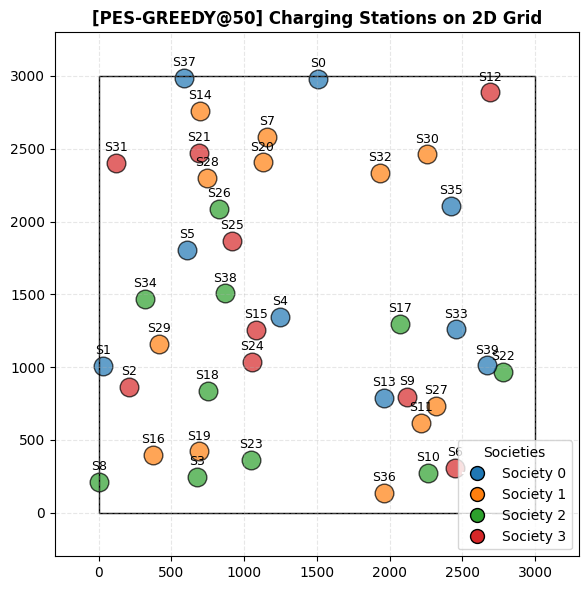

In [20]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=300)

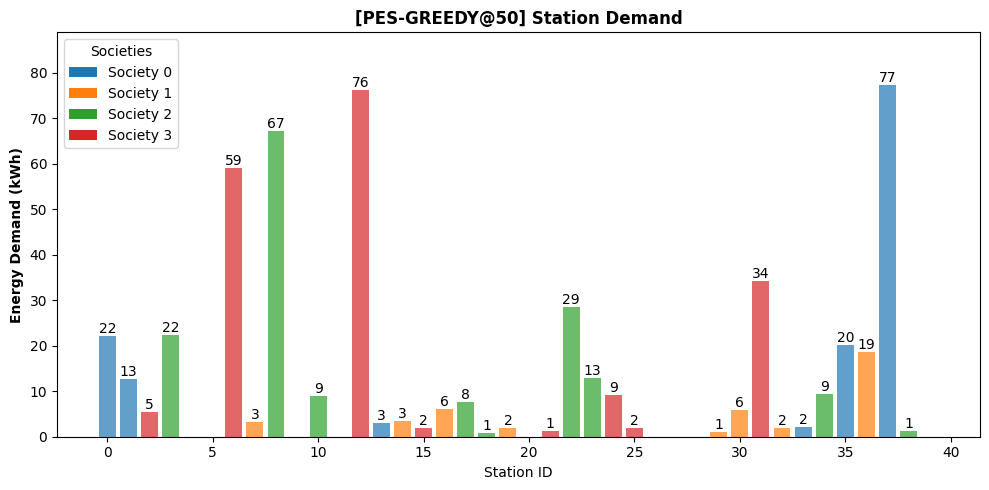

In [21]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

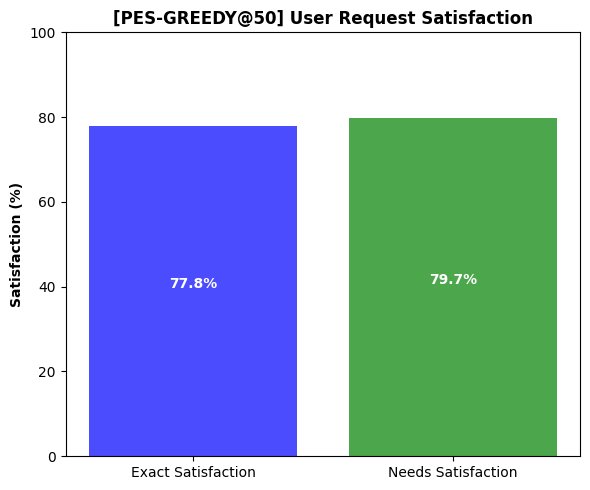

In [22]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

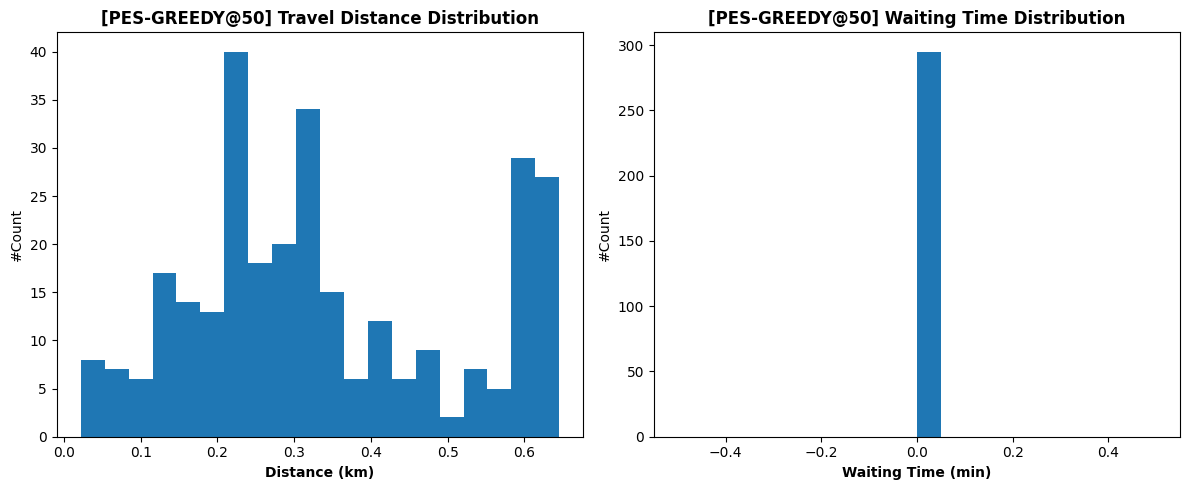

In [23]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

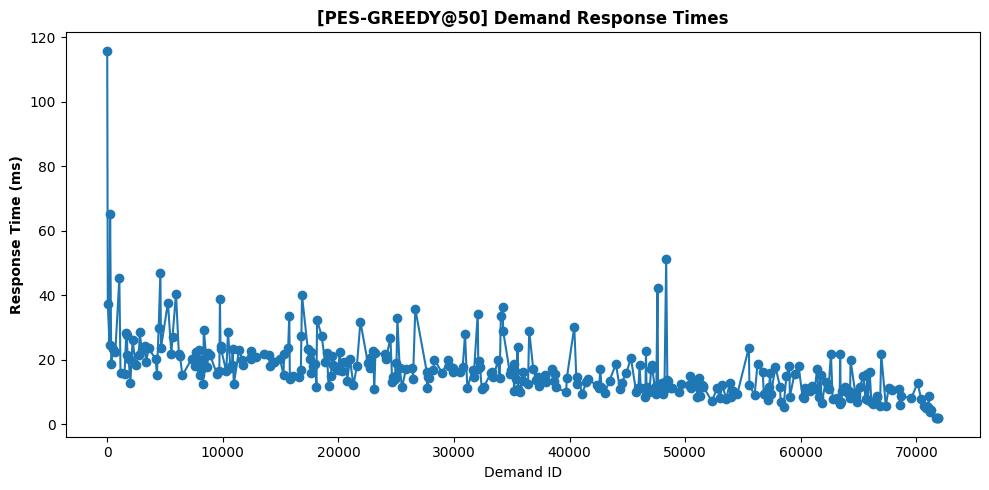

In [24]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

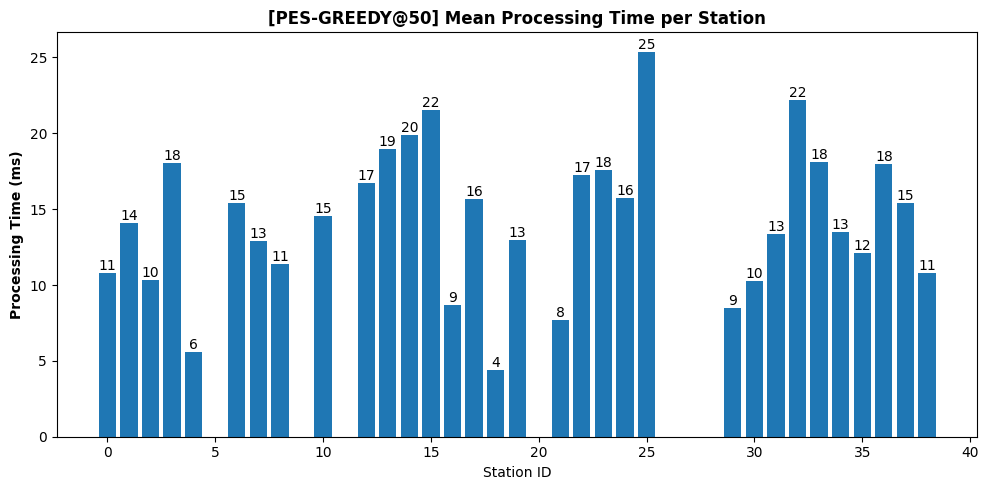

In [25]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [26]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           0  0.236806  0.040972  0.000000  0.091667       NaN   
1            0           1  0.160417  0.032639  0.000000  0.000000  0.000000   
2            0           4  0.000000  0.000000  0.000000  0.000000       NaN   
3            0           5  0.000000  0.000000  0.000000  0.000000       NaN   
4            0          13  0.049306  0.000000  0.000000  0.000000  0.000000   
5            0          33  0.028472  0.000000  0.000000  0.000000  0.000000   
6            0          35  0.223611  0.050000  0.020833  0.000000       NaN   
7            0          37  0.422222  0.309722  0.093750  0.020139  0.035417   
8            0          39  0.000000  0.000000  0.000000  0.000000       NaN   
9            1           7  0.042361  0.000000  0.000000  0.000000  0.000000   
10           1          11  0.000000  0.000000  0.000000  0.000000  0.000000   
11           1          14  0.059722  0.

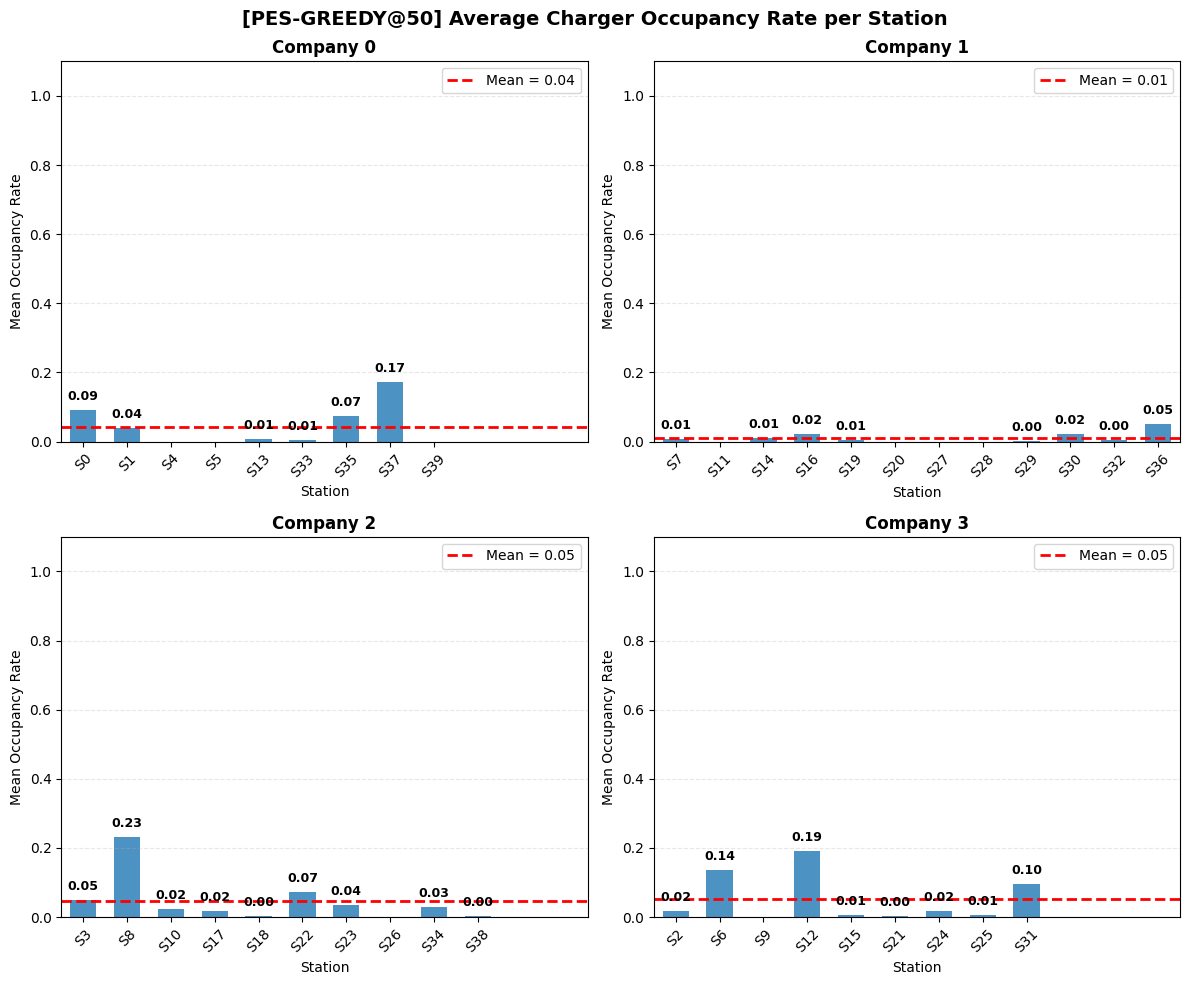

In [27]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

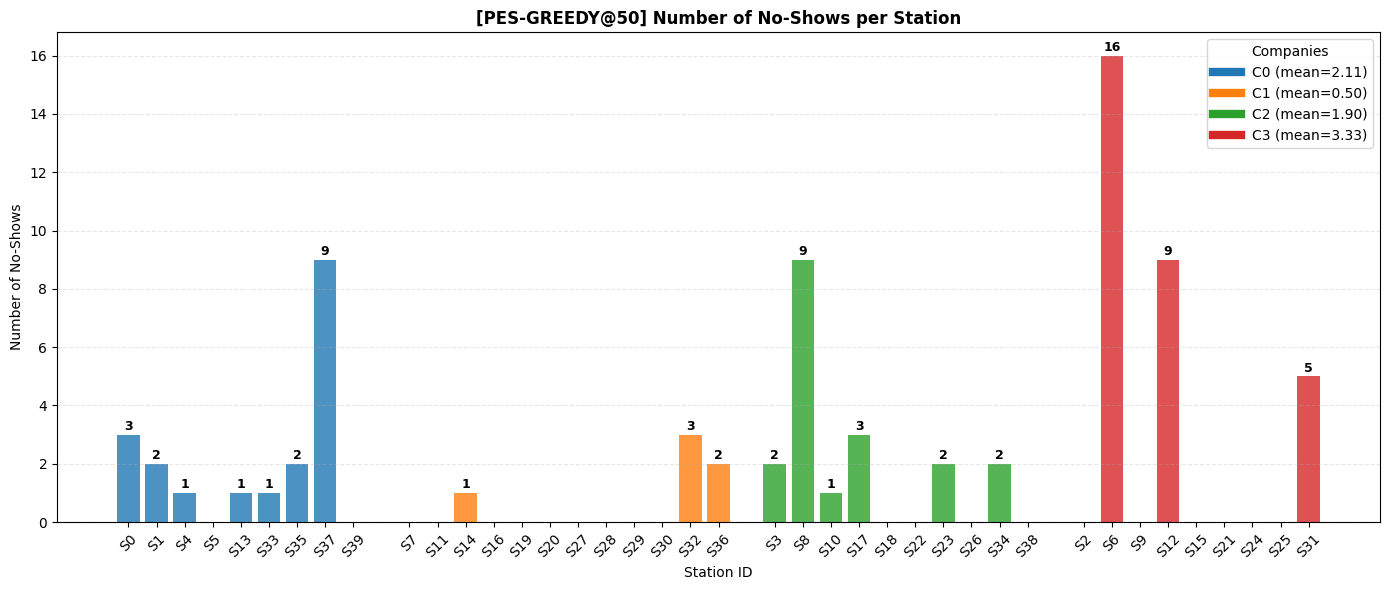

In [28]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [29]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,0,15,12,3,0,0,0.800000,0.200000,0.0,0.0
1,0,1,9,7,2,0,0,0.777778,0.222222,0.0,0.0
2,0,4,1,0,1,0,0,0.000000,1.000000,0.0,0.0
3,0,5,0,0,0,0,0,NaN,NaN,NaN,NaN
4,0,13,3,2,1,0,0,0.666667,0.333333,0.0,0.0
5,0,33,2,1,1,0,0,0.500000,0.500000,0.0,0.0
6,0,35,13,11,2,0,0,0.846154,0.153846,0.0,0.0
7,0,37,55,43,9,0,0,0.781818,0.163636,0.0,0.0
8,0,39,0,0,0,0,0,NaN,NaN,NaN,NaN
9,1,7,2,2,0,0,0,1.000000,0.000000,0.0,0.0


NUMBER OF REJECTED REQUESTS

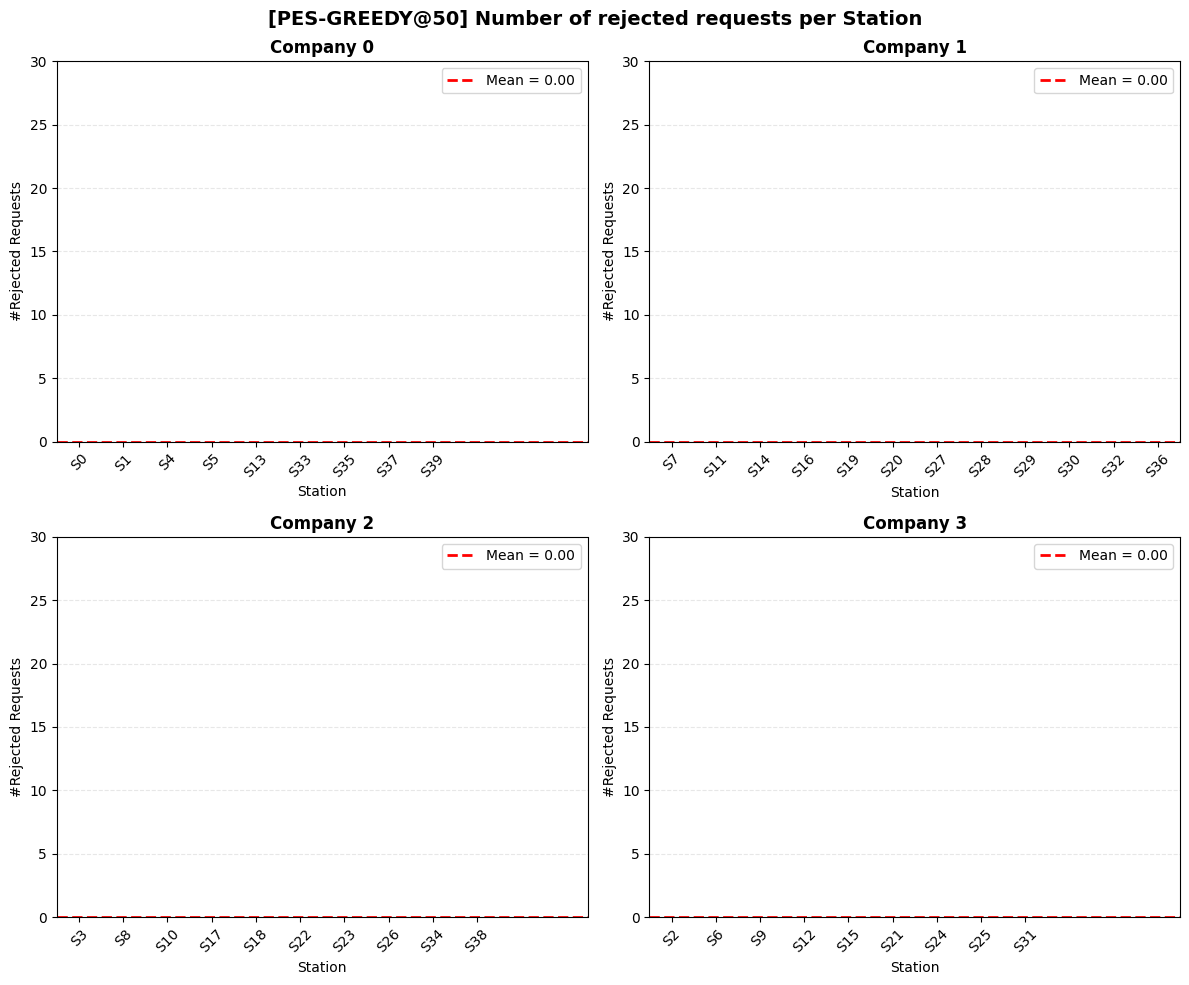

In [30]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [31]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [32]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [33]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-17 21:15:39.272 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-17 21:15:39.425 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-17 21:15:39.925 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-17 21:15:40.375 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-17 21:15:40.809 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-17 21:15:41.543 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-17 21:15:41.734 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-17 21:15:41.857 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-17 21:15:42.099 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-17 21:15:42.552 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-17 21:15:42.946 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [34]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 0.00 kWh
  Station 1: 21.26 kWh
  Station 2: 4.48 kWh
  Station 3: 0.00 kWh
  Station 4: 2.05 kWh
  Station 5: 18.89 kWh
  Station 6: 1.77 kWh
  Station 7: 40.23 kWh
  Station 8: 3.65 kWh
  Station 9: 79.02 kWh
  Station 10: 13.87 kWh
  Station 11: 39.03 kWh
  Station 12: 0.00 kWh
  Station 13: 18.50 kWh
  Station 14: 15.72 kWh
  Station 15: 2.90 kWh
  Station 16: 0.00 kWh
  Station 17: 0.95 kWh
  Station 18: 2.90 kWh
  Station 19: 4.06 kWh
  Station 20: 6.66 kWh
  Station 21: 1.69 kWh
  Station 22: 0.00 kWh
  Station 23: 9.88 kWh
  Station 24: 13.57 kWh
  Station 25: 1.87 kWh
  Station 26: 76.05 kWh
  Station 27: 38.39 kWh
  Station 28: 0.00 kWh
  Station 29: 6.45 kWh
  Station 30: 0.00 kWh
  Station 31: 4.87 kWh
  Station 32: 1.75 kWh
  Station 33: 1.50 kWh
  Station 34: 8.18 kWh
  Station 35: 3.11 kWh
  Station 36: 30.87 kWh
  Station 37: 0.00 kWh
  Station 38: 19.35 kWh
  Station 39: 64.08 kWh

--- User Req

In [35]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

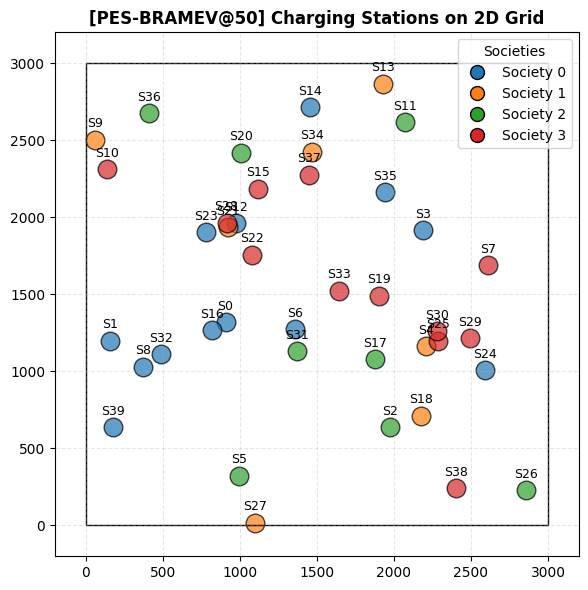

In [36]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

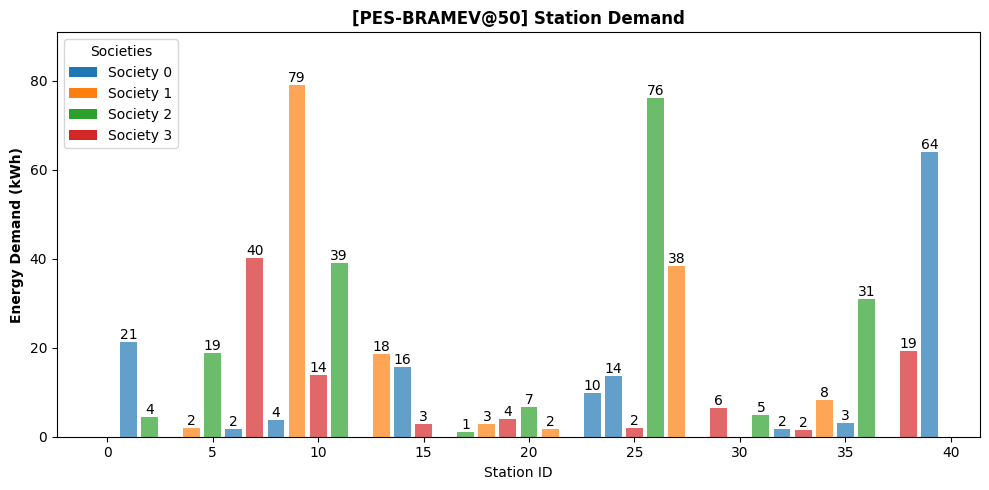

In [37]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

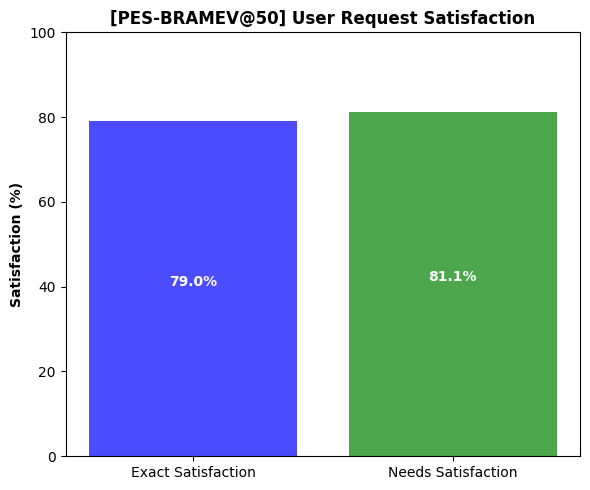

In [38]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

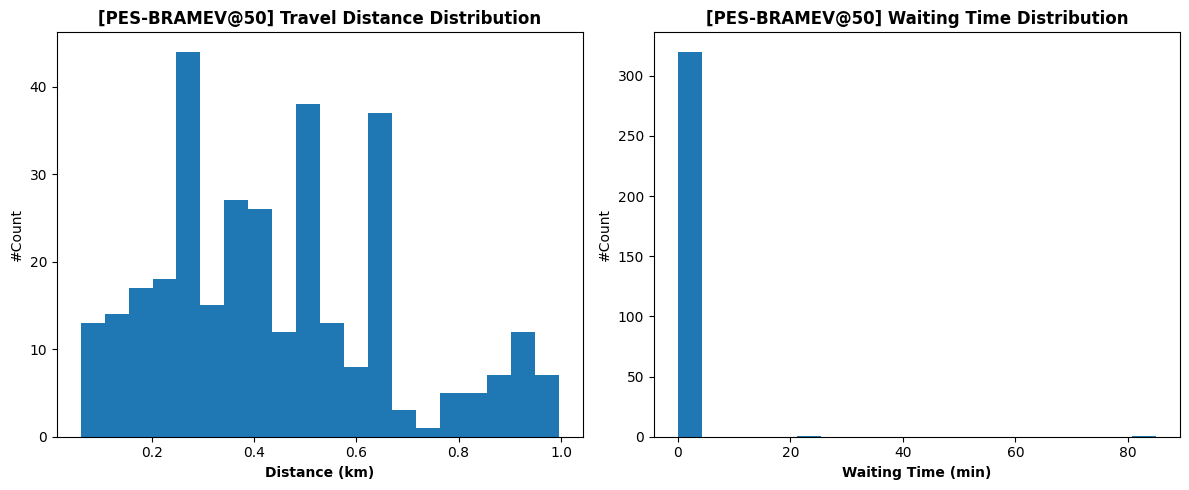

In [39]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

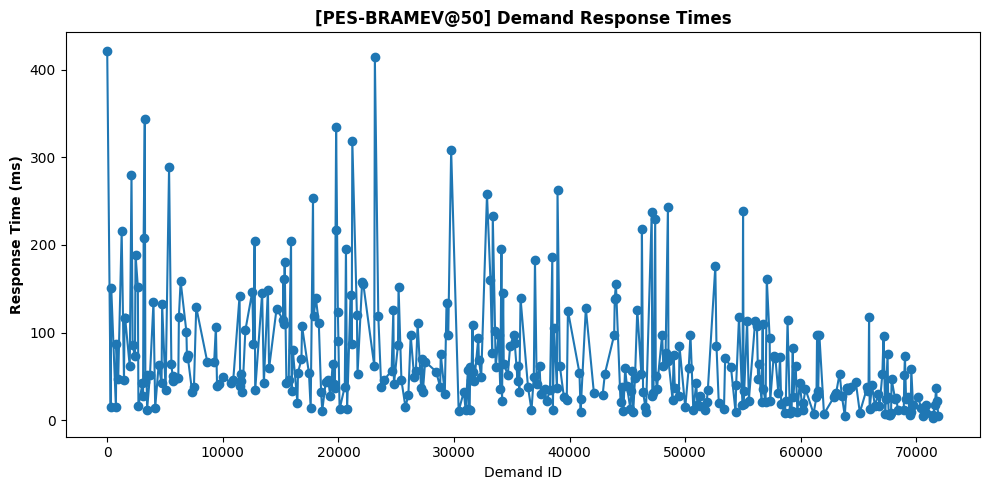

In [40]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

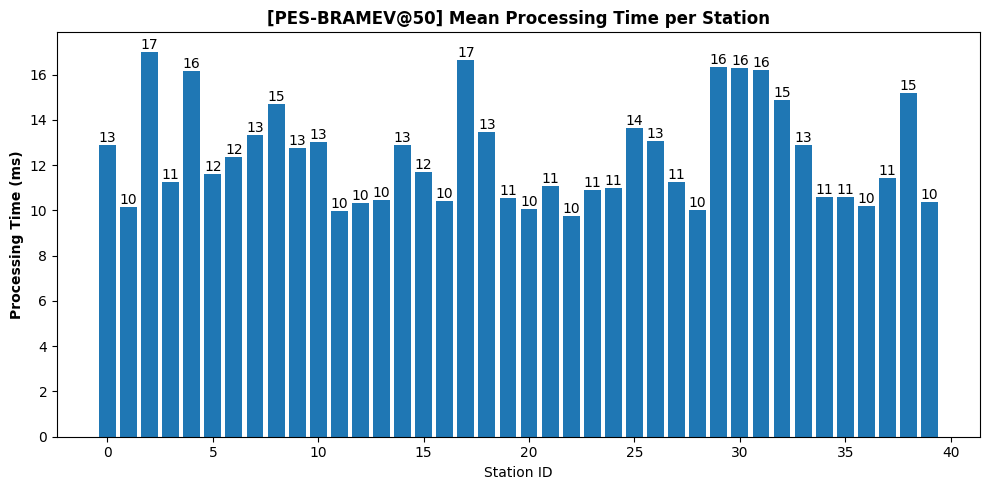

In [41]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

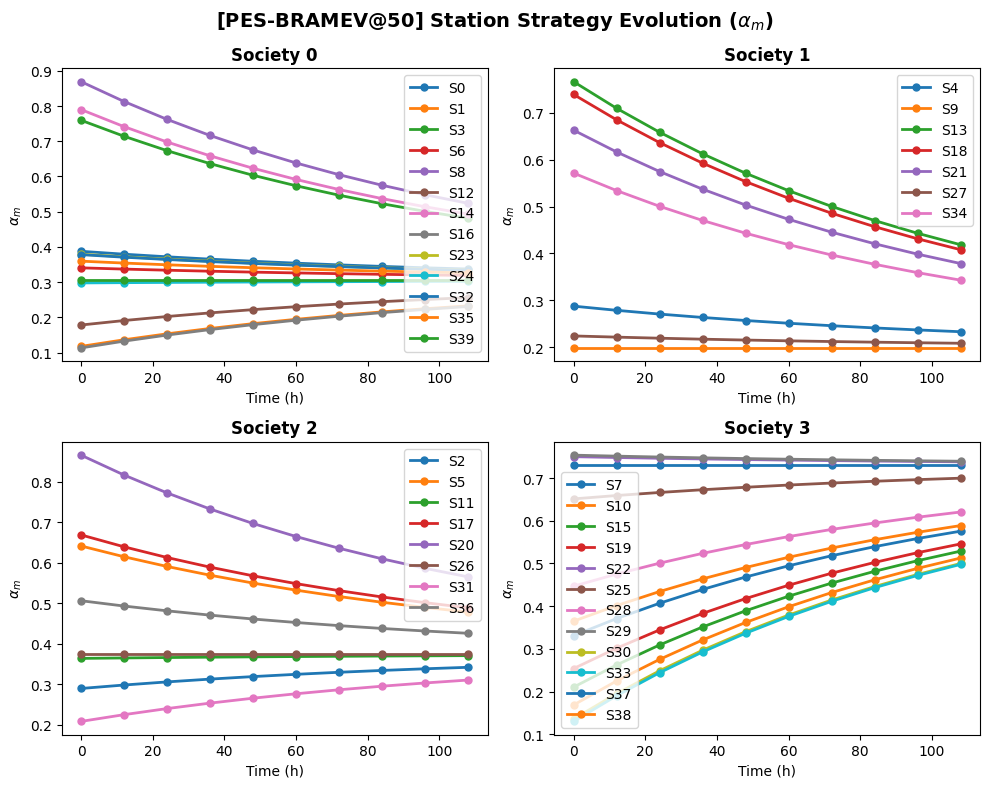

In [42]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [43]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           0  0.000000  0.000000  0.000000  0.000000  0.000000   
1            0           1  0.221528  0.081944  0.000000  0.000000       NaN   
2            0           3  0.000000  0.000000  0.000000  0.000000       NaN   
3            0           6  0.036806  0.000000  0.000000  0.000000  0.000000   
4            0           8  0.050694  0.000000  0.000000  0.000000  0.000000   
5            0          12  0.000000  0.000000  0.000000  0.000000       NaN   
6            0          14  0.195139  0.040278  0.000000  0.000000  0.000000   
7            0          16  0.000000  0.000000  0.000000  0.000000       NaN   
8            0          23  0.145139  0.000000  0.000000  0.000000       NaN   
9            0          24  0.186111  0.032639  0.014583  0.000000       NaN   
10           0          32  0.027778  0.000000  0.000000  0.000000  0.000000   
11           0          35  0.047222  0.

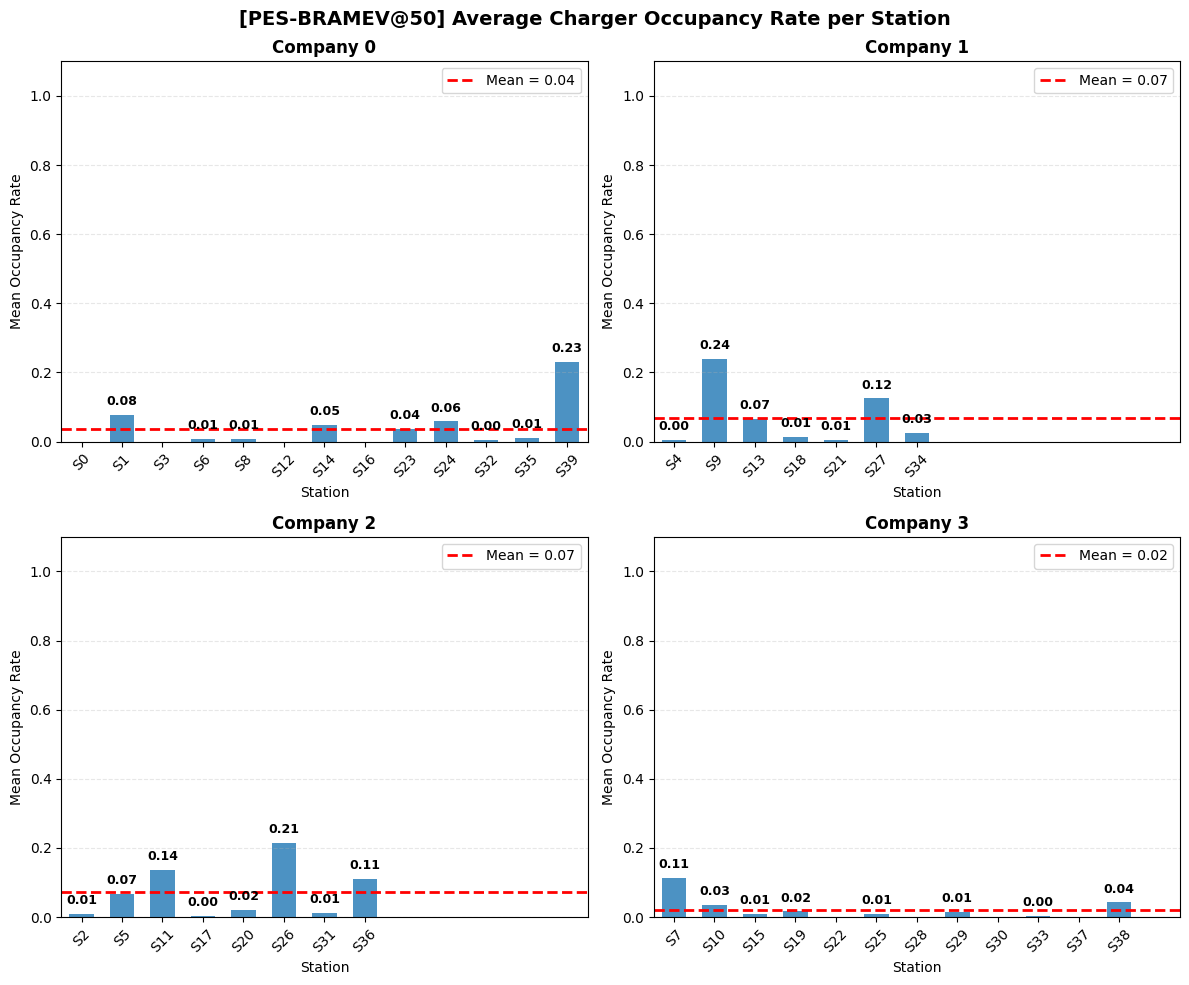

In [44]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

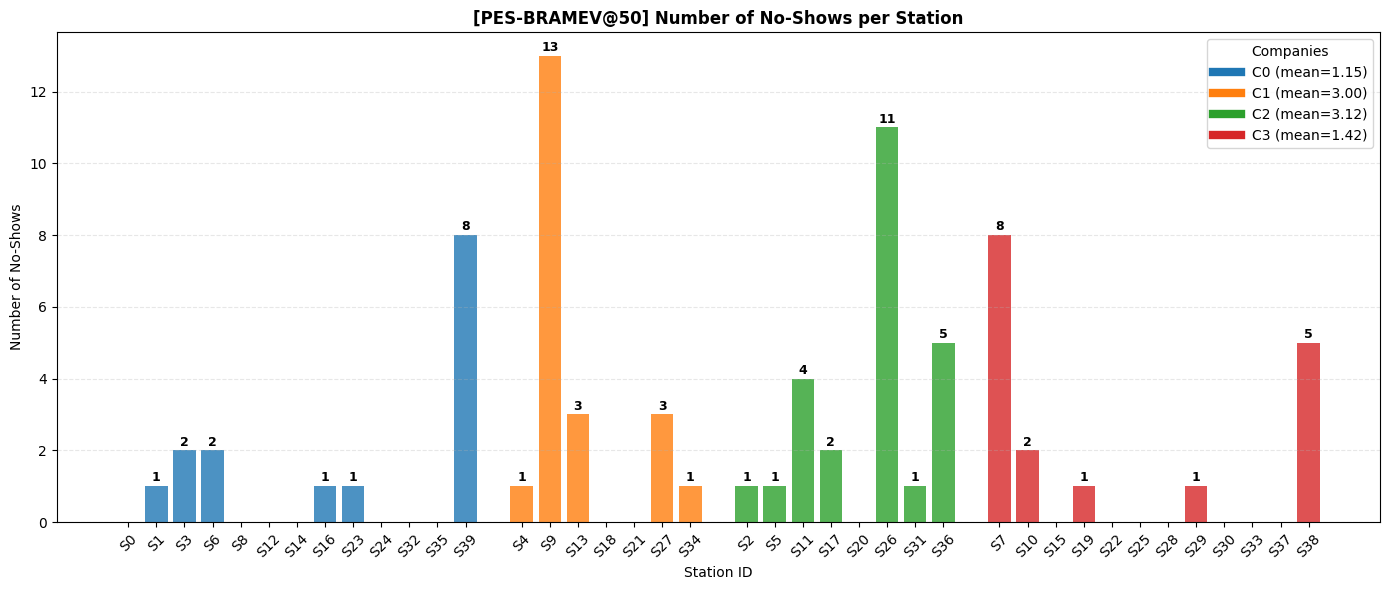

In [45]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [46]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN
1,0,1,13,12,1,0,0,0.923077,0.076923,0.0,0.0
2,0,3,2,0,2,0,0,0.000000,1.000000,0.0,0.0
3,0,6,3,1,2,0,0,0.333333,0.666667,0.0,0.0
4,0,8,2,2,0,0,0,1.000000,0.000000,0.0,0.0
5,0,12,0,0,0,0,0,NaN,NaN,NaN,NaN
6,0,14,10,10,0,0,0,1.000000,0.000000,0.0,0.0
7,0,16,1,0,1,0,0,0.000000,1.000000,0.0,0.0
8,0,23,6,5,1,0,0,0.833333,0.166667,0.0,0.0
9,0,24,8,8,0,0,0,1.000000,0.000000,0.0,0.0


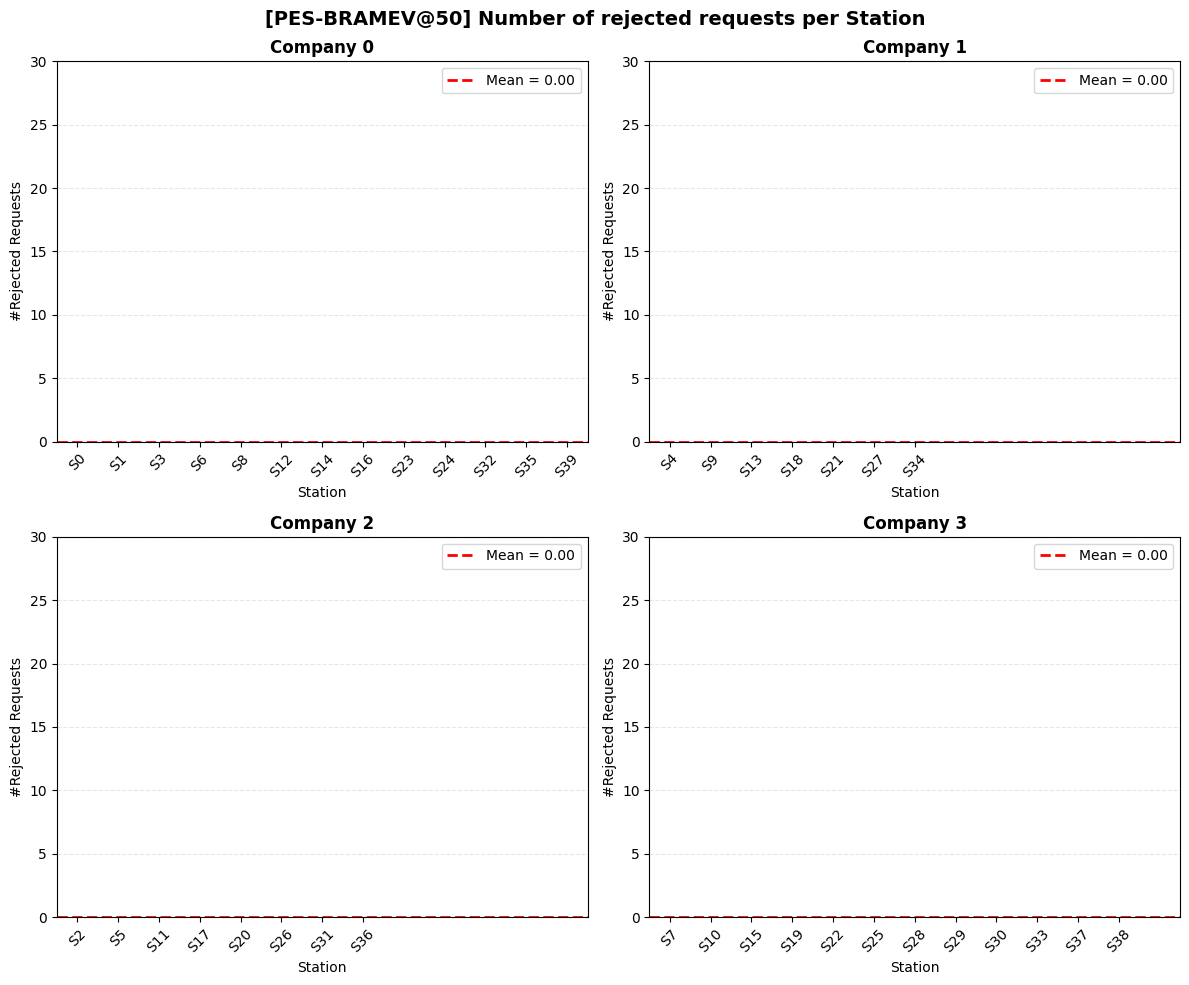

In [47]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [48]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

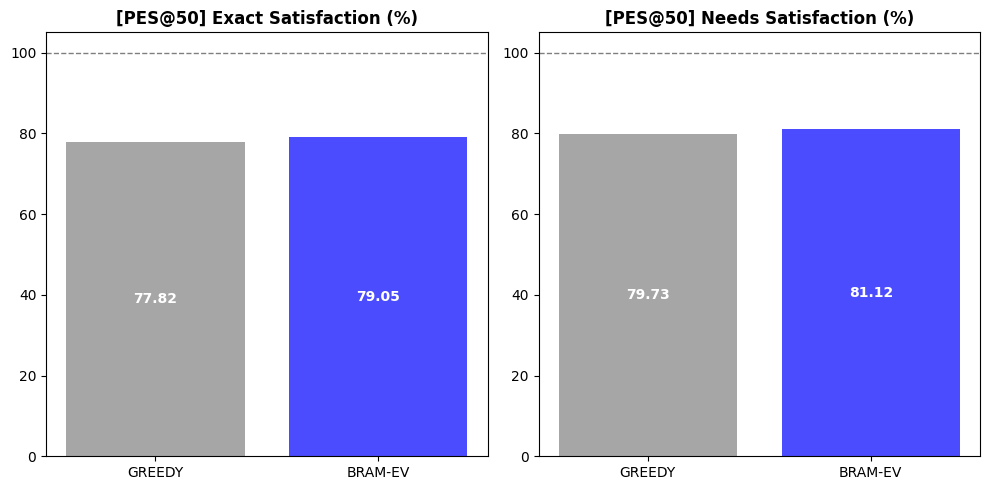

In [49]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

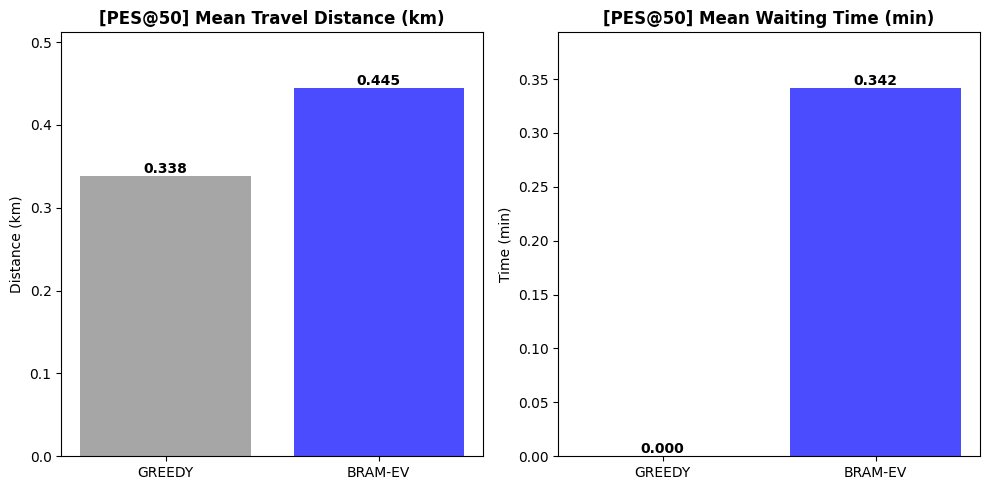

In [50]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

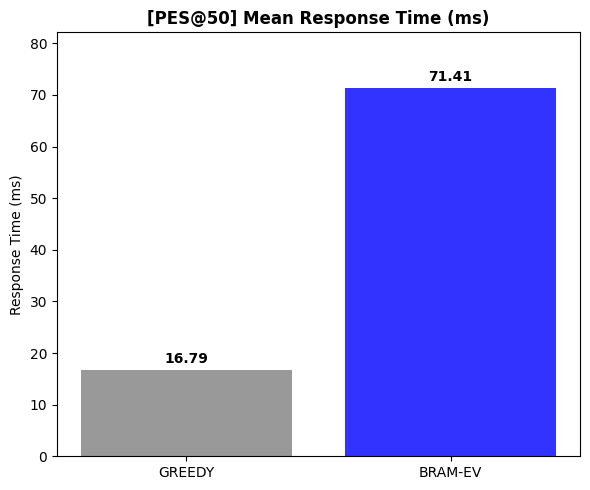

In [51]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@100cars**

#### **CONFIG**

In [52]:
nb_car = 100
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [53]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [54]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [55]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-17 21:16:07.392 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-06-17 21:16:07.484 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-06-17 21:16:07.638 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-06-17 21:16:07.897 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-06-17 21:16:08.049 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-06-17 21:16:08.130 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-06-17 21:16:08.310 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-06-17 21:16:08.520 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-06-17 21:16:08.631 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-06-17 21:16:08.779 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-06-17 21:16:08.963 | IN

##### *Metrics*

In [56]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 8.23 kWh
  Station 1: 46.86 kWh
  Station 2: 5.00 kWh
  Station 3: 45.92 kWh
  Station 4: 3.42 kWh
  Station 5: 1.95 kWh
  Station 6: 0.00 kWh
  Station 7: 2.40 kWh
  Station 8: 5.82 kWh
  Station 9: 15.72 kWh
  Station 10: 1.62 kWh
  Station 11: 5.42 kWh
  Station 12: 8.18 kWh
  Station 13: 141.37 kWh
  Station 14: 4.12 kWh
  Station 15: 10.45 kWh
  Station 16: 24.87 kWh
  Station 17: 1.65 kWh
  Station 18: 12.15 kWh
  Station 19: 51.67 kWh
  Station 20: 71.00 kWh
  Station 21: 0.00 kWh
  Station 22: 1.77 kWh
  Station 23: 20.14 kWh
  Station 24: 168.07 kWh
  Station 25: 0.00 kWh
  Station 26: 10.32 kWh
  Station 27: 3.71 kWh
  Station 28: 7.78 kWh
  Station 29: 8.63 kWh
  Station 30: 2.12 kWh
  Station 31: 120.48 kWh
  Station 32: 6.88 kWh
  Station 33: 3.51 kWh
  Station 34: 0.00 kWh
  Station 35: 18.69 kWh
  Station 36: 157.53 kWh
  Station 37: 21.31 kWh
  Station 38: 1.20 kWh
  Station 39: 62.33 kWh

--- U

In [57]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

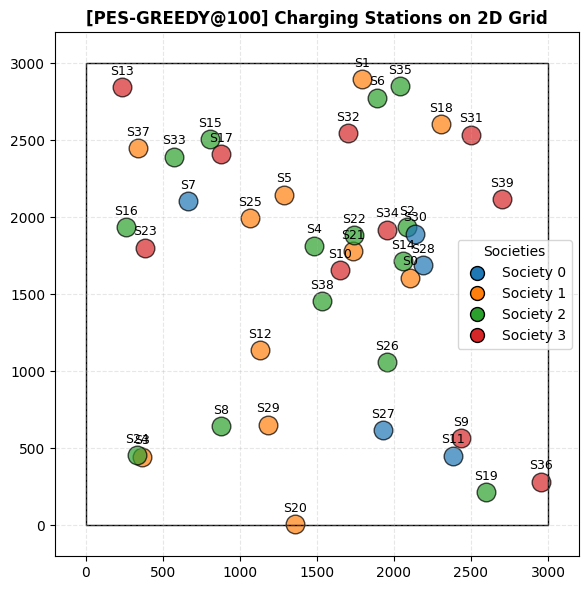

In [58]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

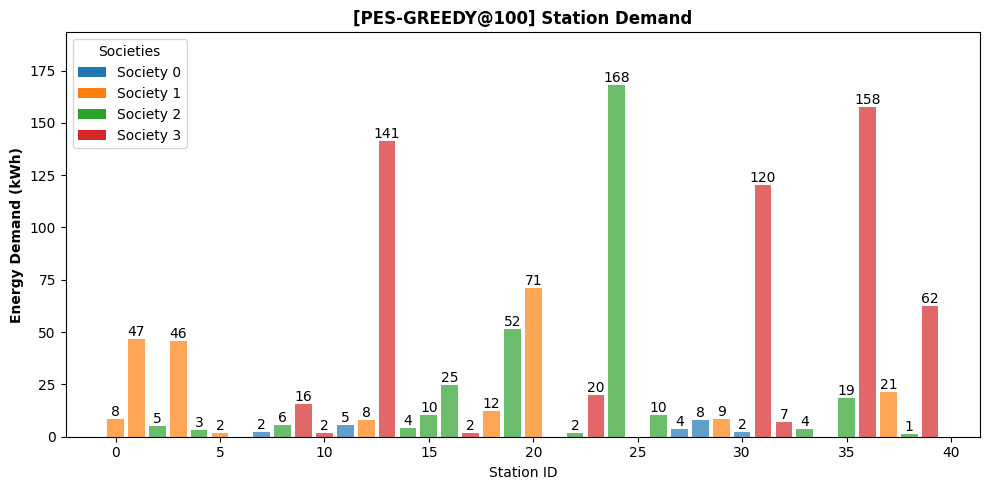

In [59]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

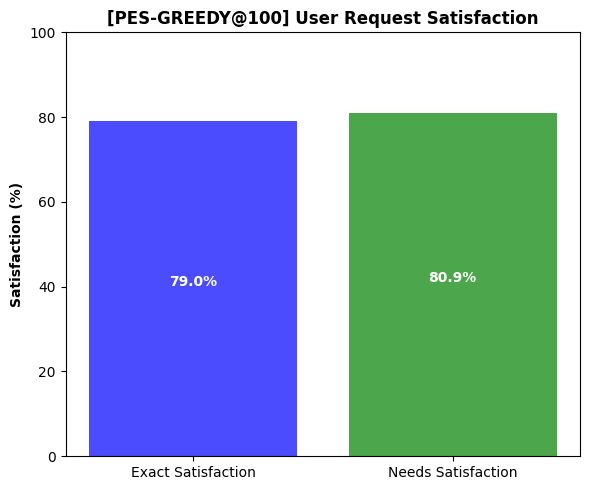

In [60]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

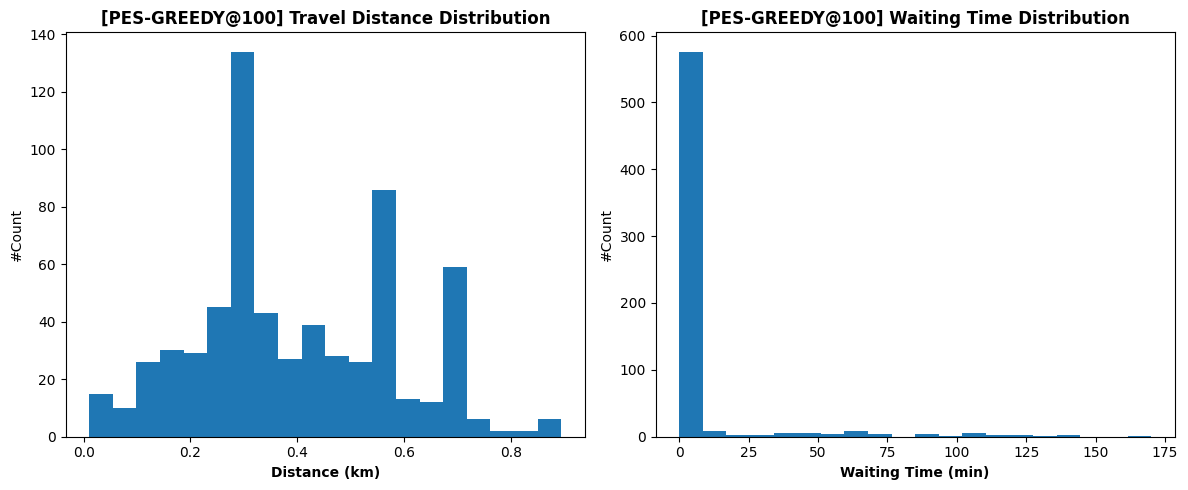

In [61]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

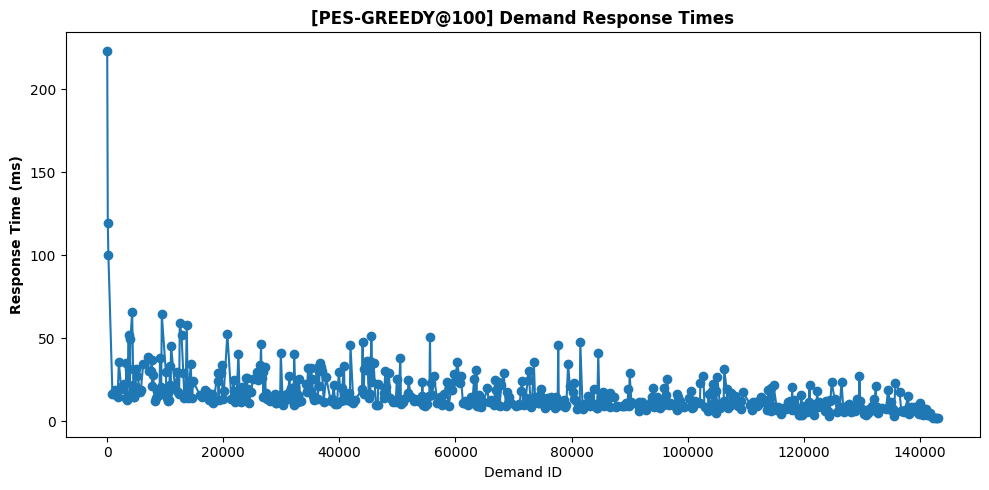

In [62]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

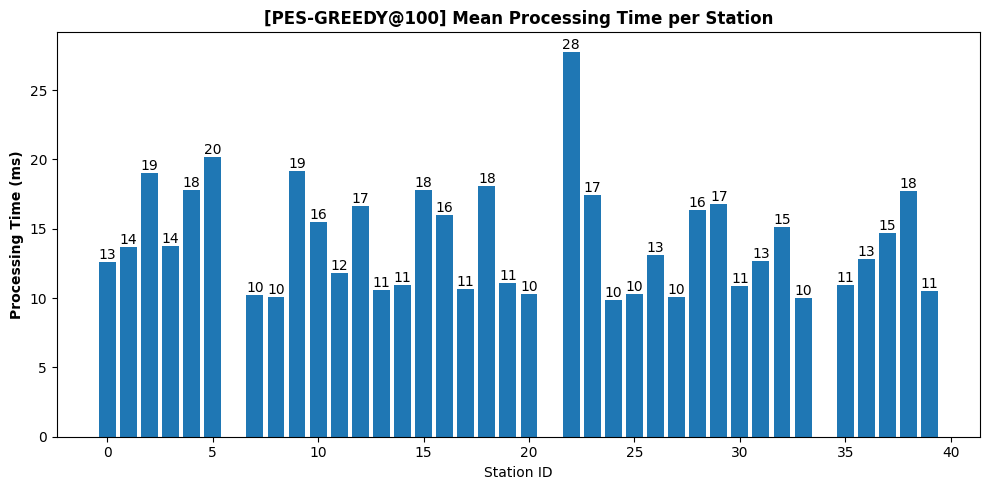

In [63]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [64]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           7  0.025000  0.000000  0.000000  0.000000       NaN   
1            0          11  0.061111  0.021528  0.000000  0.000000  0.000000   
2            0          27  0.051389  0.000000  0.000000  0.000000  0.000000   
3            0          28  0.140972  0.000000  0.000000  0.000000  0.000000   
4            0          30  0.035417  0.000000  0.000000  0.000000       NaN   
5            1           0  0.089583  0.024306  0.000000  0.000000  0.000000   
6            1           1  0.348611  0.204861  0.000000  0.082639  0.061111   
7            1           3  0.465972  0.175694  0.070833  0.000000  0.000000   
8            1           5  0.027083  0.000000  0.000000  0.000000  0.000000   
9            1          12  0.091667  0.025694  0.000000  0.000000  0.000000   
10           1          18  0.176389  0.000000  0.000000  0.000000  0.000000   
11           1          20  0.484028  0.

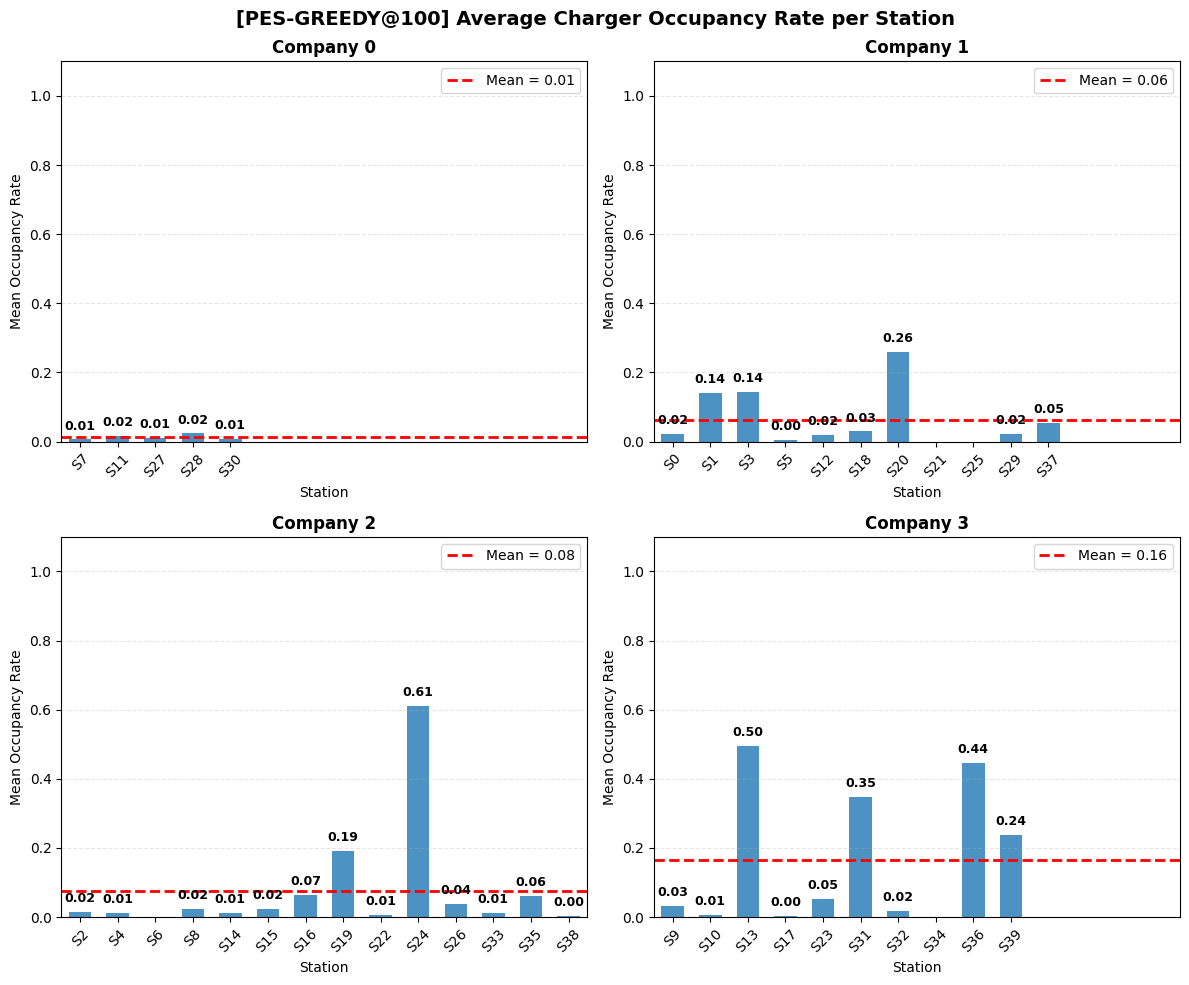

In [65]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

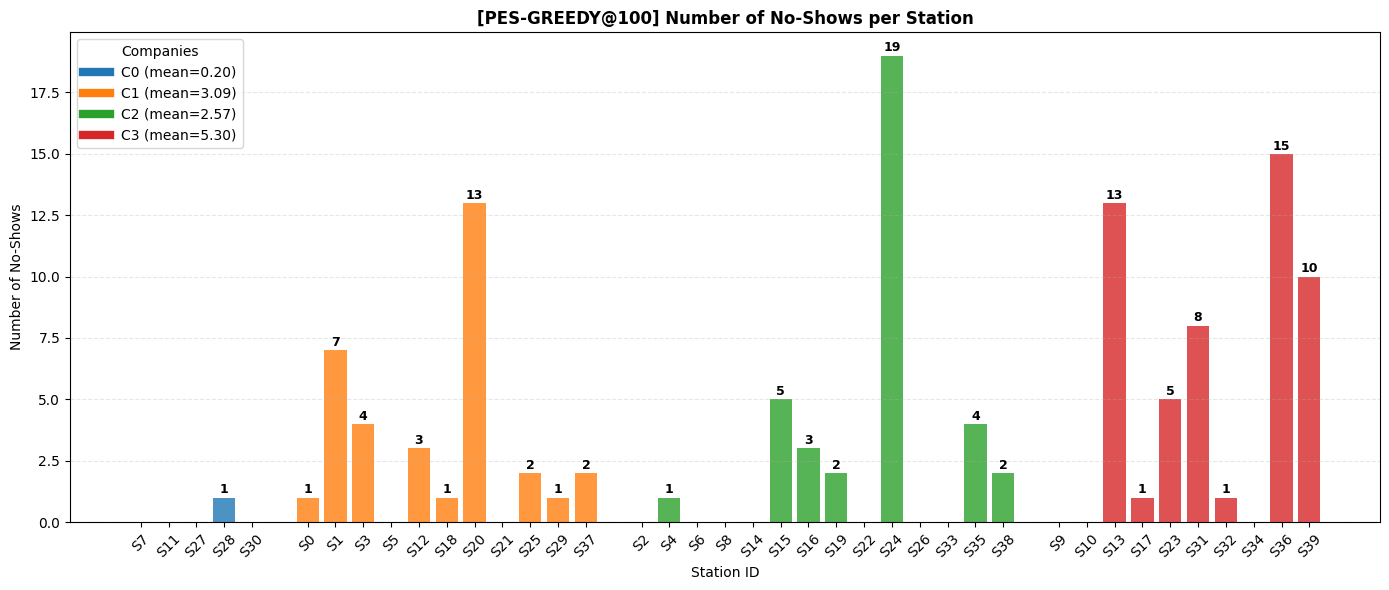

In [66]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [67]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,7,1,1,0,0,0,1.000000,0.000000,0.000000,0.000
1,0,11,4,4,0,0,0,1.000000,0.000000,0.000000,0.000
2,0,27,2,2,0,0,0,1.000000,0.000000,0.000000,0.000
3,0,28,6,5,1,0,0,0.833333,0.166667,0.000000,0.000
4,0,30,1,1,0,0,0,1.000000,0.000000,0.000000,0.000
5,1,0,6,5,1,0,0,0.833333,0.166667,0.000000,0.000
6,1,1,34,26,7,0,0,0.764706,0.205882,0.000000,0.000
7,1,3,31,26,4,0,0,0.838710,0.129032,0.000000,0.000
8,1,5,1,1,0,0,0,1.000000,0.000000,0.000000,0.000
9,1,12,8,5,3,0,0,0.625000,0.375000,0.000000,0.000


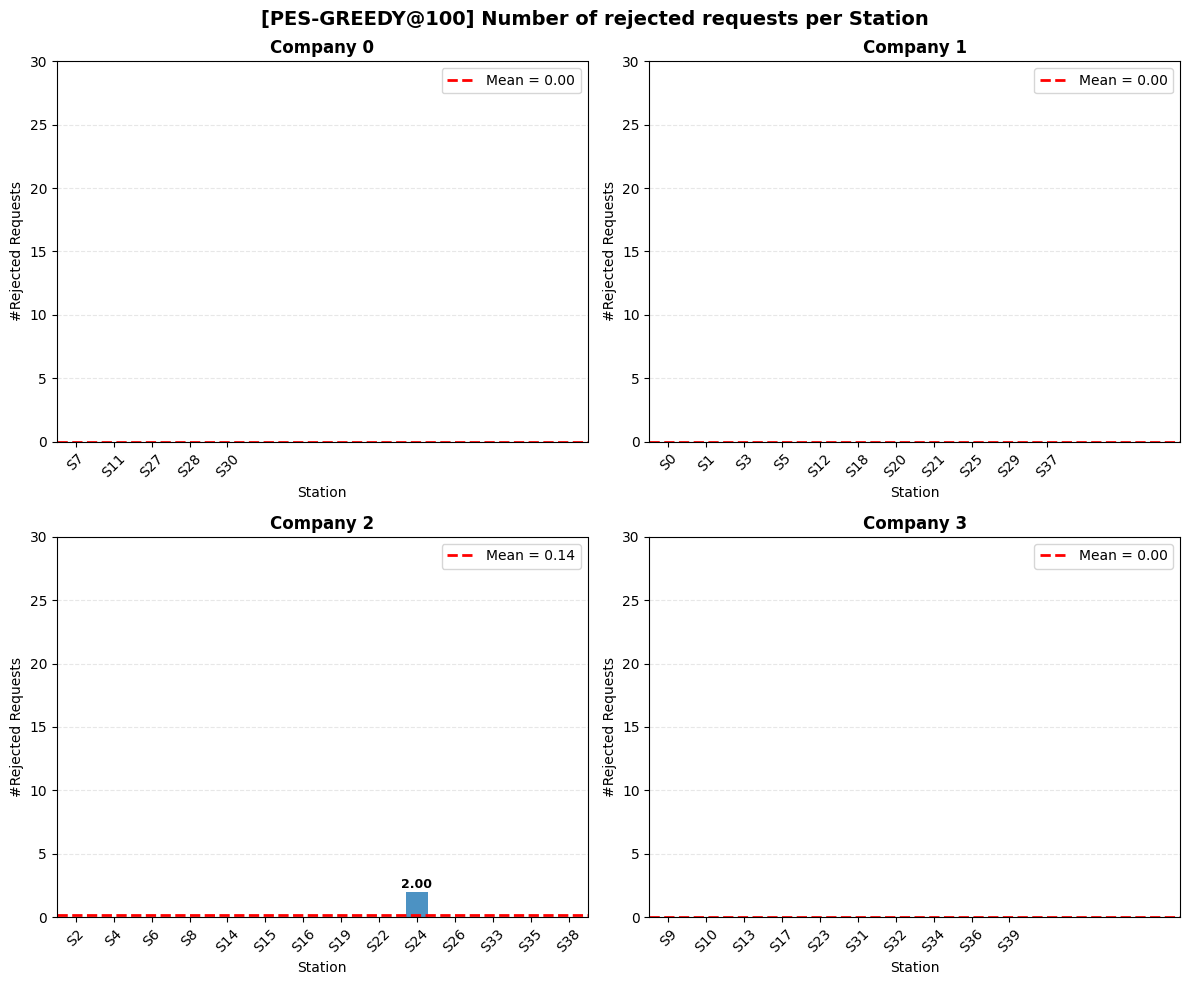

In [68]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [69]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [70]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [71]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-17 21:16:20.540 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-17 21:16:21.413 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-17 21:16:22.772 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-17 21:16:23.078 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-17 21:16:23.671 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-17 21:16:24.708 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-17 21:16:26.396 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-17 21:16:27.167 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-17 21:16:28.645 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-17 21:16:29.213 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-17 21:16:29.878 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [72]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 10.81 kWh
  Station 1: 3.73 kWh
  Station 2: 0.00 kWh
  Station 3: 54.88 kWh
  Station 4: 3.64 kWh
  Station 5: 37.57 kWh
  Station 6: 2.47 kWh
  Station 7: 44.56 kWh
  Station 8: 19.85 kWh
  Station 9: 10.34 kWh
  Station 10: 33.23 kWh
  Station 11: 13.88 kWh
  Station 12: 58.03 kWh
  Station 13: 5.68 kWh
  Station 14: 4.73 kWh
  Station 15: 1.40 kWh
  Station 16: 10.87 kWh
  Station 17: 13.82 kWh
  Station 18: 21.91 kWh
  Station 19: 41.01 kWh
  Station 20: 116.22 kWh
  Station 21: 14.37 kWh
  Station 22: 8.93 kWh
  Station 23: 2.81 kWh
  Station 24: 5.05 kWh
  Station 25: 152.65 kWh
  Station 26: 28.83 kWh
  Station 27: 9.05 kWh
  Station 28: 115.66 kWh
  Station 29: 40.46 kWh
  Station 30: 2.17 kWh
  Station 31: 117.28 kWh
  Station 32: 4.88 kWh
  Station 33: 3.16 kWh
  Station 34: 9.02 kWh
  Station 35: 6.40 kWh
  Station 36: 7.29 kWh
  Station 37: 0.75 kWh
  Station 38: 0.00 kWh
  Station 39: 75.62 kWh

-

In [73]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

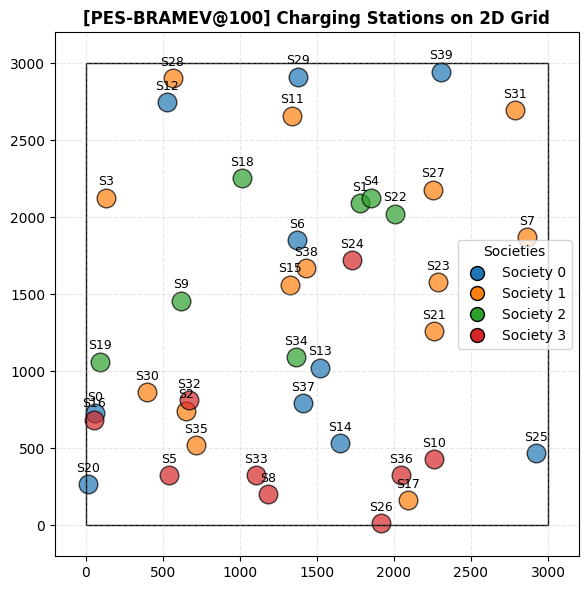

In [74]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

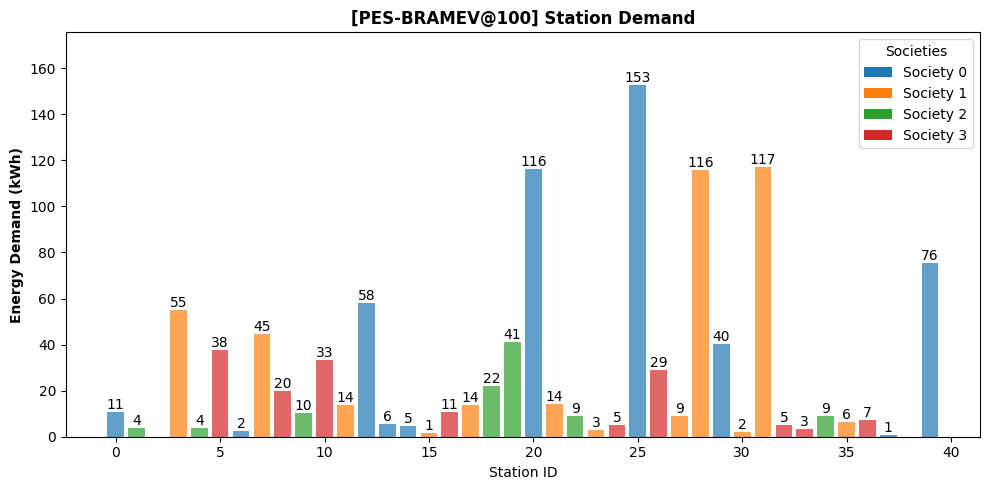

In [75]:
plot_station_demand(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, societies=societies, figsize=(10, 5))

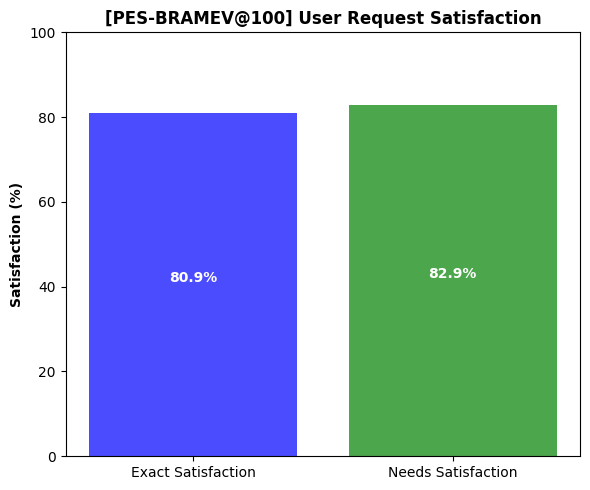

In [76]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

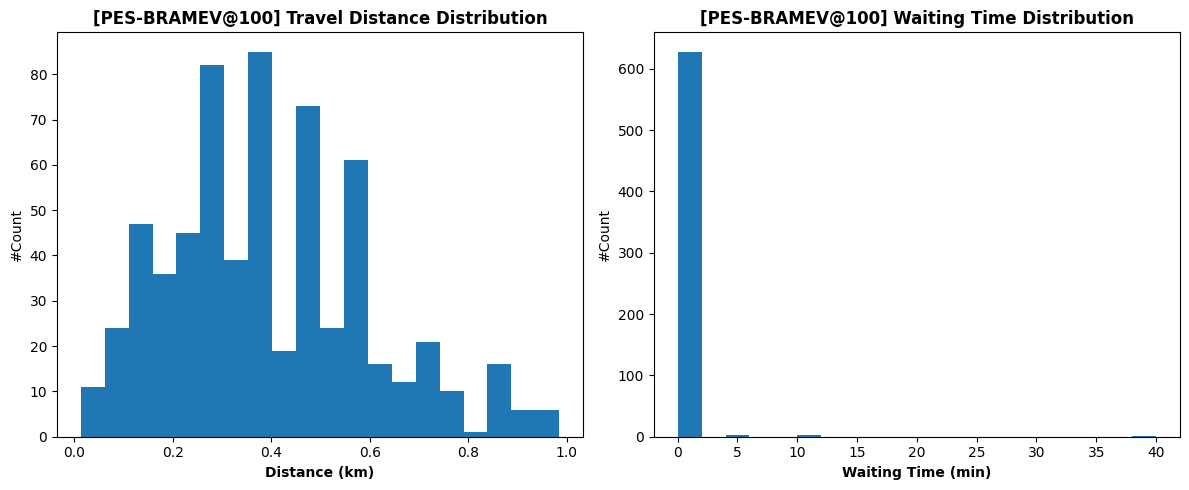

In [77]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

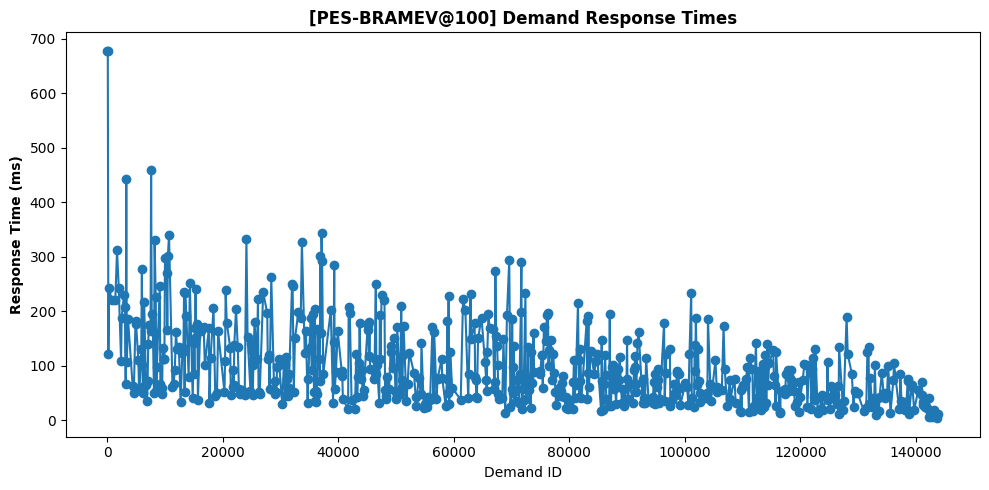

In [78]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

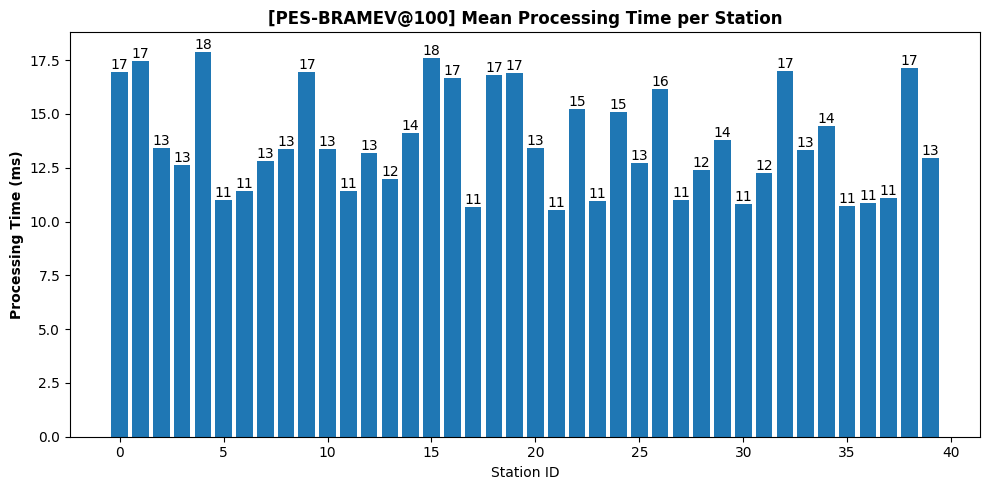

In [79]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

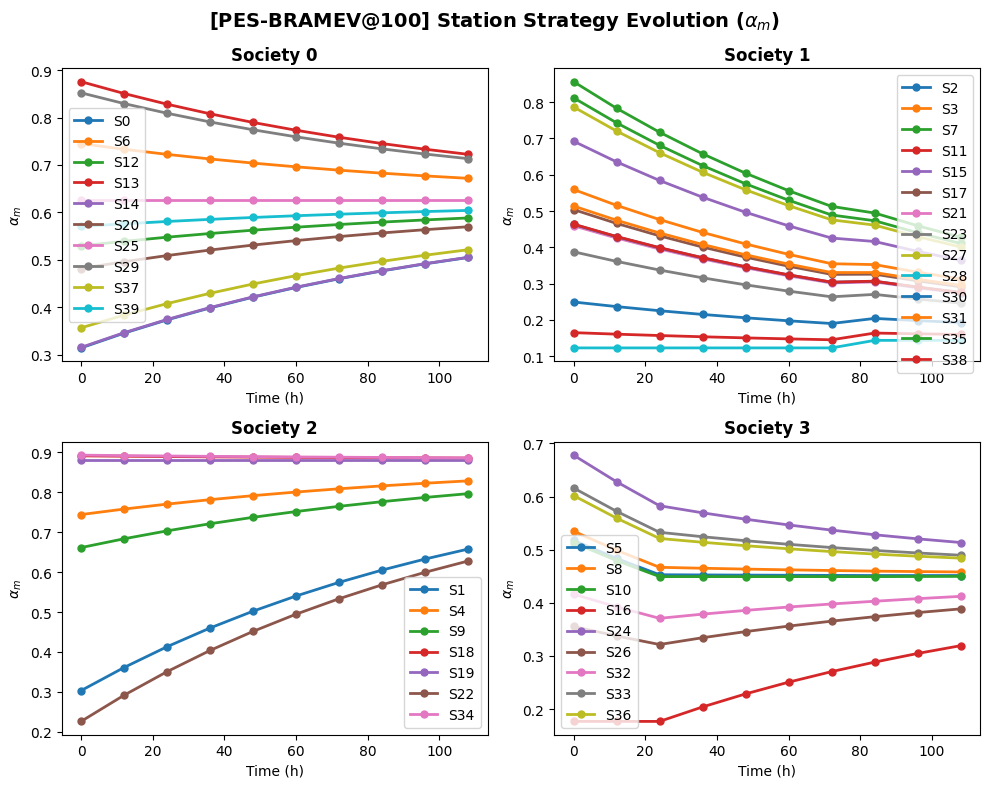

In [80]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [81]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           0  0.104861  0.044444  0.000000  0.000000  0.000000   
1            0           6  0.051389  0.000000  0.000000  0.000000       NaN   
2            0          12  0.350000  0.243750  0.049306  0.025694  0.077083   
3            0          13  0.096528  0.000000  0.000000  0.000000       NaN   
4            0          14  0.051389  0.000000  0.000000  0.000000  0.000000   
5            0          20  0.683333  0.446528  0.154861  0.113889  0.175694   
6            0          25  0.522917  0.600694  0.366667  0.163889  0.372917   
7            0          29  0.306250  0.146528  0.054861  0.000000  0.025694   
8            0          37  0.012500  0.000000  0.000000  0.000000       NaN   
9            0          39  0.463889  0.338889  0.156944  0.051389  0.099306   
10           1           2  0.000000  0.000000  0.000000  0.000000  0.000000   
11           1           3  0.449306  0.

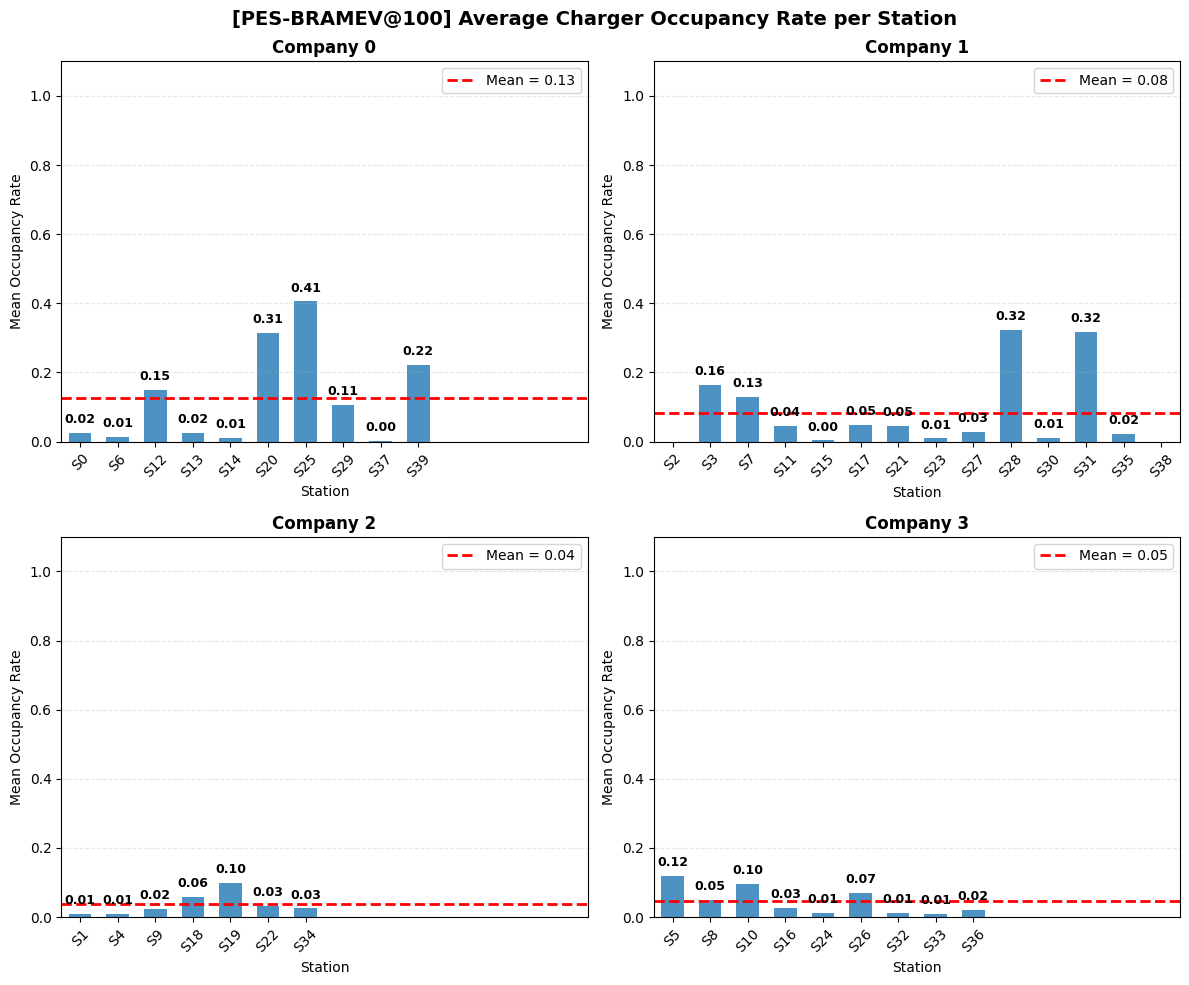

In [82]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

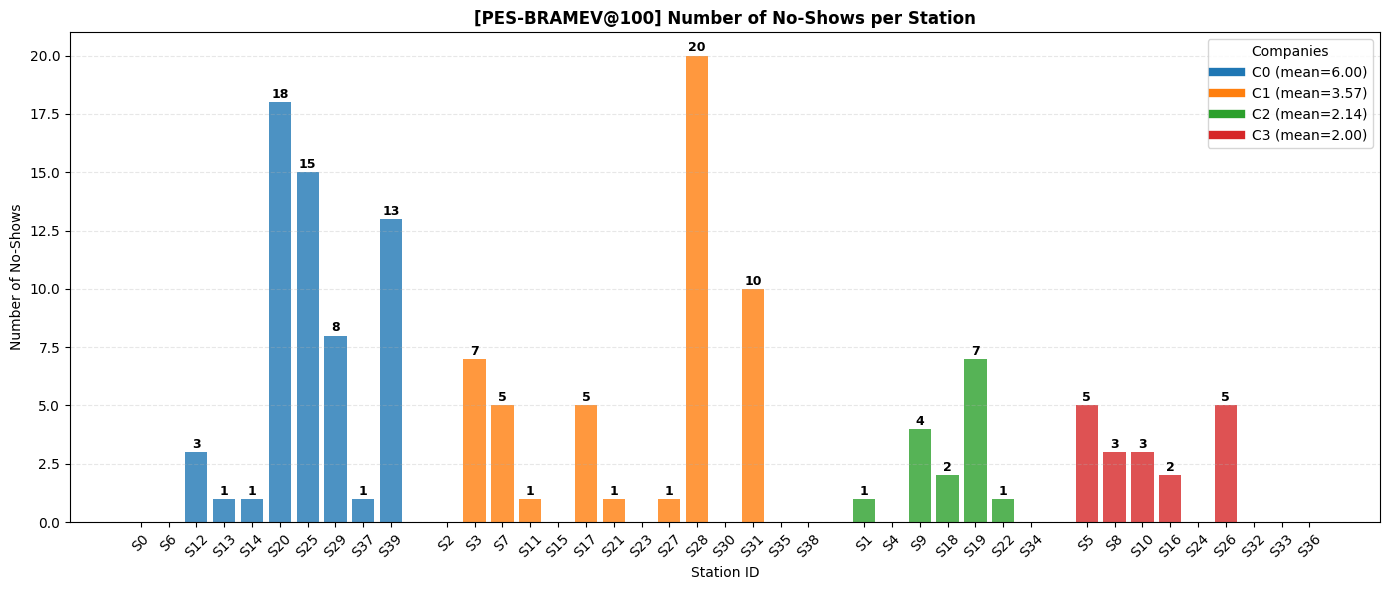

In [83]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [84]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,0,6,6,0,0,0,1.000000,0.000000,0.0,0.0
1,0,6,1,1,0,0,0,1.000000,0.000000,0.0,0.0
2,0,12,36,33,3,0,0,0.916667,0.083333,0.0,0.0
3,0,13,4,3,1,0,0,0.750000,0.250000,0.0,0.0
4,0,14,4,3,1,0,0,0.750000,0.250000,0.0,0.0
5,0,20,87,66,18,0,0,0.758621,0.206897,0.0,0.0
6,0,25,103,87,15,0,0,0.844660,0.145631,0.0,0.0
7,0,29,32,23,8,0,0,0.718750,0.250000,0.0,0.0
8,0,37,2,1,1,0,0,0.500000,0.500000,0.0,0.0
9,0,39,55,41,13,0,0,0.745455,0.236364,0.0,0.0


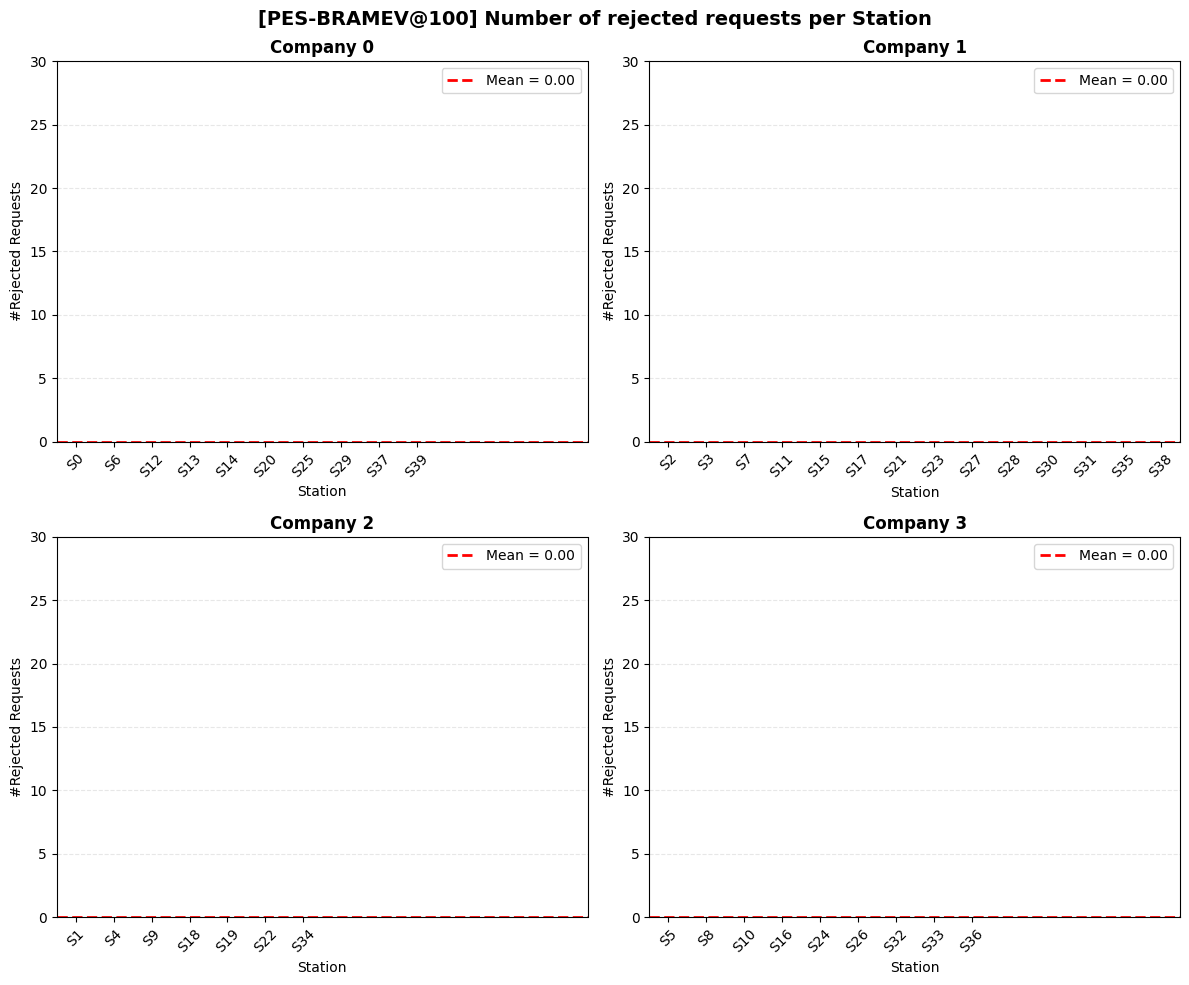

In [85]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [86]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

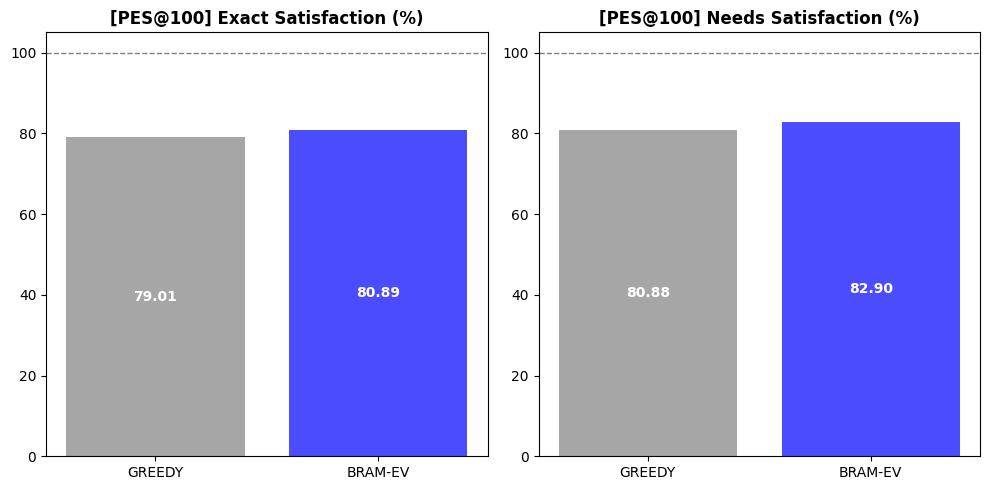

In [87]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

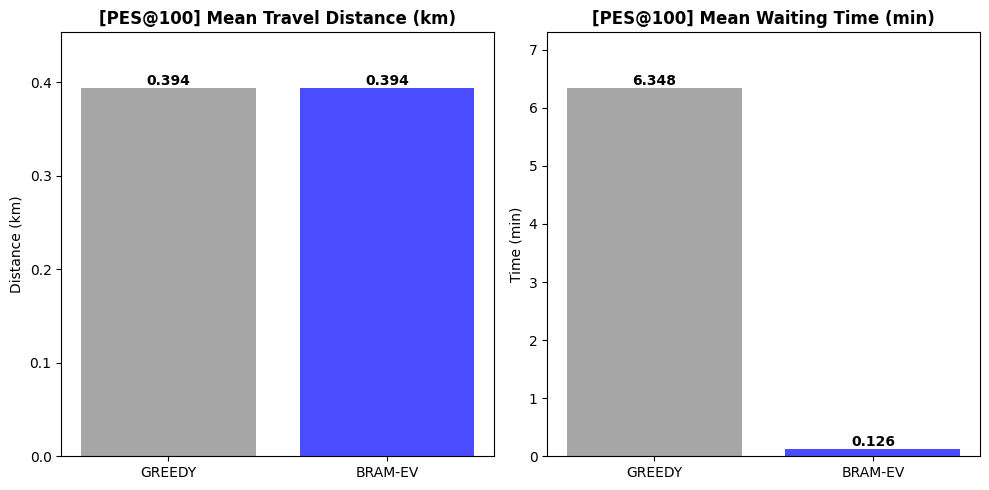

In [88]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

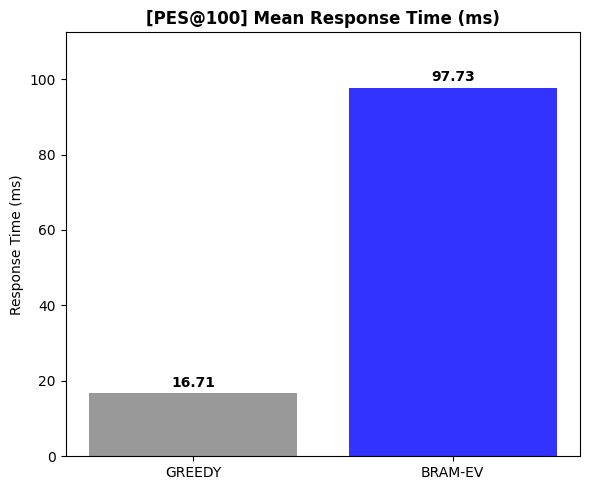

In [89]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@150cars**

#### **CONFIG**

In [90]:
nb_car = 150
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [91]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/pessimistic/greedy/150cars


##### *Initialisation*

In [92]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [93]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-17 21:17:23.237 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-06-17 21:17:23.556 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-06-17 21:17:23.763 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-06-17 21:17:24.044 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-06-17 21:17:24.173 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-06-17 21:17:24.385 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-06-17 21:17:24.518 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-06-17 21:17:24.762 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-06-17 21:17:24.997 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-06-17 21:17:25.276 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-06-17 21:17:25.566 | IN

##### *Metrics*

In [94]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 11.58 kWh
  Station 1: 43.45 kWh
  Station 2: 230.07 kWh
  Station 3: 38.46 kWh
  Station 4: 64.19 kWh
  Station 5: 11.50 kWh
  Station 6: 19.18 kWh
  Station 7: 6.88 kWh
  Station 8: 3.47 kWh
  Station 9: 5.52 kWh
  Station 10: 9.32 kWh
  Station 11: 7.85 kWh
  Station 12: 2.51 kWh
  Station 13: 58.57 kWh
  Station 14: 23.38 kWh
  Station 15: 84.74 kWh
  Station 16: 2.13 kWh
  Station 17: 177.41 kWh
  Station 18: 2.52 kWh
  Station 19: 18.96 kWh
  Station 20: 0.00 kWh
  Station 21: 49.09 kWh
  Station 22: 28.19 kWh
  Station 23: 4.20 kWh
  Station 24: 14.53 kWh
  Station 25: 69.35 kWh
  Station 26: 30.04 kWh
  Station 27: 34.98 kWh
  Station 28: 38.05 kWh
  Station 29: 6.13 kWh
  Station 30: 184.07 kWh
  Station 31: 7.03 kWh
  Station 32: 8.35 kWh
  Station 33: 28.37 kWh
  Station 34: 183.58 kWh
  Station 35: 0.00 kWh
  Station 36: 1.73 kWh
  Station 37: 7.14 kWh
  Station 38: 0.00 kWh
  Station 39: 53.87 kWh


In [95]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

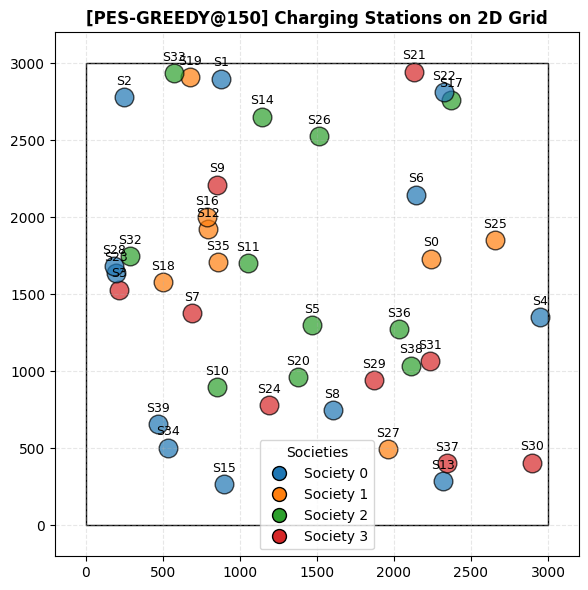

In [96]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

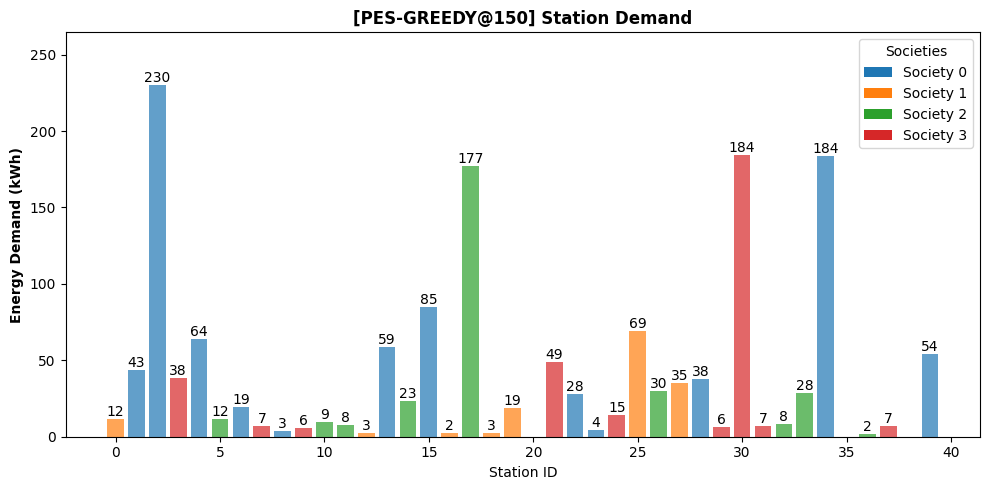

In [97]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

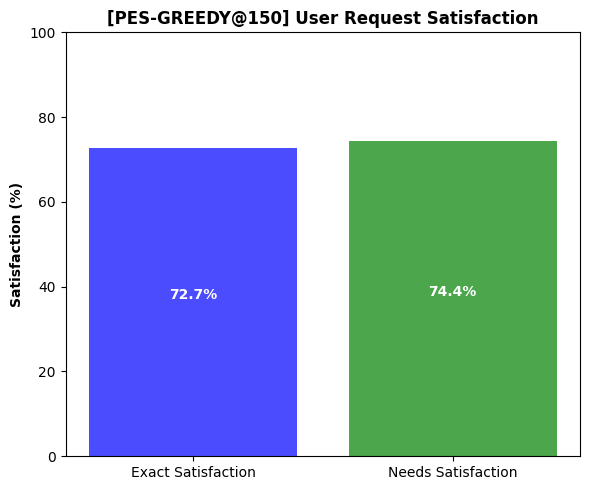

In [98]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

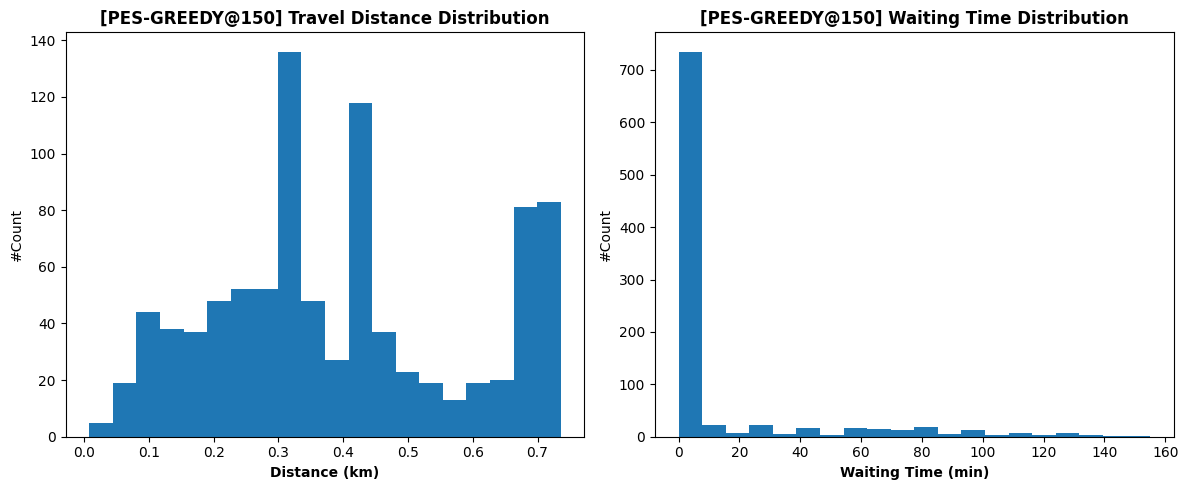

In [99]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

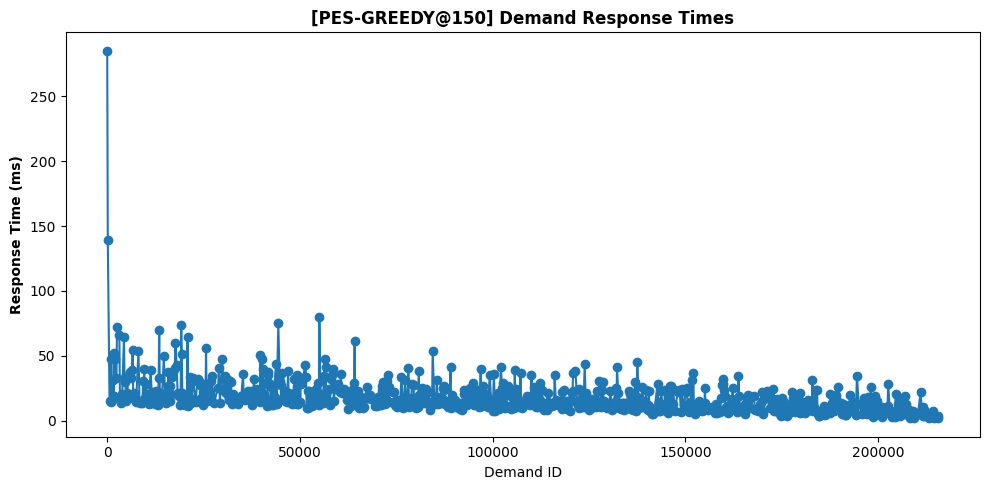

In [100]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

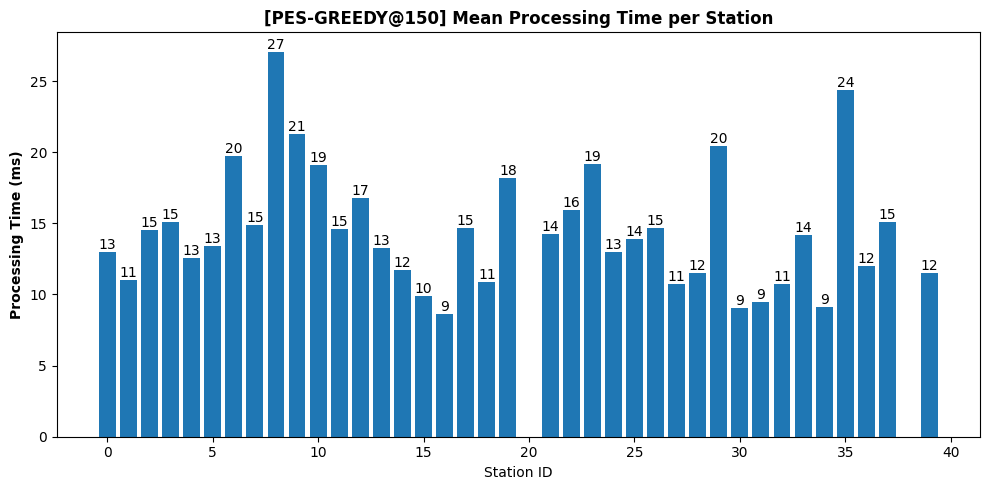

In [101]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [102]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           1  0.403472  0.230556  0.000000  0.020833       NaN   
1            0           2  0.565972  0.734028  0.486111  0.367361  0.492361   
2            0           4  0.372222  0.350000  0.079861  0.015972  0.121528   
3            0           6  0.168750  0.079167  0.000000  0.000000  0.000000   
4            0           8  0.072222  0.000000  0.000000  0.000000  0.000000   
5            0          13  0.440278  0.268750  0.000000  0.000000  0.117361   
6            0          15  0.481250  0.356250  0.177083  0.218056       NaN   
7            0          22  0.268750  0.117361  0.000000  0.000000  0.036111   
8            0          23  0.070833  0.000000  0.000000  0.000000  0.000000   
9            0          28  0.293056  0.218056  0.040972  0.069444       NaN   
10           0          34  0.718750  0.688194  0.584722  0.588889       NaN   
11           0          39  0.363889  0.

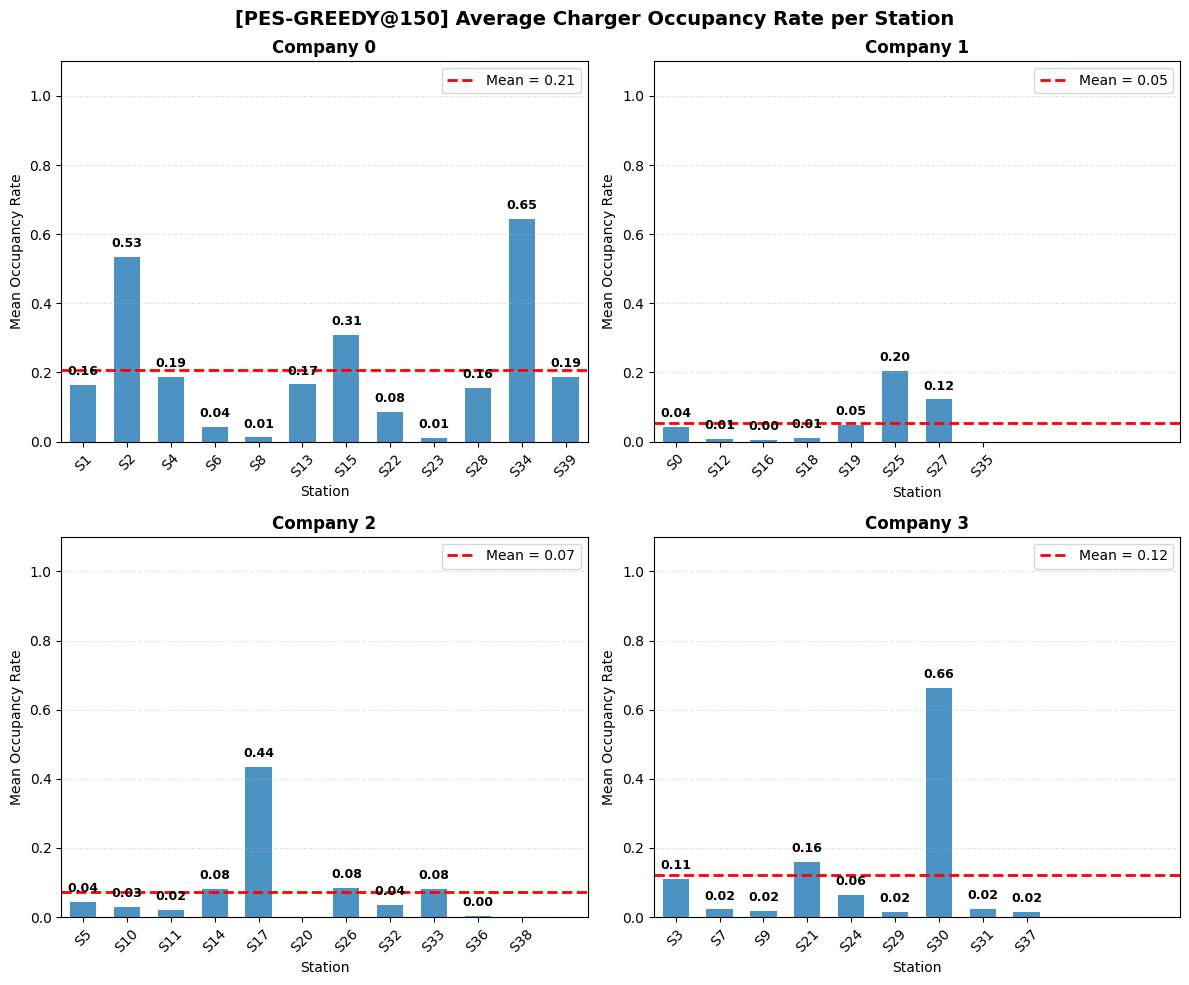

In [103]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

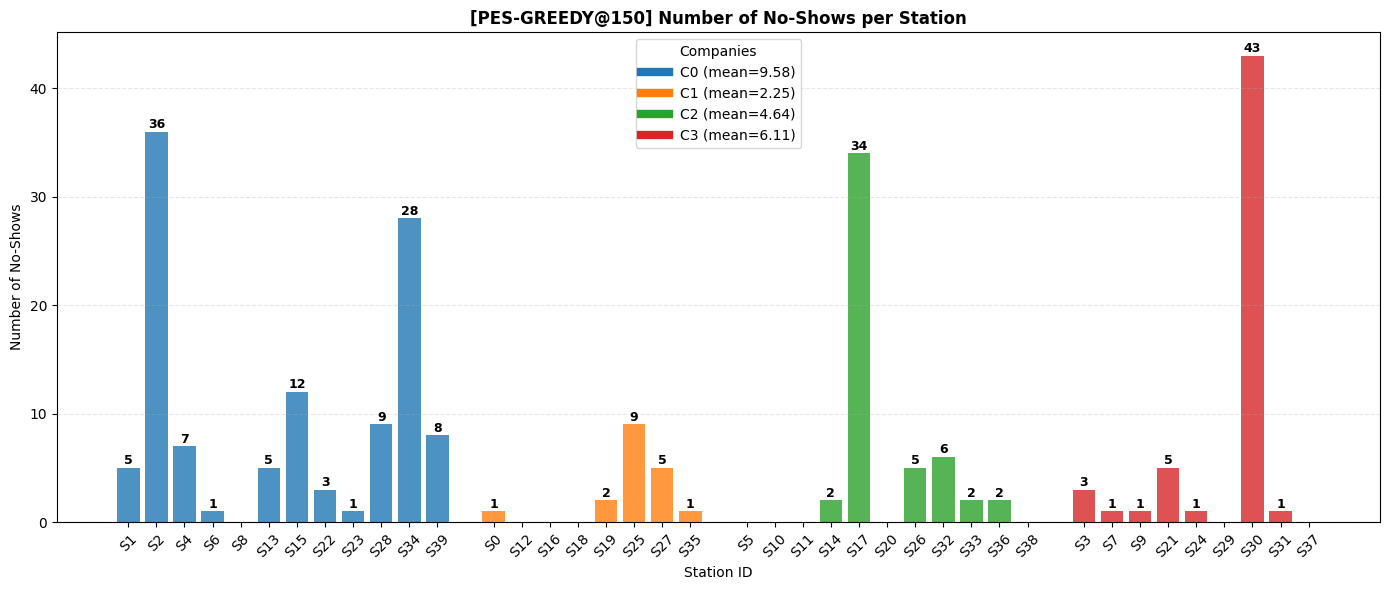

In [104]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [105]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,1,28,23,5,0,0,0.821429,0.178571,0.000000,0.000000
1,0,2,174,134,36,1,1,0.770115,0.206897,0.005747,0.005747
2,0,4,46,38,7,0,0,0.826087,0.152174,0.000000,0.000000
3,0,6,11,10,1,0,0,0.909091,0.090909,0.000000,0.000000
4,0,8,2,2,0,0,0,1.000000,0.000000,0.000000,0.000000
5,0,13,36,31,5,0,0,0.861111,0.138889,0.000000,0.000000
6,0,15,62,50,12,0,0,0.806452,0.193548,0.000000,0.000000
7,0,22,17,14,3,0,0,0.823529,0.176471,0.000000,0.000000
8,0,23,3,2,1,0,0,0.666667,0.333333,0.000000,0.000000
9,0,28,30,20,9,0,0,0.666667,0.300000,0.000000,0.000000


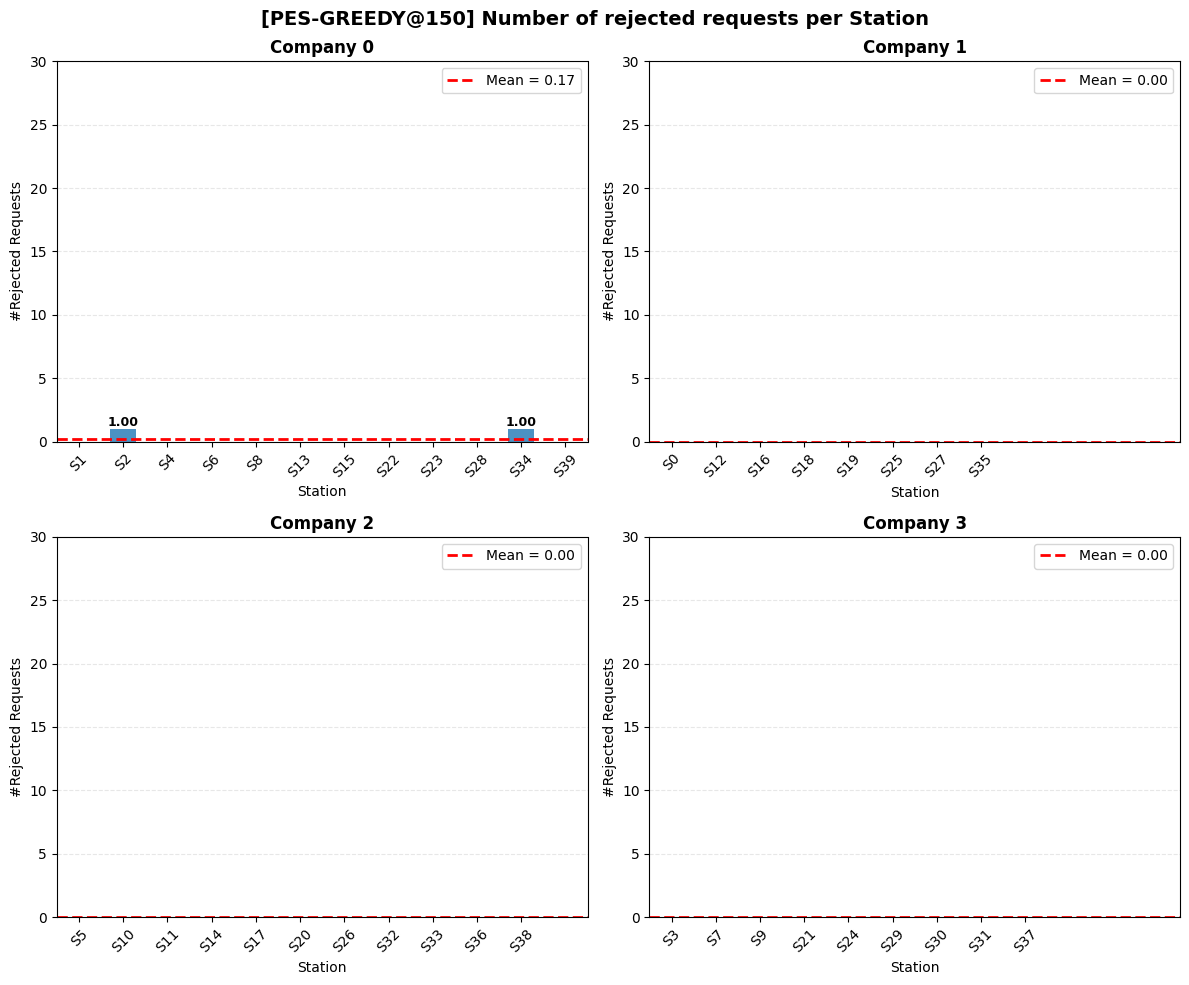

In [106]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [107]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [108]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [109]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-17 21:17:45.700 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-17 21:17:46.310 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-17 21:17:47.353 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-17 21:17:48.226 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-17 21:17:49.693 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-17 21:17:50.953 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-17 21:17:52.254 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-17 21:17:53.066 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-17 21:17:54.441 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-17 21:17:55.937 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-17 21:17:57.238 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [110]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 16.56 kWh
  Station 1: 94.40 kWh
  Station 2: 18.63 kWh
  Station 3: 5.42 kWh
  Station 4: 19.18 kWh
  Station 5: 47.59 kWh
  Station 6: 14.91 kWh
  Station 7: 9.54 kWh
  Station 8: 6.51 kWh
  Station 9: 57.66 kWh
  Station 10: 7.97 kWh
  Station 11: 2.03 kWh
  Station 12: 22.77 kWh
  Station 13: 38.32 kWh
  Station 14: 56.60 kWh
  Station 15: 29.52 kWh
  Station 16: 35.76 kWh
  Station 17: 135.48 kWh
  Station 18: 175.78 kWh
  Station 19: 6.58 kWh
  Station 20: 9.86 kWh
  Station 21: 3.27 kWh
  Station 22: 60.59 kWh
  Station 23: 53.93 kWh
  Station 24: 5.62 kWh
  Station 25: 100.45 kWh
  Station 26: 55.91 kWh
  Station 27: 12.53 kWh
  Station 28: 64.80 kWh
  Station 29: 7.31 kWh
  Station 30: 28.24 kWh
  Station 31: 34.57 kWh
  Station 32: 20.28 kWh
  Station 33: 13.02 kWh
  Station 34: 5.60 kWh
  Station 35: 23.79 kWh
  Station 36: 153.22 kWh
  Station 37: 21.51 kWh
  Station 38: 11.73 kWh
  Station 39: 128.

In [111]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

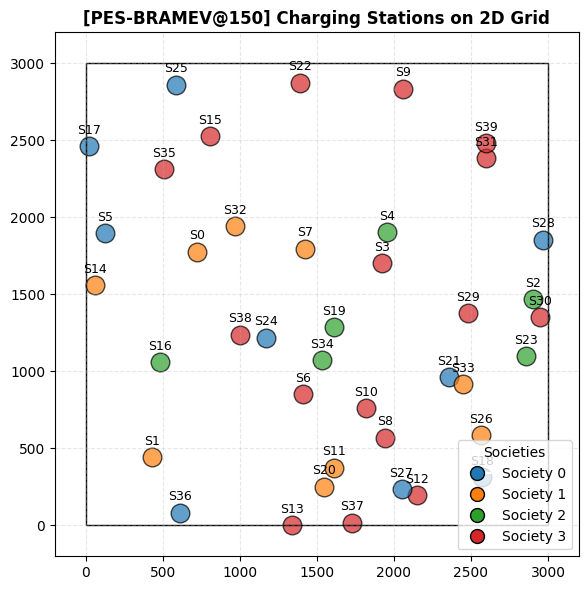

In [112]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

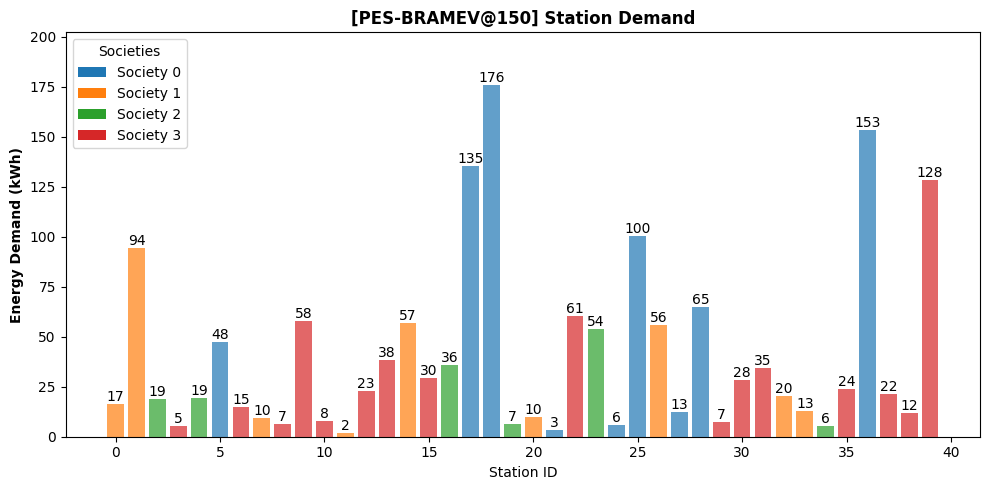

In [113]:
plot_station_demand(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, societies=societies, figsize=(10, 5))

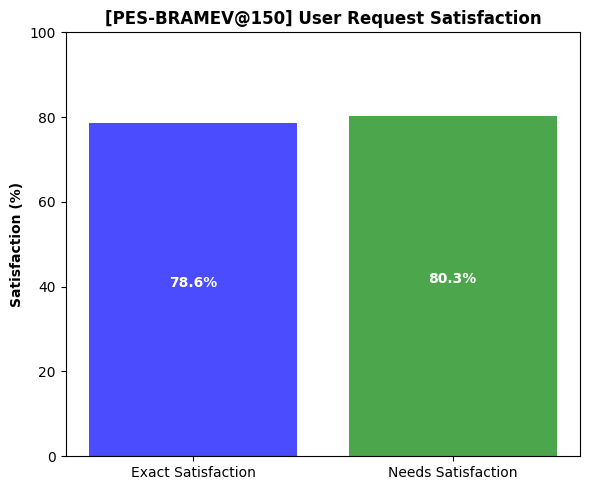

In [114]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

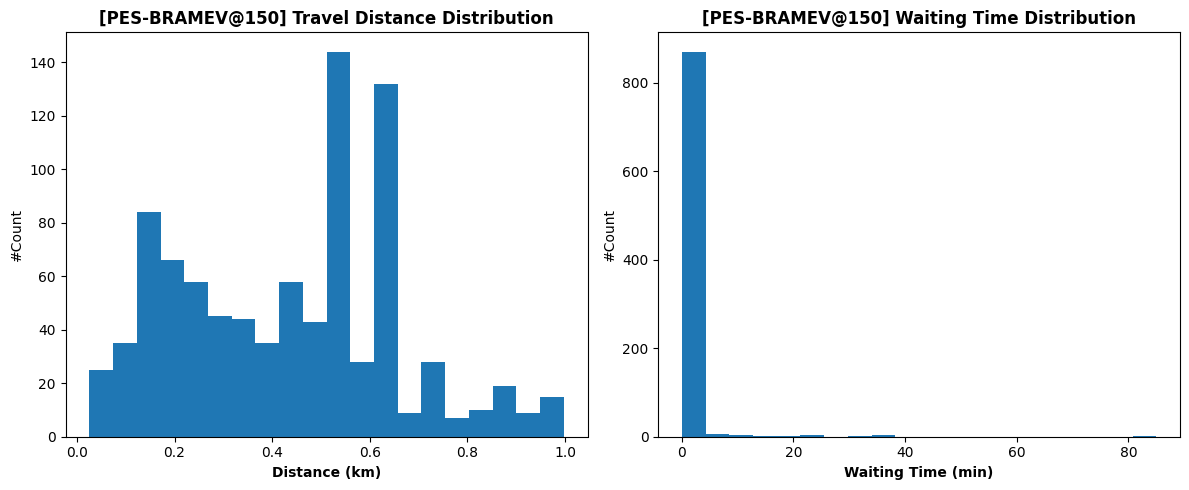

In [115]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

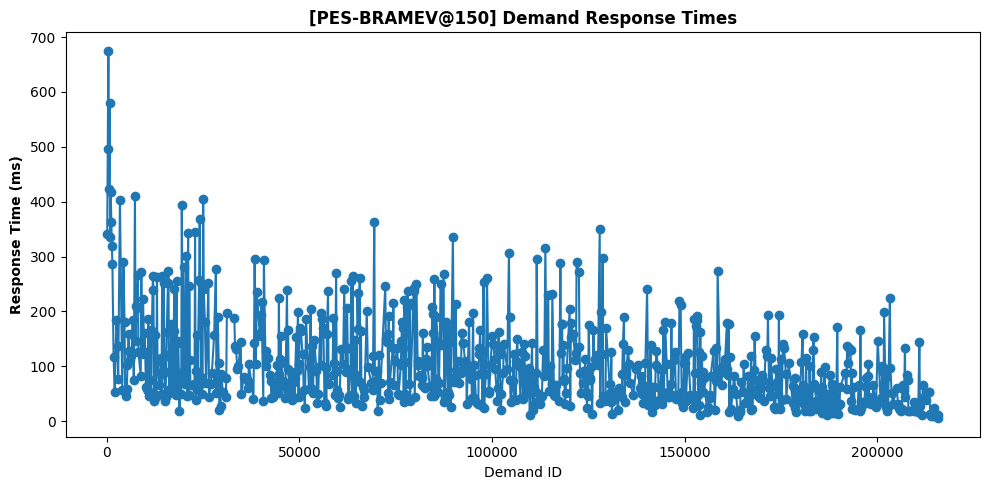

In [116]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

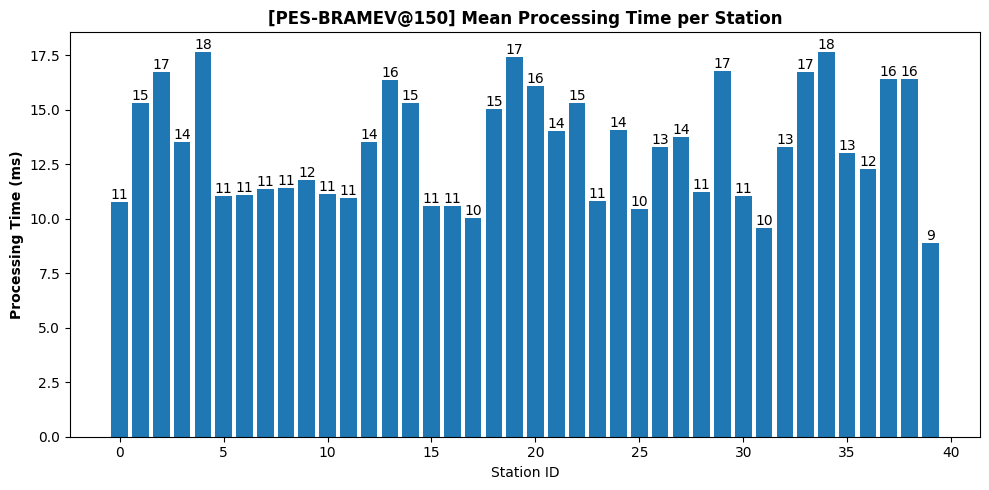

In [117]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

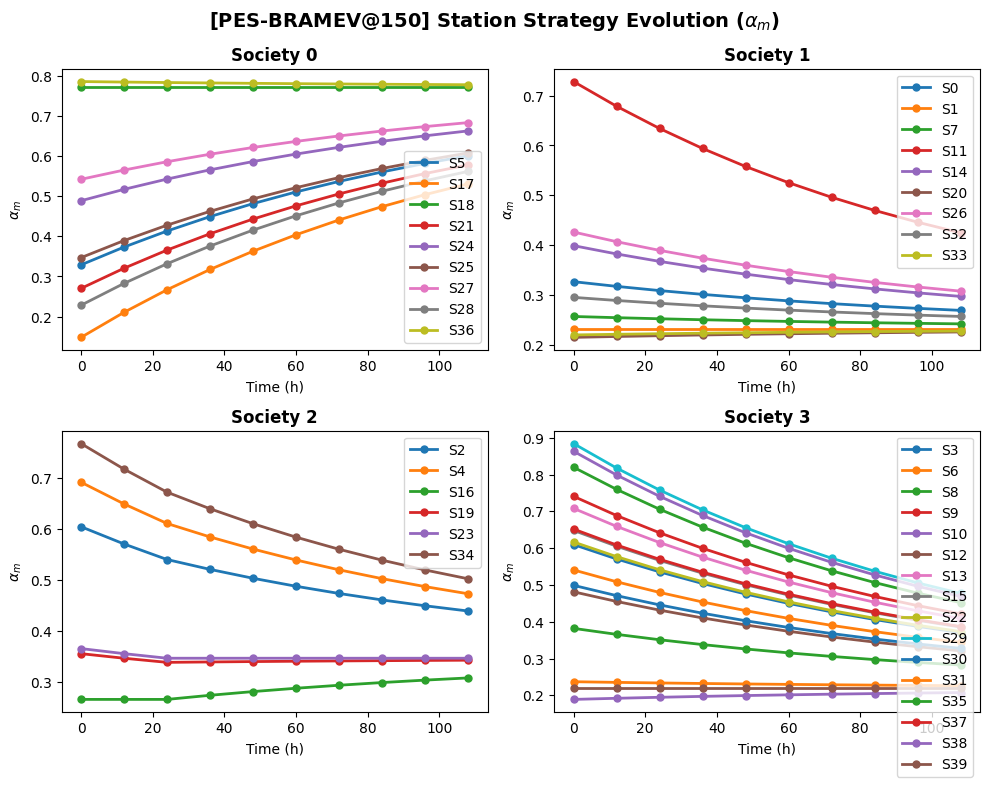

In [118]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [119]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           5  0.329861  0.186111  0.061111  0.077778       NaN   
1            0          17  0.551389  0.549306  0.427083  0.343056       NaN   
2            0          18  0.544444  0.461806  0.435417  0.326389  0.247222   
3            0          21  0.045139  0.000000  0.000000  0.000000  0.000000   
4            0          24  0.078472  0.000000  0.000000  0.000000  0.000000   
5            0          25  0.560417  0.481944  0.186111  0.218750       NaN   
6            0          27  0.183333  0.020833  0.000000  0.000000  0.000000   
7            0          28  0.445833  0.304861  0.093056  0.058333       NaN   
8            0          36  0.703472  0.579167  0.395139  0.305556  0.413889   
9            1           0  0.218056  0.028472  0.000000  0.000000       NaN   
10           1           1  0.550000  0.327083  0.188194  0.090972  0.065972   
11           1           7  0.111806  0.

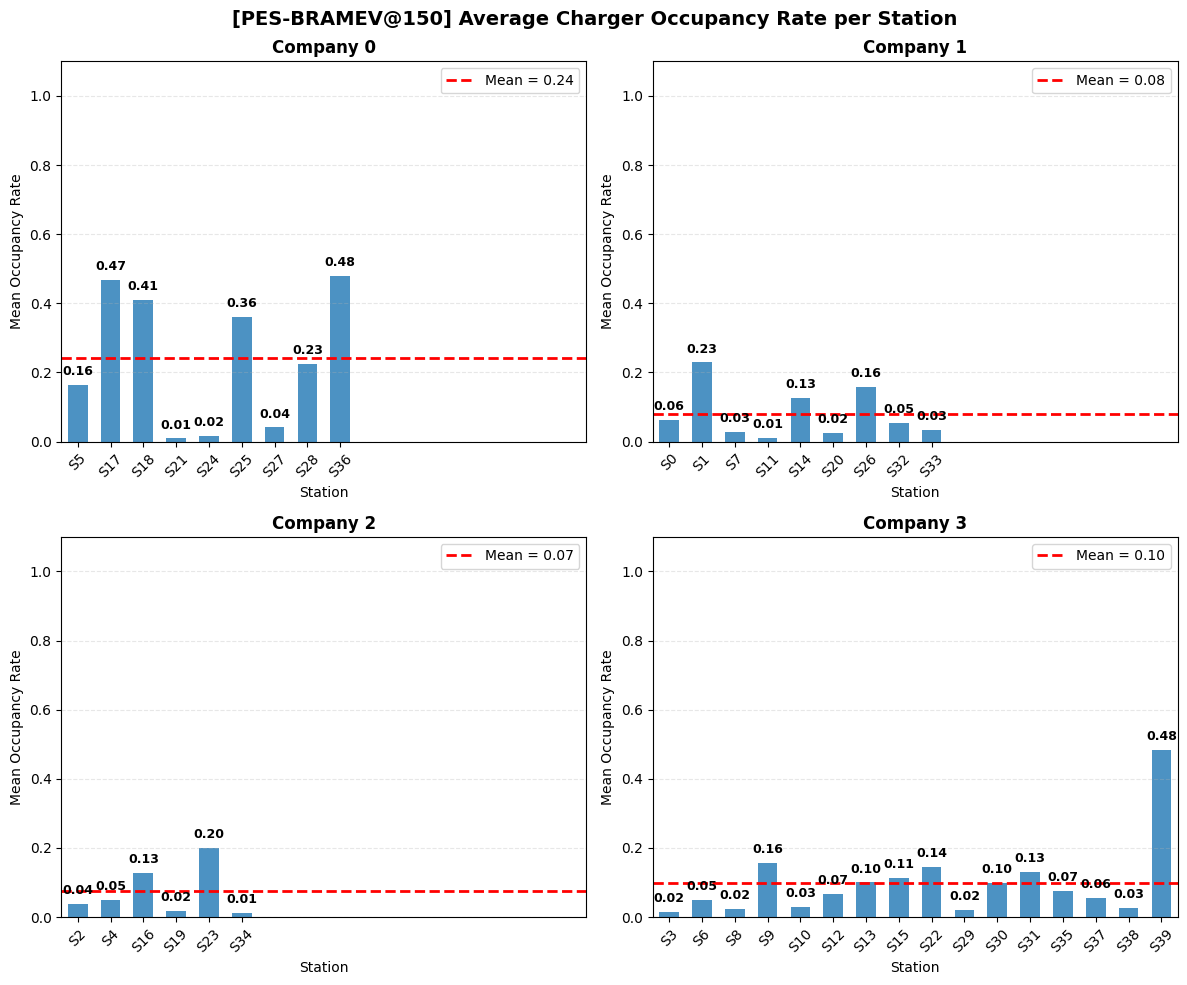

In [120]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

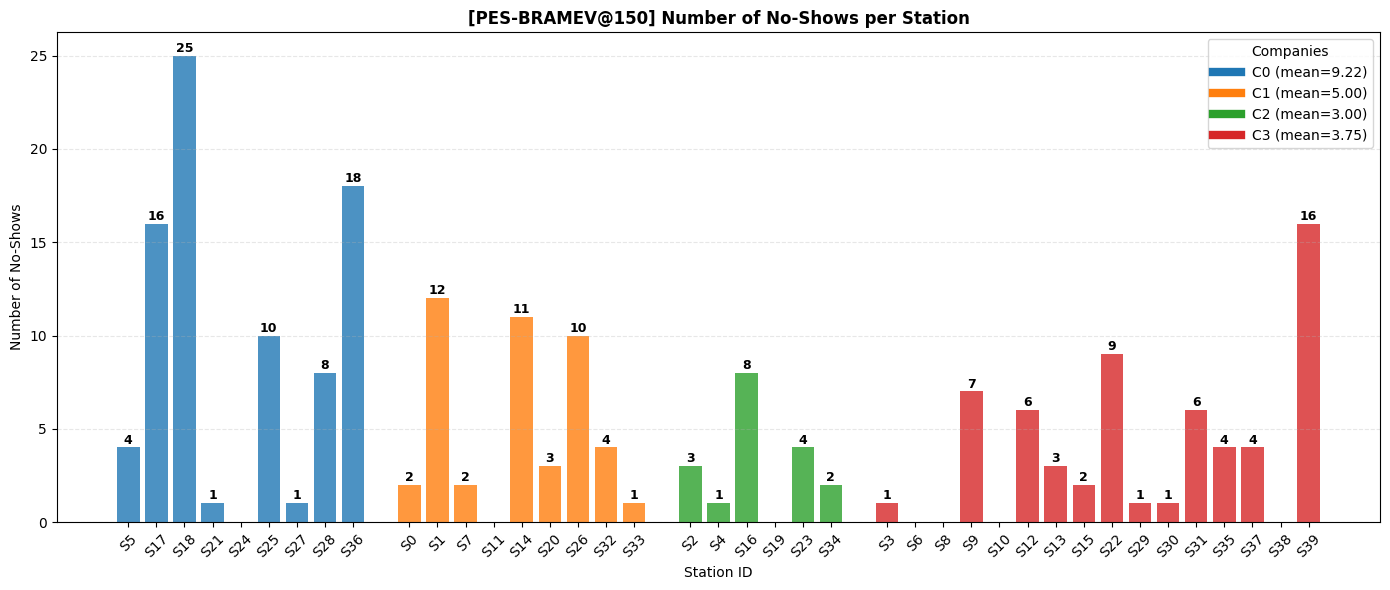

In [121]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [122]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,5,31,27,4,0,0,0.870968,0.129032,0.0,0.0
1,0,17,87,71,16,0,0,0.816092,0.183908,0.0,0.0
2,0,18,123,97,25,0,0,0.788618,0.203252,0.0,0.0
3,0,21,4,3,1,0,0,0.750000,0.250000,0.0,0.0
4,0,24,3,3,0,0,0,1.000000,0.000000,0.0,0.0
5,0,25,63,53,10,0,0,0.841270,0.158730,0.0,0.0
6,0,27,8,7,1,0,0,0.875000,0.125000,0.0,0.0
7,0,28,45,36,8,0,0,0.800000,0.177778,0.0,0.0
8,0,36,105,87,18,0,0,0.828571,0.171429,0.0,0.0
9,1,0,12,10,2,0,0,0.833333,0.166667,0.0,0.0


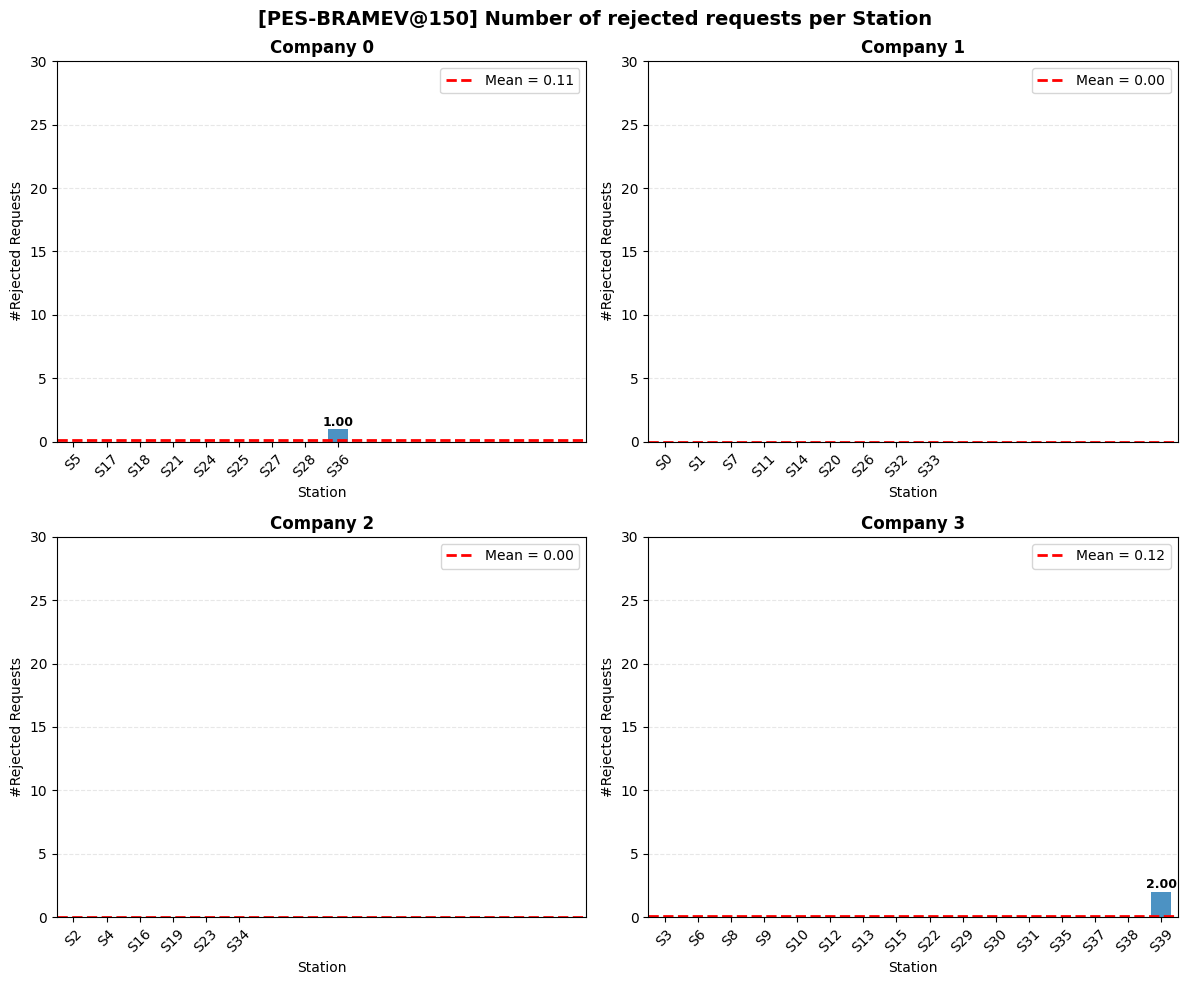

In [123]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [124]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

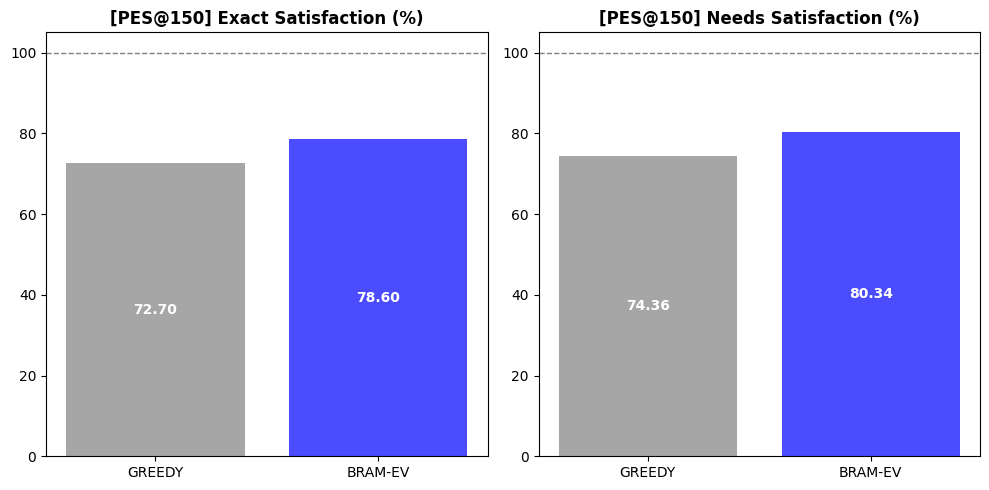

In [125]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

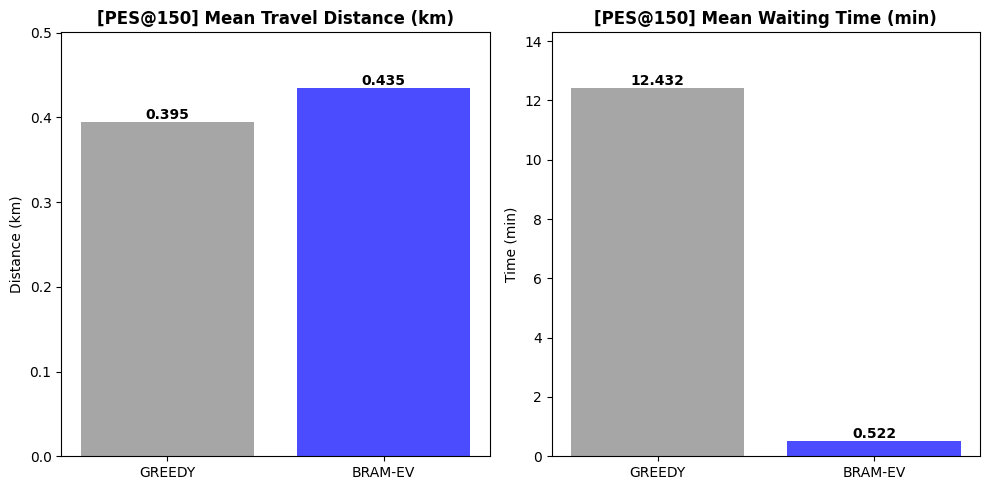

In [126]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

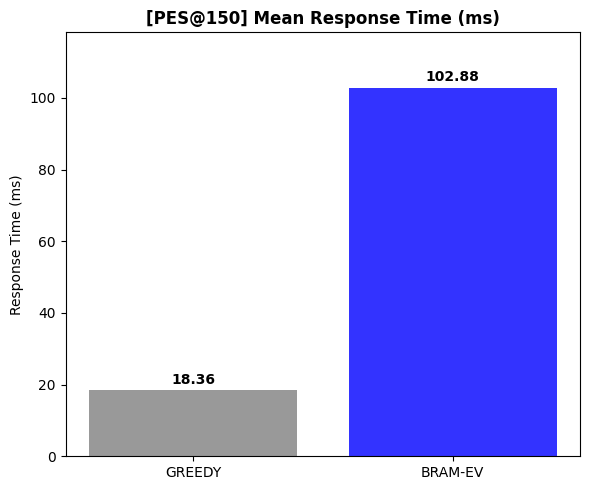

In [127]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@200cars**

#### **CONFIG**

In [128]:
nb_car = 200
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [129]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [130]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [131]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-17 21:19:12.384 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-06-17 21:19:12.598 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-06-17 21:19:13.038 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-06-17 21:19:13.375 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-06-17 21:19:13.738 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-06-17 21:19:14.169 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-06-17 21:19:14.603 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-06-17 21:19:14.998 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-06-17 21:19:15.316 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-06-17 21:19:15.567 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-06-17 21:19:16.046 | IN

##### *Metrics*

In [132]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 90.10 kWh
  Station 1: 4.93 kWh
  Station 2: 3.27 kWh
  Station 3: 8.52 kWh
  Station 4: 3.42 kWh
  Station 5: 10.31 kWh
  Station 6: 84.44 kWh
  Station 7: 5.43 kWh
  Station 8: 9.18 kWh
  Station 9: 7.83 kWh
  Station 10: 11.72 kWh
  Station 11: 278.23 kWh
  Station 12: 257.97 kWh
  Station 13: 259.21 kWh
  Station 14: 78.10 kWh
  Station 15: 12.55 kWh
  Station 16: 47.73 kWh
  Station 17: 4.67 kWh
  Station 18: 36.23 kWh
  Station 19: 112.57 kWh
  Station 20: 48.29 kWh
  Station 21: 226.72 kWh
  Station 22: 4.18 kWh
  Station 23: 6.80 kWh
  Station 24: 38.27 kWh
  Station 25: 41.27 kWh
  Station 26: 23.72 kWh
  Station 27: 1.53 kWh
  Station 28: 13.57 kWh
  Station 29: 3.66 kWh
  Station 30: 95.36 kWh
  Station 31: 101.49 kWh
  Station 32: 20.02 kWh
  Station 33: 107.81 kWh
  Station 34: 3.77 kWh
  Station 35: 12.34 kWh
  Station 36: 12.31 kWh
  Station 37: 33.29 kWh
  Station 38: 3.09 kWh
  Station 39: 16.8

In [133]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

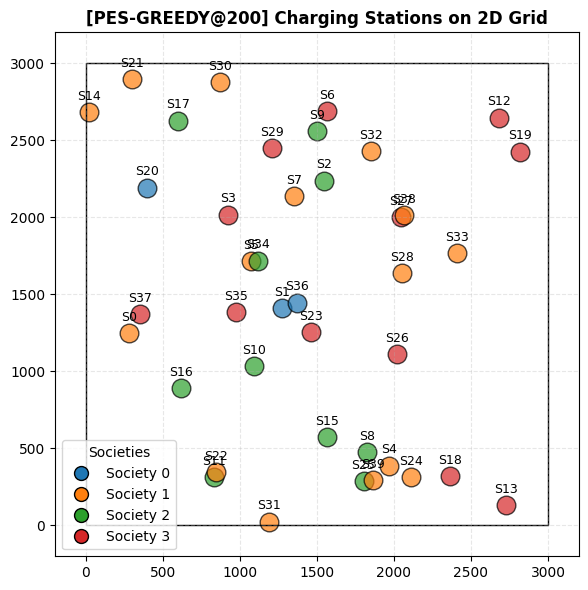

In [134]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

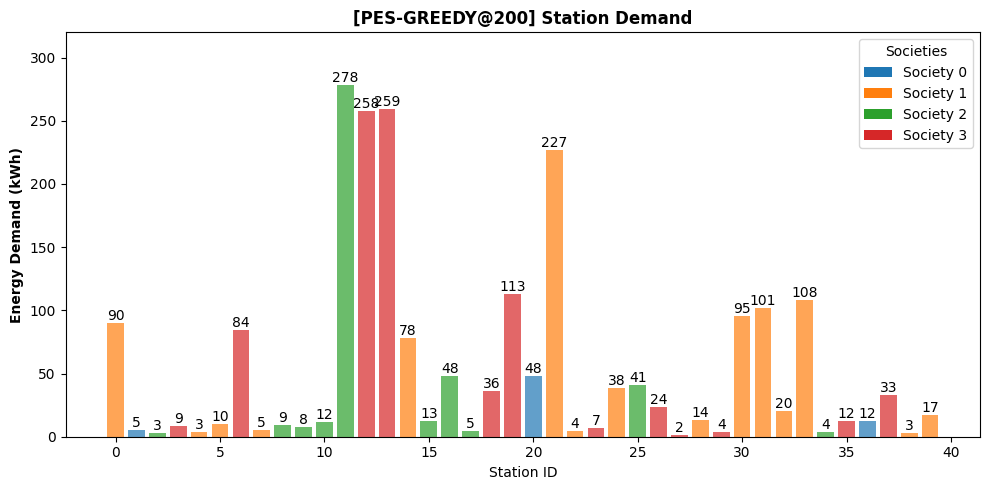

In [135]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

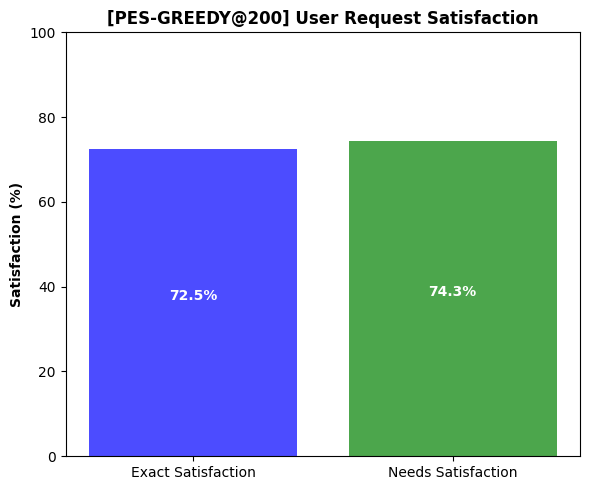

In [136]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

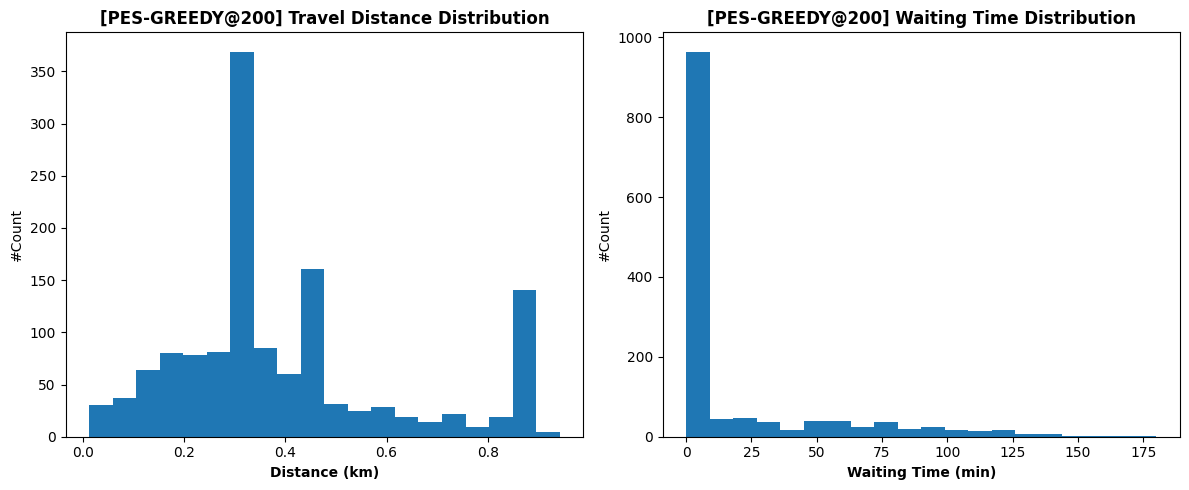

In [137]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

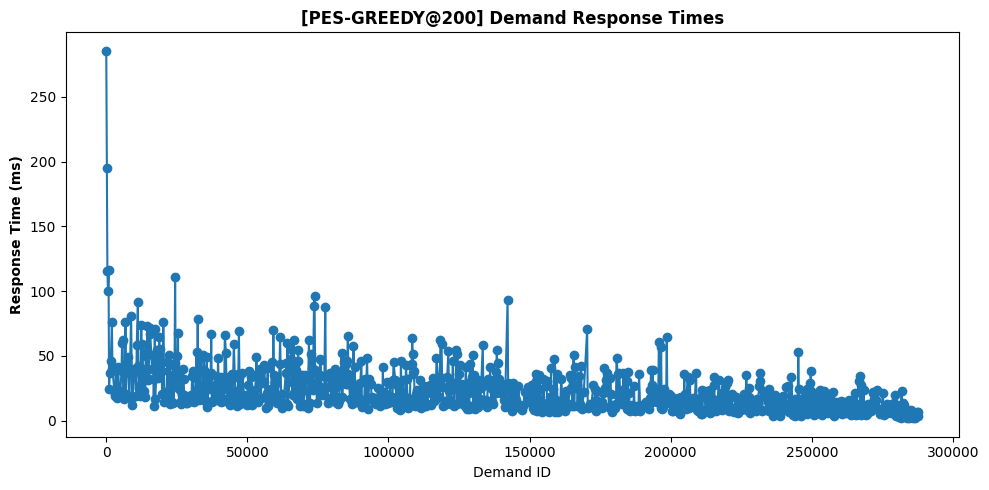

In [138]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

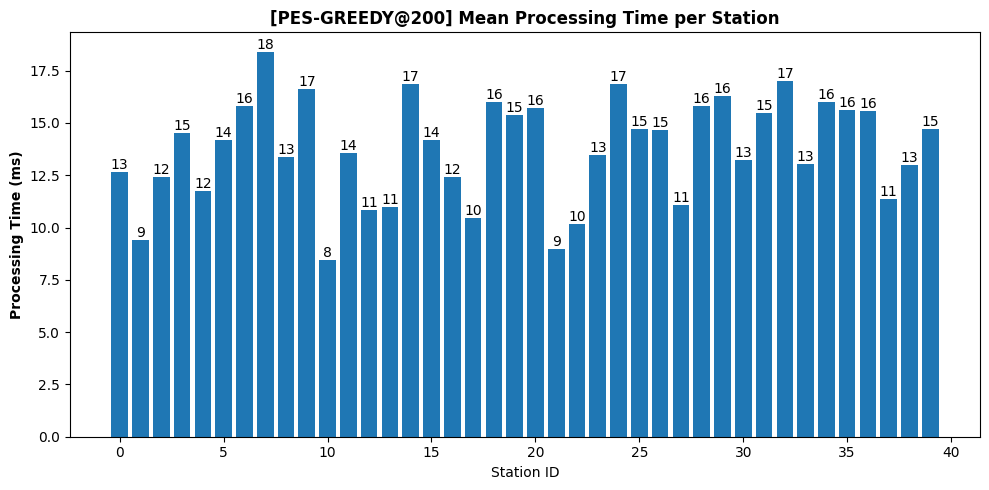

In [139]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [140]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           1  0.048611  0.023611  0.000000  0.000000       NaN   
1            0          20  0.498611  0.102778  0.000000  0.000000  0.018750   
2            0          36  0.190278  0.000000  0.000000  0.000000  0.000000   
3            1           0  0.547917  0.206250  0.134028  0.188889  0.231944   
4            1           4  0.048611  0.000000  0.000000  0.000000       NaN   
5            1           5  0.143056  0.000000  0.000000  0.000000  0.000000   
6            1           7  0.075694  0.000000  0.000000  0.000000  0.000000   
7            1          14  0.390278  0.320833  0.096528  0.038889  0.085417   
8            1          21  0.737500  0.844444  0.781250  0.694444       NaN   
9            1          22  0.055556  0.000000  0.000000  0.000000       NaN   
10           1          24  0.338889  0.123611  0.018056  0.000000  0.000000   
11           1          28  0.166667  0.

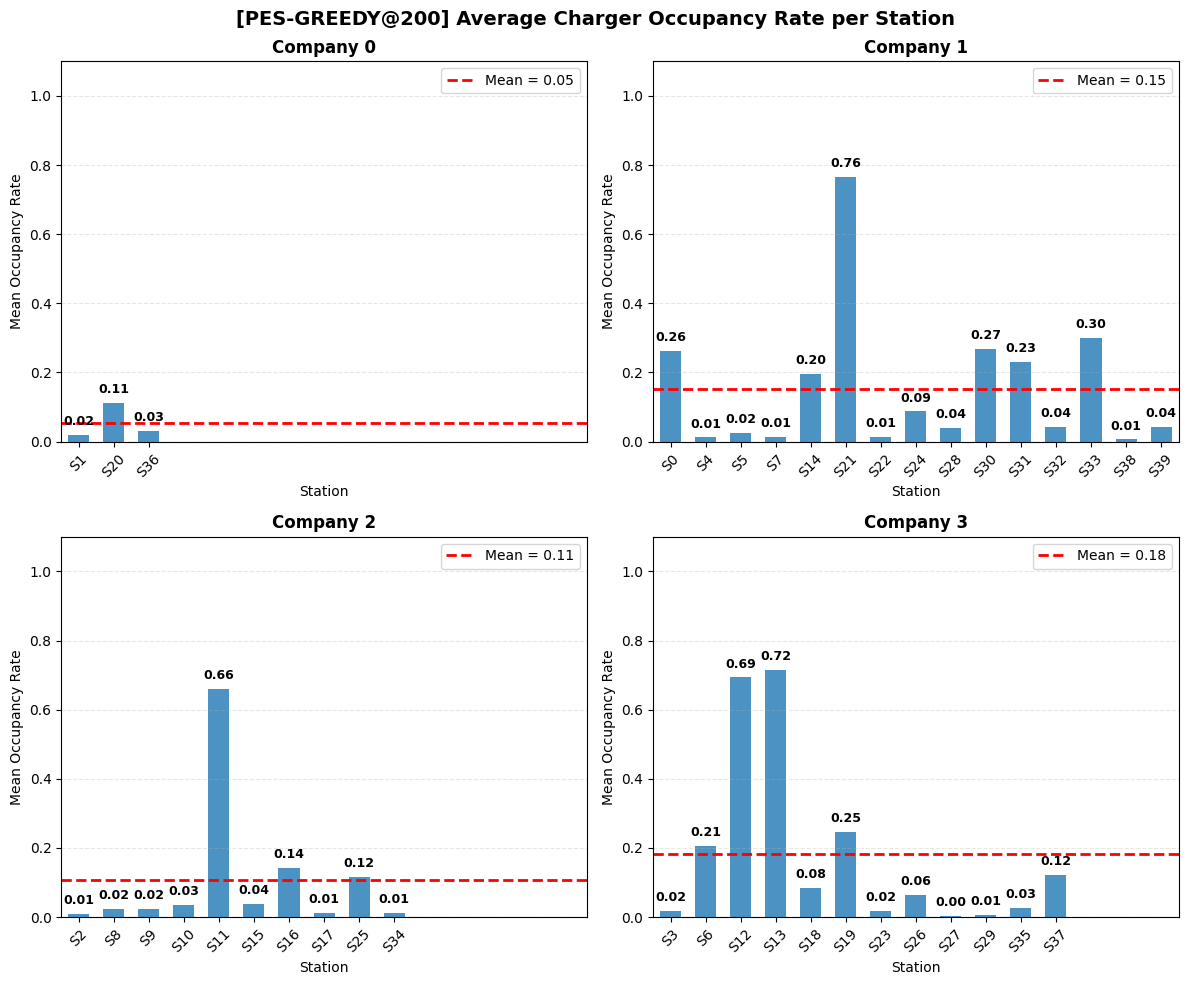

In [141]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

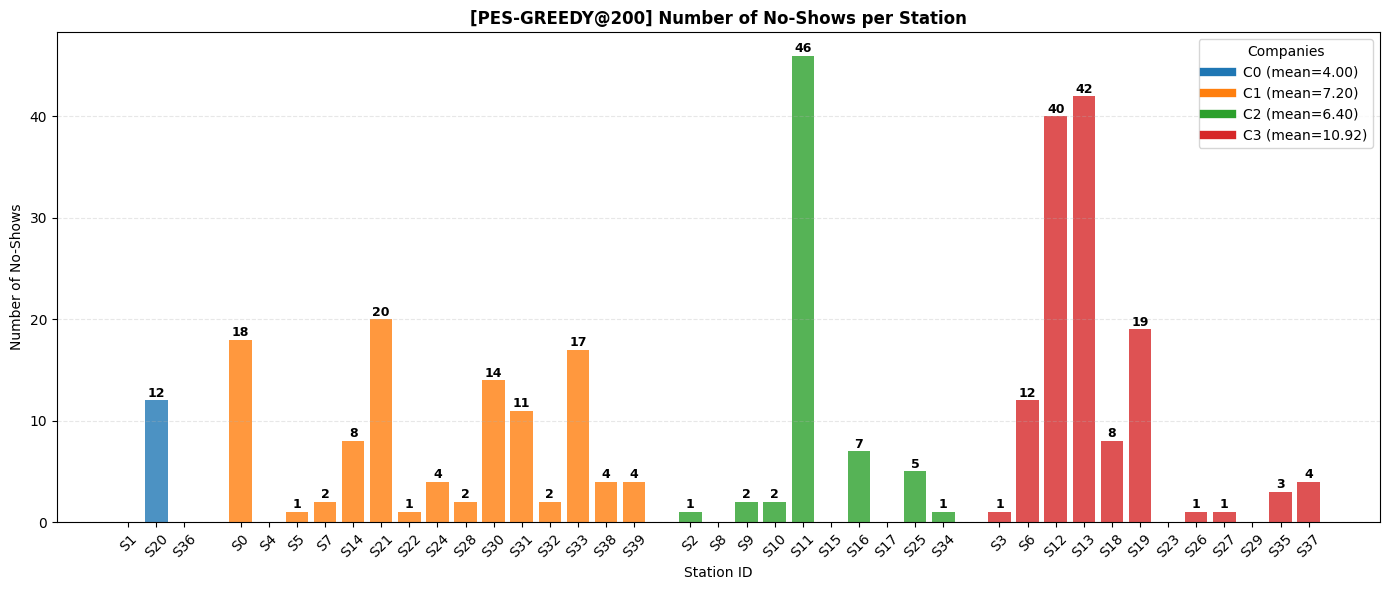

In [142]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [143]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,1,3,3,0,0,0,1.000000,0.000000,0.000000,0.000000
1,0,20,40,28,12,0,0,0.700000,0.300000,0.000000,0.000000
2,0,36,7,7,0,0,0,1.000000,0.000000,0.000000,0.000000
3,1,0,71,51,18,0,0,0.718310,0.253521,0.000000,0.000000
4,1,4,2,2,0,0,0,1.000000,0.000000,0.000000,0.000000
5,1,5,7,6,1,0,0,0.857143,0.142857,0.000000,0.000000
6,1,7,5,3,2,0,0,0.600000,0.400000,0.000000,0.000000
7,1,14,55,46,8,0,0,0.836364,0.145455,0.000000,0.000000
8,1,21,199,166,20,10,1,0.834171,0.100503,0.050251,0.005025
9,1,22,4,3,1,0,0,0.750000,0.250000,0.000000,0.000000


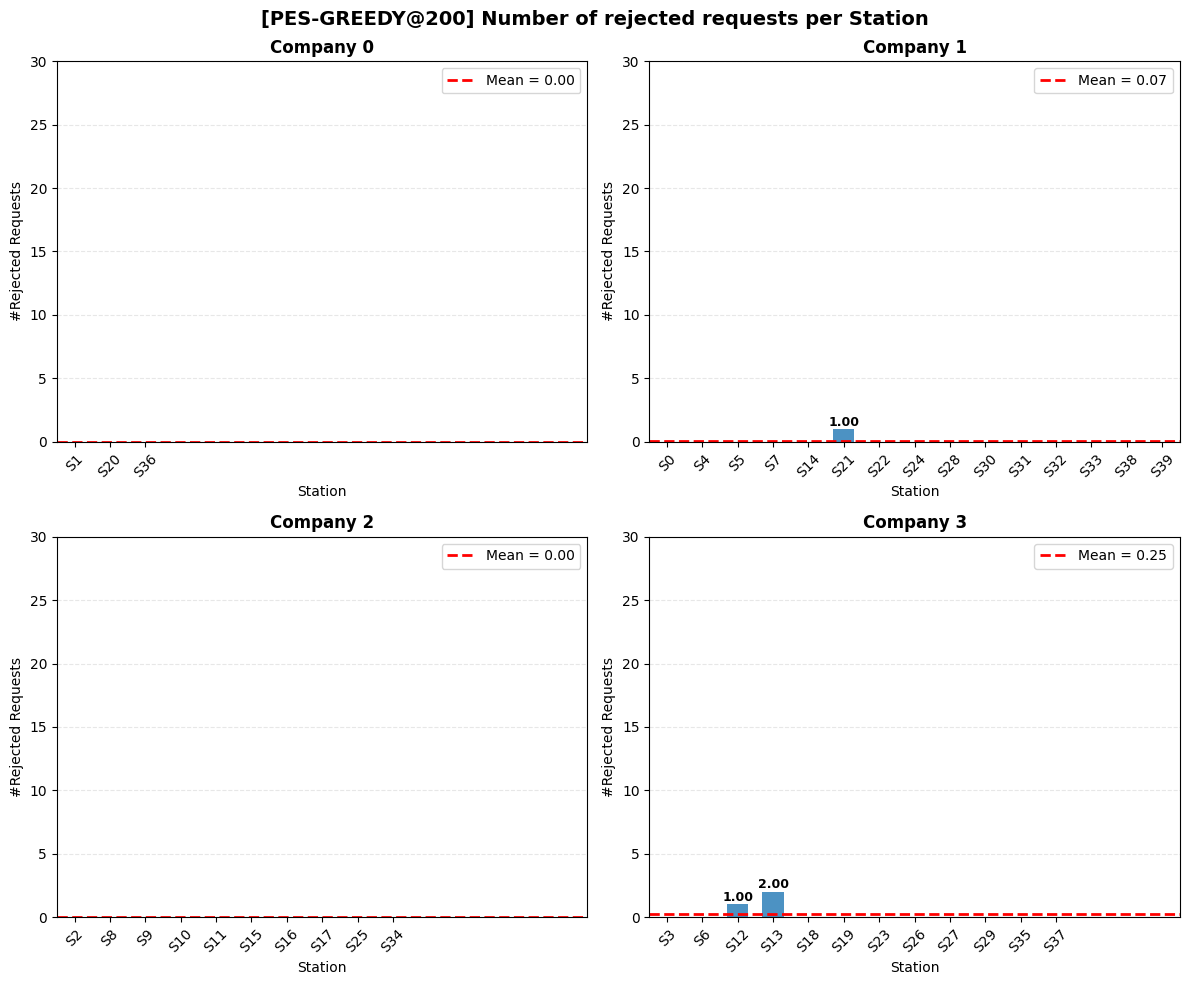

In [144]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [145]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [146]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [147]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-17 21:19:44.851 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-17 21:19:48.397 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-17 21:19:50.255 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-17 21:19:51.923 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-17 21:19:54.531 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-17 21:19:56.628 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-17 21:19:58.403 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-17 21:19:59.578 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-17 21:20:00.953 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-17 21:20:03.440 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-17 21:20:04.880 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [148]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 39.72 kWh
  Station 1: 5.34 kWh
  Station 2: 46.62 kWh
  Station 3: 163.48 kWh
  Station 4: 147.06 kWh
  Station 5: 4.12 kWh
  Station 6: 72.27 kWh
  Station 7: 79.09 kWh
  Station 8: 165.53 kWh
  Station 9: 19.38 kWh
  Station 10: 77.17 kWh
  Station 11: 17.97 kWh
  Station 12: 5.47 kWh
  Station 13: 46.18 kWh
  Station 14: 186.57 kWh
  Station 15: 75.66 kWh
  Station 16: 55.02 kWh
  Station 17: 108.39 kWh
  Station 18: 13.88 kWh
  Station 19: 9.64 kWh
  Station 20: 44.12 kWh
  Station 21: 6.37 kWh
  Station 22: 56.50 kWh
  Station 23: 201.24 kWh
  Station 24: 66.76 kWh
  Station 25: 38.02 kWh
  Station 26: 12.42 kWh
  Station 27: 9.15 kWh
  Station 28: 13.27 kWh
  Station 29: 78.58 kWh
  Station 30: 73.17 kWh
  Station 31: 3.87 kWh
  Station 32: 15.10 kWh
  Station 33: 8.84 kWh
  Station 34: 1.67 kWh
  Station 35: 71.52 kWh
  Station 36: 72.66 kWh
  Station 37: 13.28 kWh
  Station 38: 63.35 kWh
  Station 39: 

In [149]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

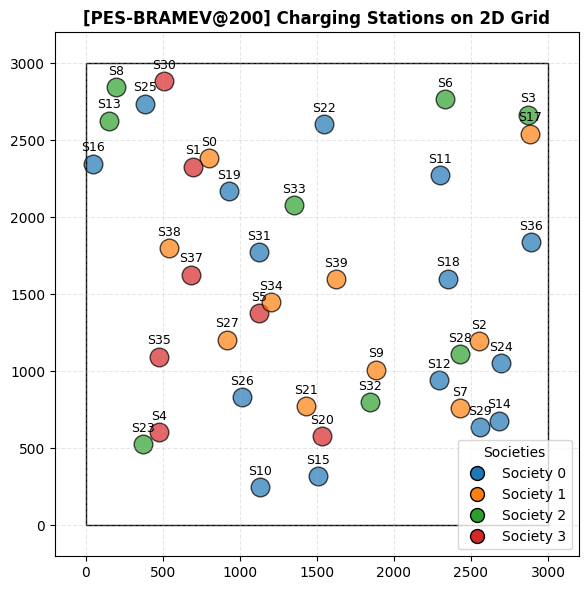

In [150]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

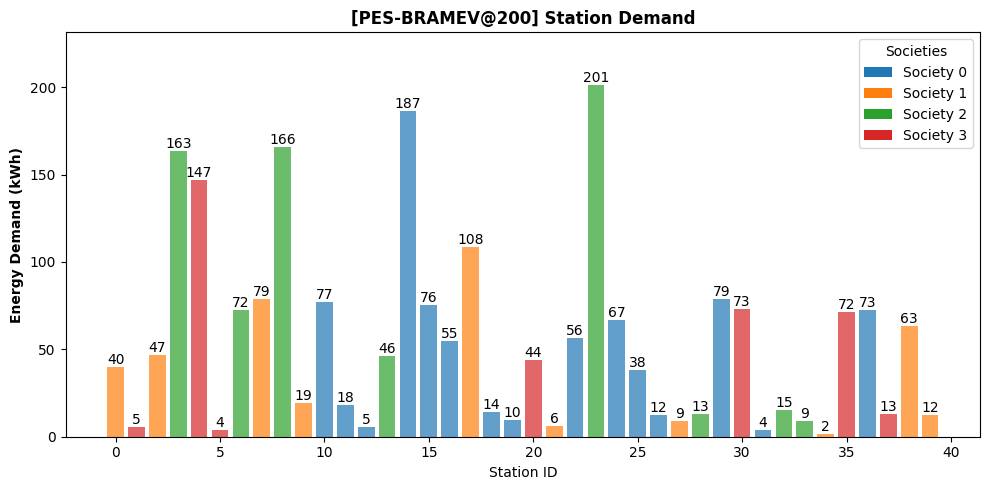

In [151]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

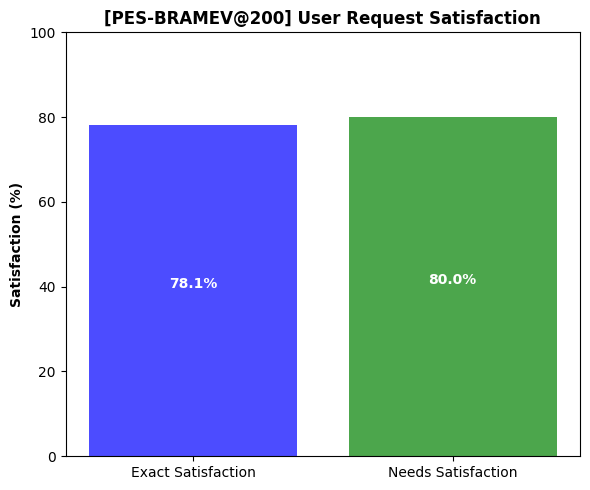

In [152]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

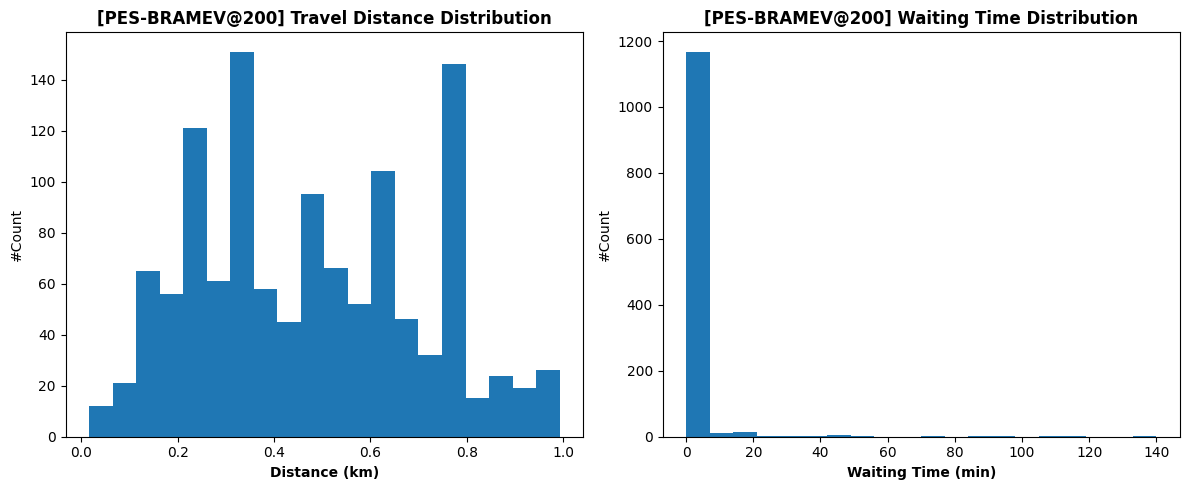

In [153]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

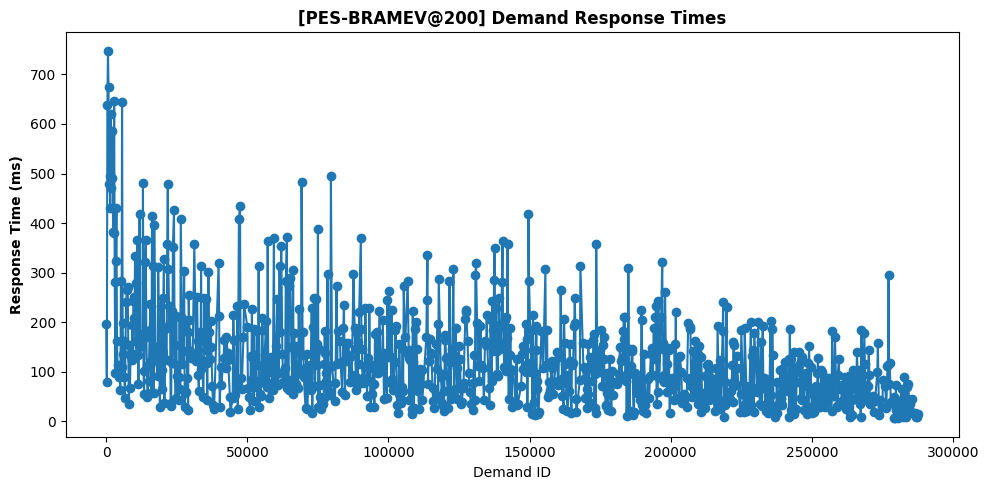

In [154]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

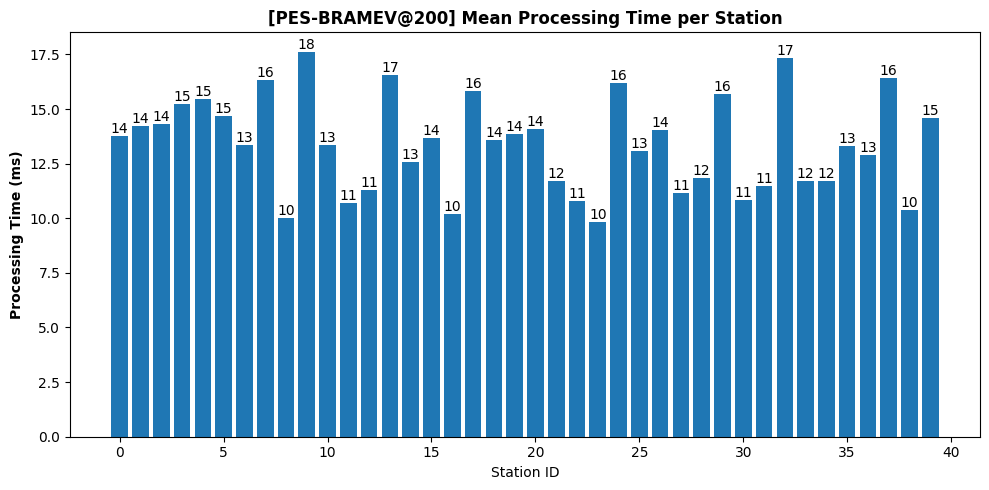

In [155]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

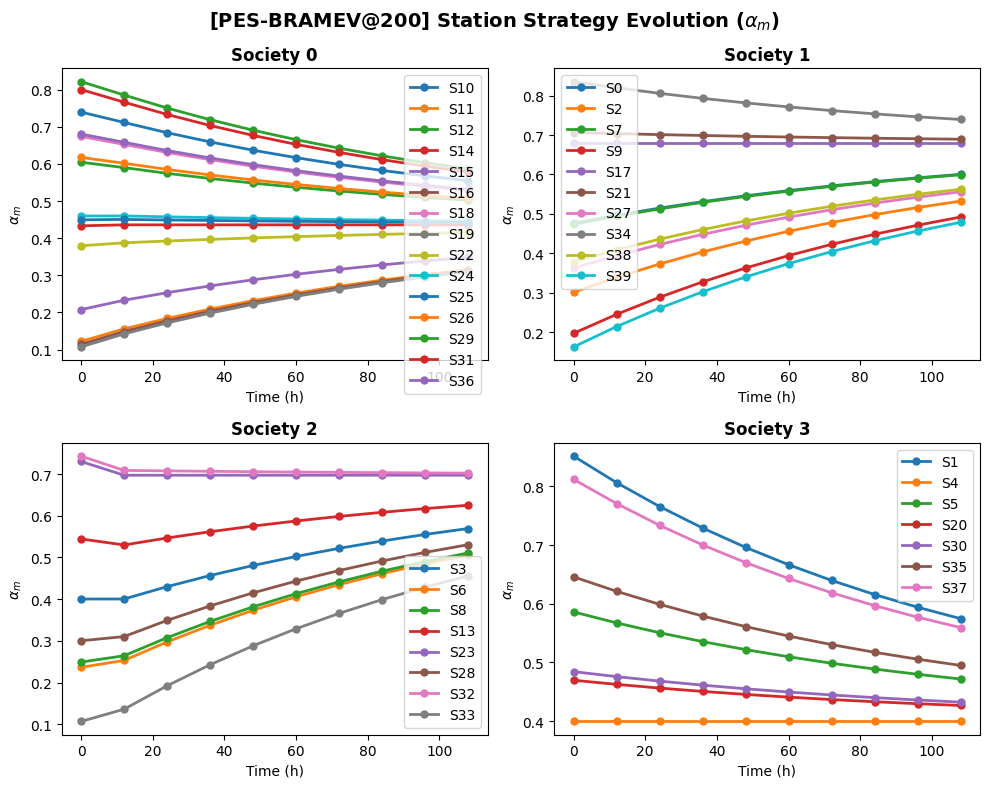

In [156]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [157]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0          10  0.451389  0.406944  0.106250  0.015972  0.138194   
1            0          11  0.207639  0.043056  0.000000  0.000000       NaN   
2            0          12  0.069444  0.009028  0.000000  0.000000       NaN   
3            0          14  0.675000  0.634722  0.356250  0.490972  0.415972   
4            0          15  0.547917  0.233333  0.080556  0.000000  0.207639   
5            0          16  0.334722  0.295139  0.109722  0.106250       NaN   
6            0          18  0.134028  0.040972  0.011806  0.000000  0.000000   
7            0          19  0.079167  0.063194  0.000000  0.000000  0.000000   
8            0          22  0.361806  0.281944  0.085417  0.047917       NaN   
9            0          24  0.387500  0.263194  0.081944  0.040278  0.031250   
10           0          25  0.352778  0.242361  0.016667  0.000000  0.032639   
11           0          26  0.111806  0.

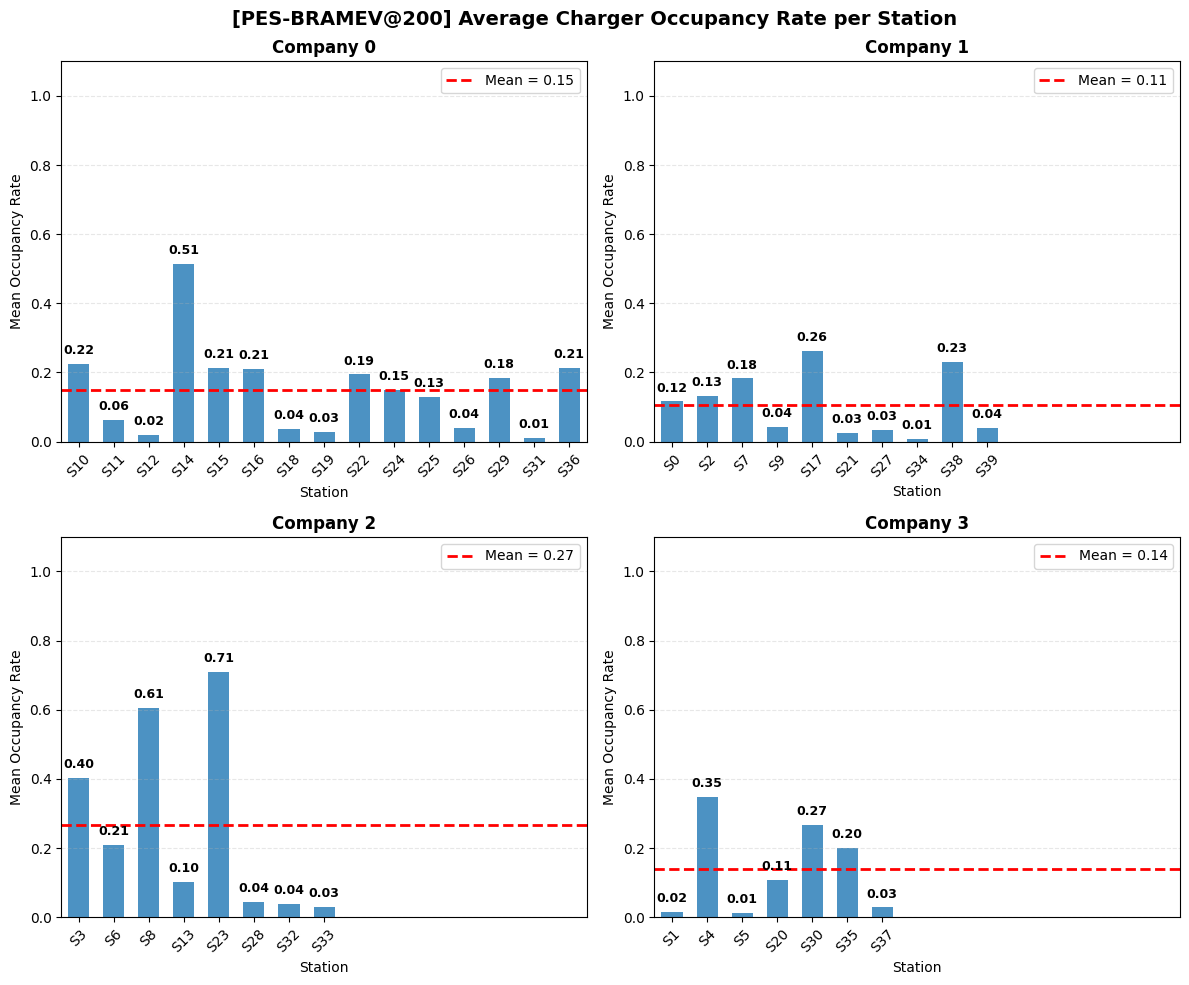

In [158]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

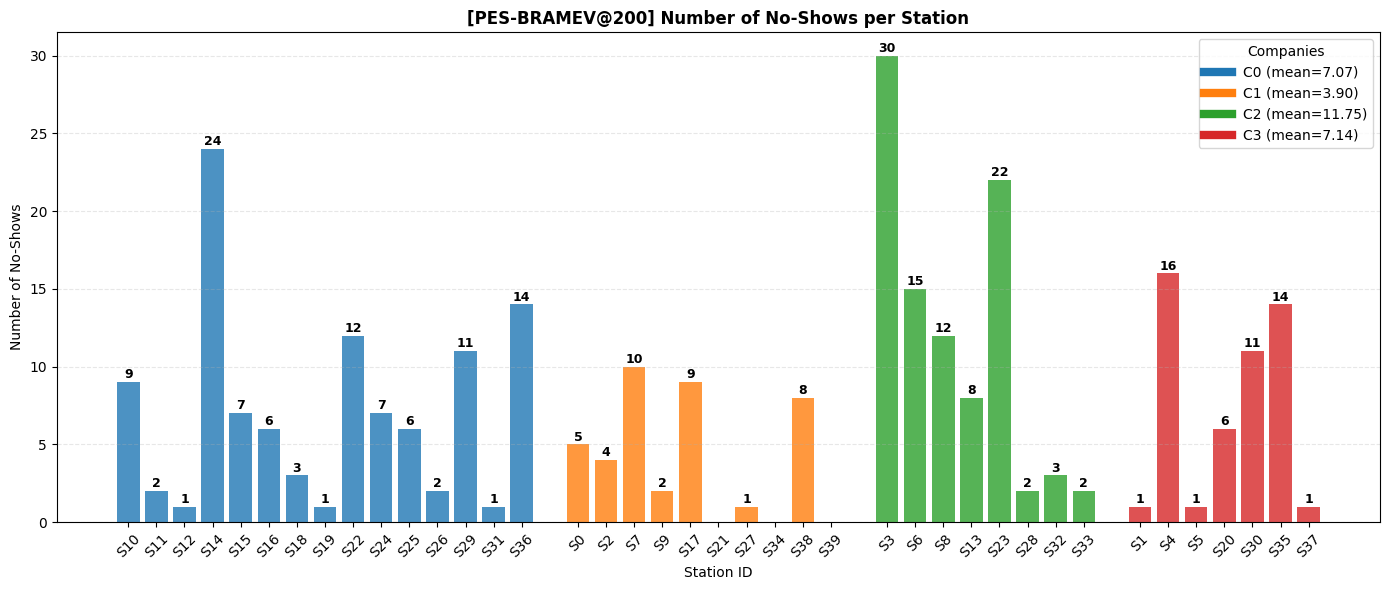

In [159]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [160]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,10,52,43,9,0,0,0.826923,0.173077,0.000000,0.0
1,0,11,13,11,2,0,0,0.846154,0.153846,0.000000,0.0
2,0,12,5,4,1,0,0,0.800000,0.200000,0.000000,0.0
3,0,14,129,104,24,0,0,0.806202,0.186047,0.000000,0.0
4,0,15,49,42,7,0,0,0.857143,0.142857,0.000000,0.0
5,0,16,37,31,6,0,0,0.837838,0.162162,0.000000,0.0
6,0,18,12,9,3,0,0,0.750000,0.250000,0.000000,0.0
7,0,19,7,6,1,0,0,0.857143,0.142857,0.000000,0.0
8,0,22,44,32,12,0,0,0.727273,0.272727,0.000000,0.0
9,0,24,43,36,7,0,0,0.837209,0.162791,0.000000,0.0


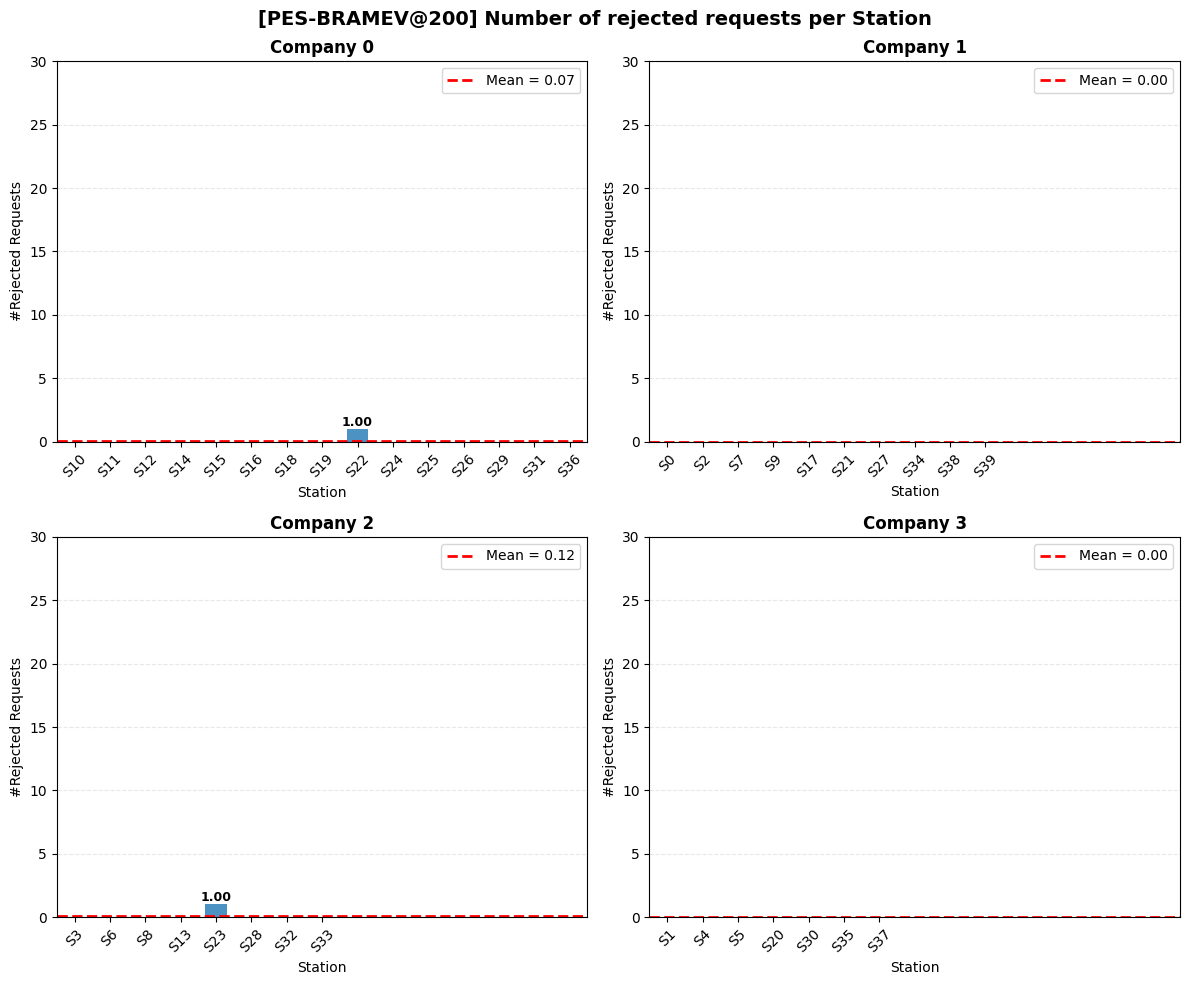

In [161]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [162]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

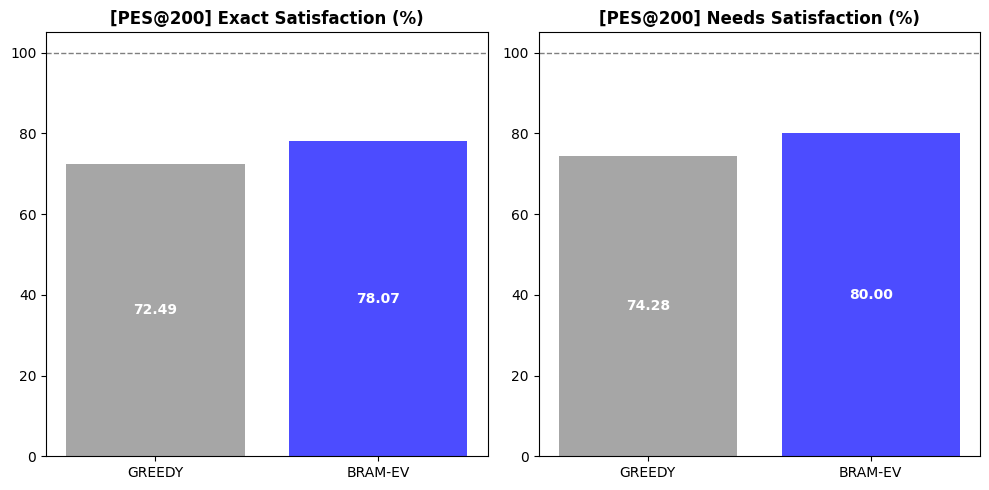

In [163]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

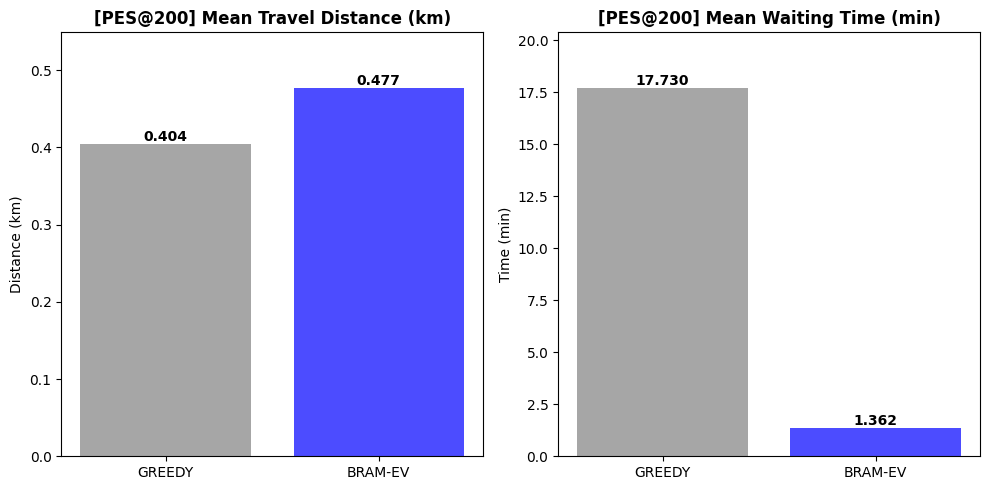

In [164]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

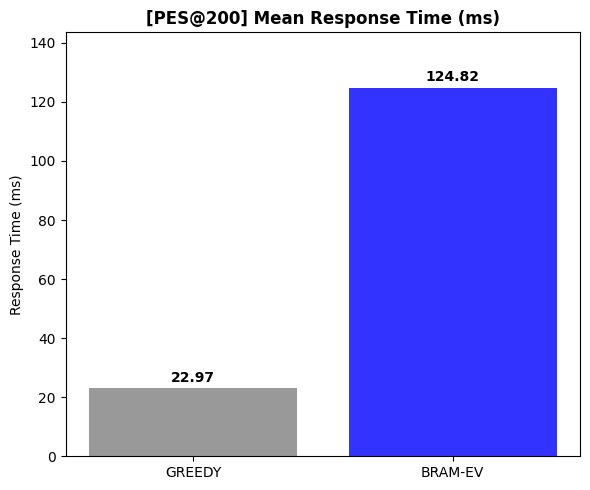

In [165]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@250cars**

#### **CONFIG**

In [166]:
nb_car = 250
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [167]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [168]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [169]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-17 21:21:48.744 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-06-17 21:21:49.036 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-06-17 21:21:49.414 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-06-17 21:21:49.947 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-06-17 21:21:50.348 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-06-17 21:21:50.858 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-06-17 21:21:51.111 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-06-17 21:21:51.610 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-06-17 21:21:52.259 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-06-17 21:21:52.752 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-06-17 21:21:53.263 | IN

##### *Metrics*

In [170]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 17.69 kWh
  Station 1: 50.66 kWh
  Station 2: 3.23 kWh
  Station 3: 59.93 kWh
  Station 4: 30.16 kWh
  Station 5: 13.47 kWh
  Station 6: 13.92 kWh
  Station 7: 14.90 kWh
  Station 8: 48.60 kWh
  Station 9: 107.50 kWh
  Station 10: 256.20 kWh
  Station 11: 1.65 kWh
  Station 12: 77.87 kWh
  Station 13: 237.56 kWh
  Station 14: 224.22 kWh
  Station 15: 1.08 kWh
  Station 16: 1.98 kWh
  Station 17: 29.85 kWh
  Station 18: 24.73 kWh
  Station 19: 93.00 kWh
  Station 20: 25.33 kWh
  Station 21: 3.17 kWh
  Station 22: 47.90 kWh
  Station 23: 7.44 kWh
  Station 24: 17.02 kWh
  Station 25: 77.35 kWh
  Station 26: 160.44 kWh
  Station 27: 91.78 kWh
  Station 28: 79.30 kWh
  Station 29: 19.24 kWh
  Station 30: 30.02 kWh
  Station 31: 79.58 kWh
  Station 32: 105.67 kWh
  Station 33: 214.60 kWh
  Station 34: 0.00 kWh
  Station 35: 22.33 kWh
  Station 36: 119.51 kWh
  Station 37: 63.68 kWh
  Station 38: 66.72 kWh
  Station 

In [171]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

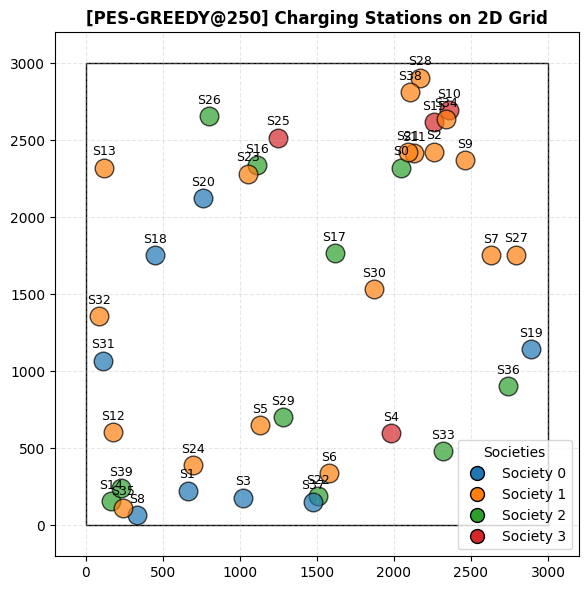

In [172]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

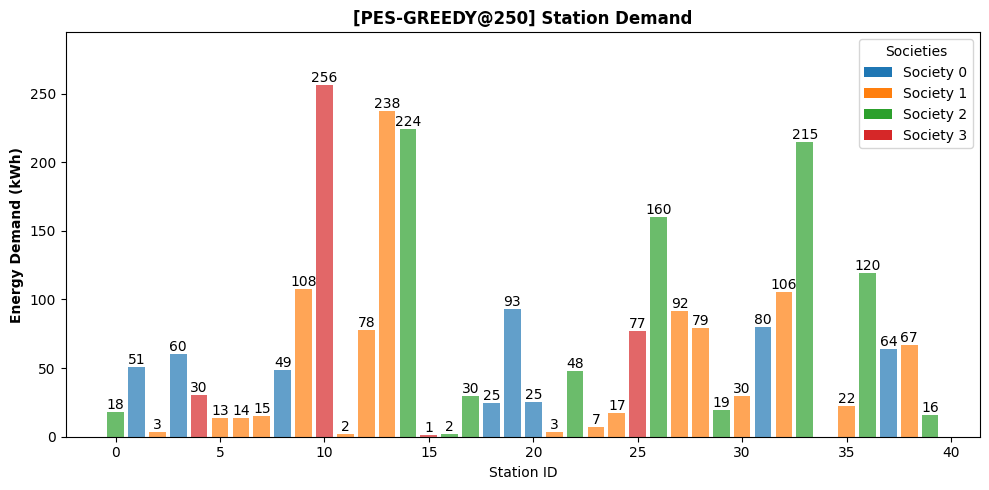

In [173]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

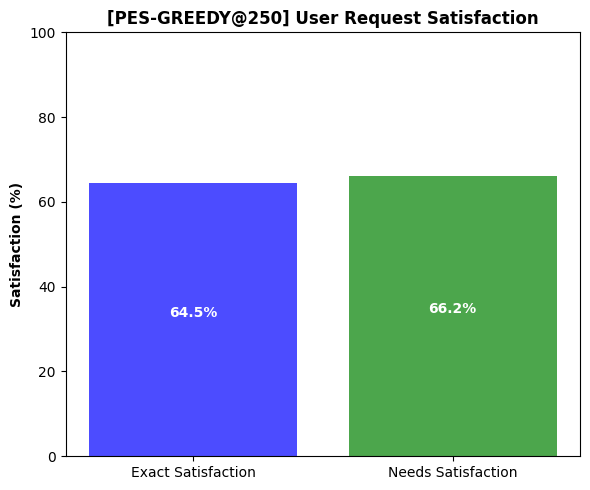

In [174]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

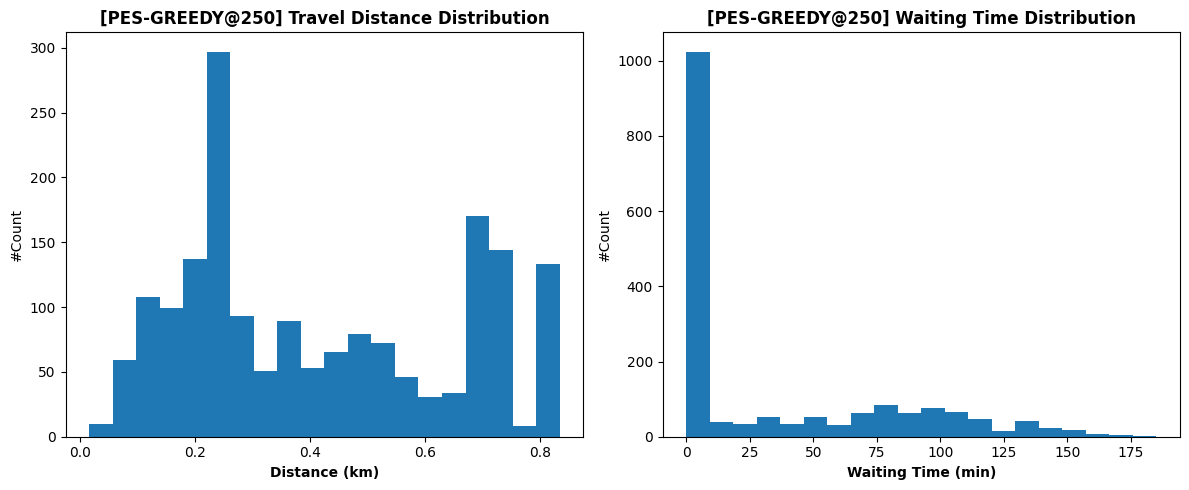

In [175]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

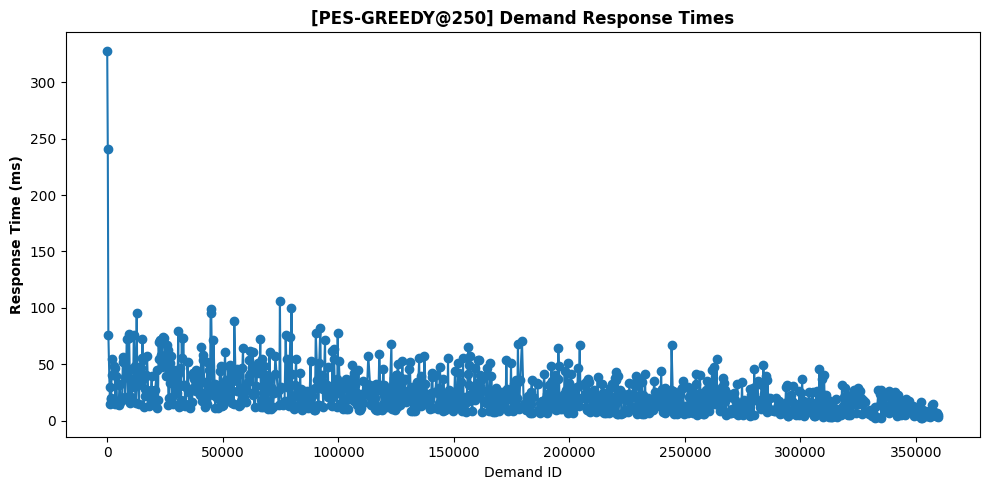

In [176]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

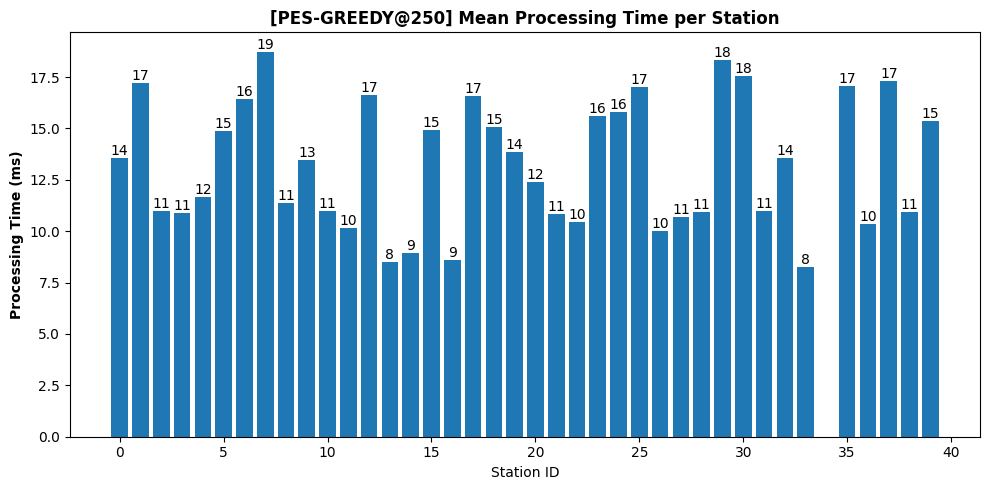

In [177]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [178]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           1  0.391667  0.193750  0.025000  0.000000  0.000000   
1            0           3  0.397917  0.259028  0.106944  0.134722       NaN   
2            0           8  0.444444  0.206944  0.038194  0.015972       NaN   
3            0          18  0.283333  0.013194  0.000000  0.000000  0.051389   
4            0          19  0.592361  0.498611  0.154861  0.000000  0.185417   
5            0          20  0.217361  0.101389  0.022222  0.000000       NaN   
6            0          31  0.375000  0.415278  0.113889  0.230556       NaN   
7            0          37  0.372222  0.347222  0.118056  0.000000  0.000000   
8            1           2  0.047222  0.000000  0.000000  0.000000       NaN   
9            1           5  0.161111  0.060417  0.000000  0.000000  0.000000   
10           1           6  0.126389  0.075000  0.000000  0.000000  0.000000   
11           1           7  0.202083  0.

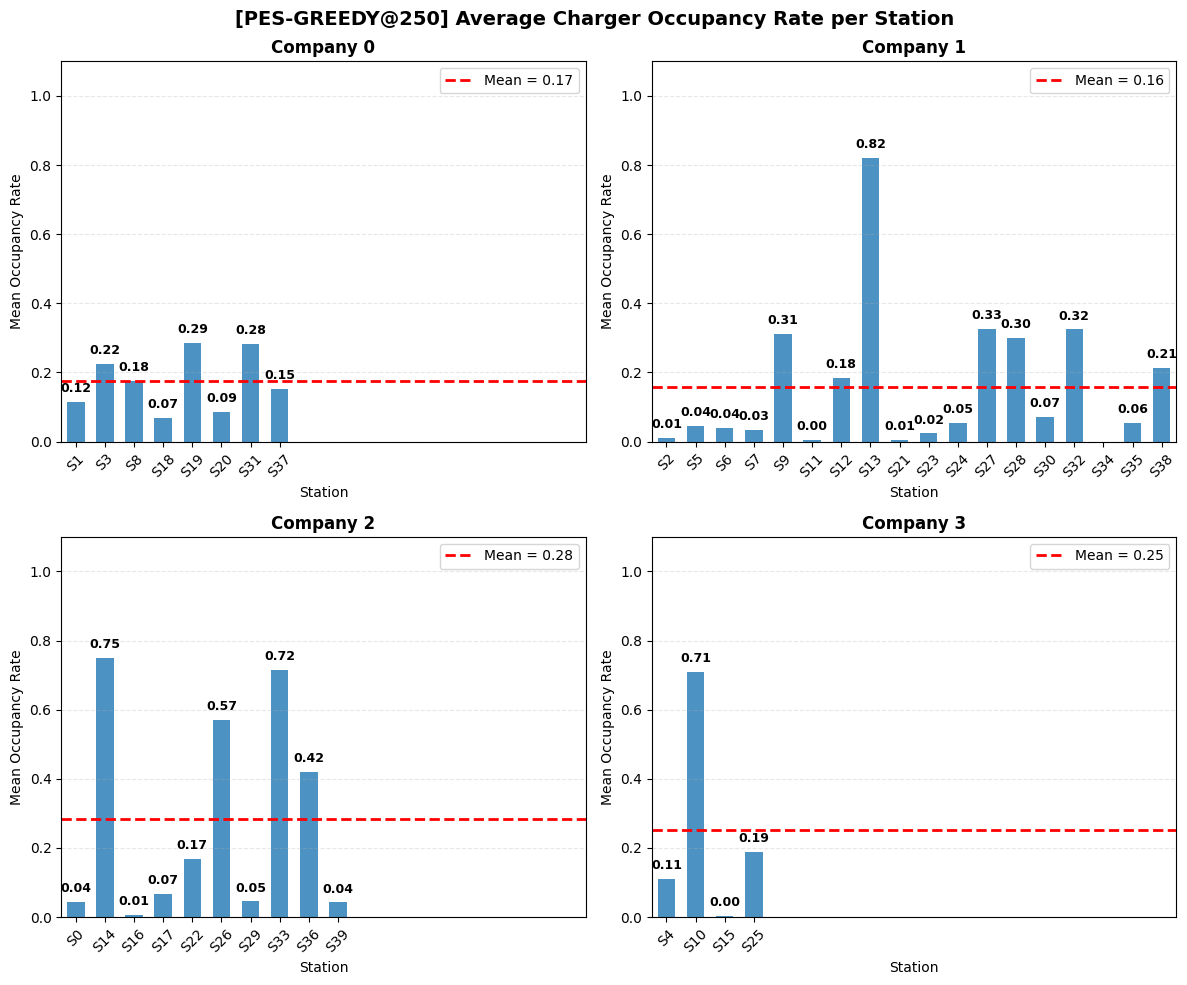

In [179]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

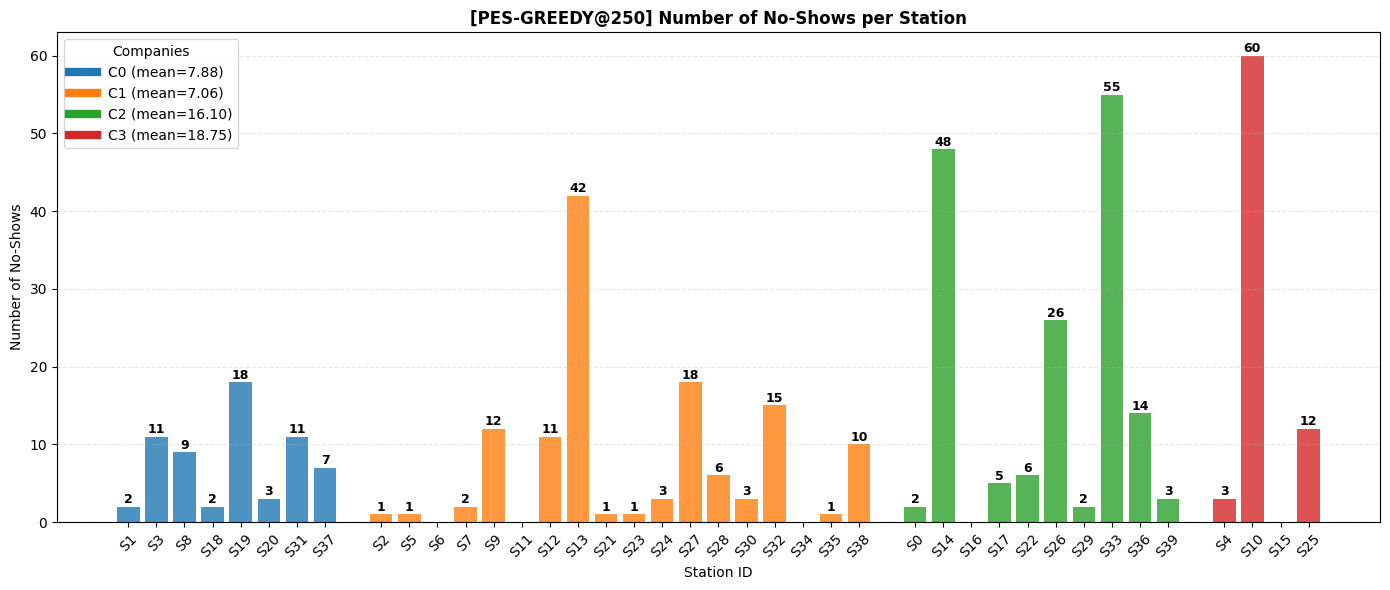

In [180]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [181]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,1,30,27,2,0,0,0.900000,0.066667,0.000000,0.000000
1,0,3,47,36,11,0,0,0.765957,0.234043,0.000000,0.000000
2,0,8,40,29,9,0,0,0.725000,0.225000,0.000000,0.000000
3,0,18,16,14,2,0,0,0.875000,0.125000,0.000000,0.000000
4,0,19,71,52,18,0,0,0.732394,0.253521,0.000000,0.000000
5,0,20,16,13,3,0,0,0.812500,0.187500,0.000000,0.000000
6,0,31,59,48,11,0,0,0.813559,0.186441,0.000000,0.000000
7,0,37,45,38,7,0,0,0.844444,0.155556,0.000000,0.000000
8,1,2,3,2,1,0,0,0.666667,0.333333,0.000000,0.000000
9,1,5,11,9,1,0,0,0.818182,0.090909,0.000000,0.000000


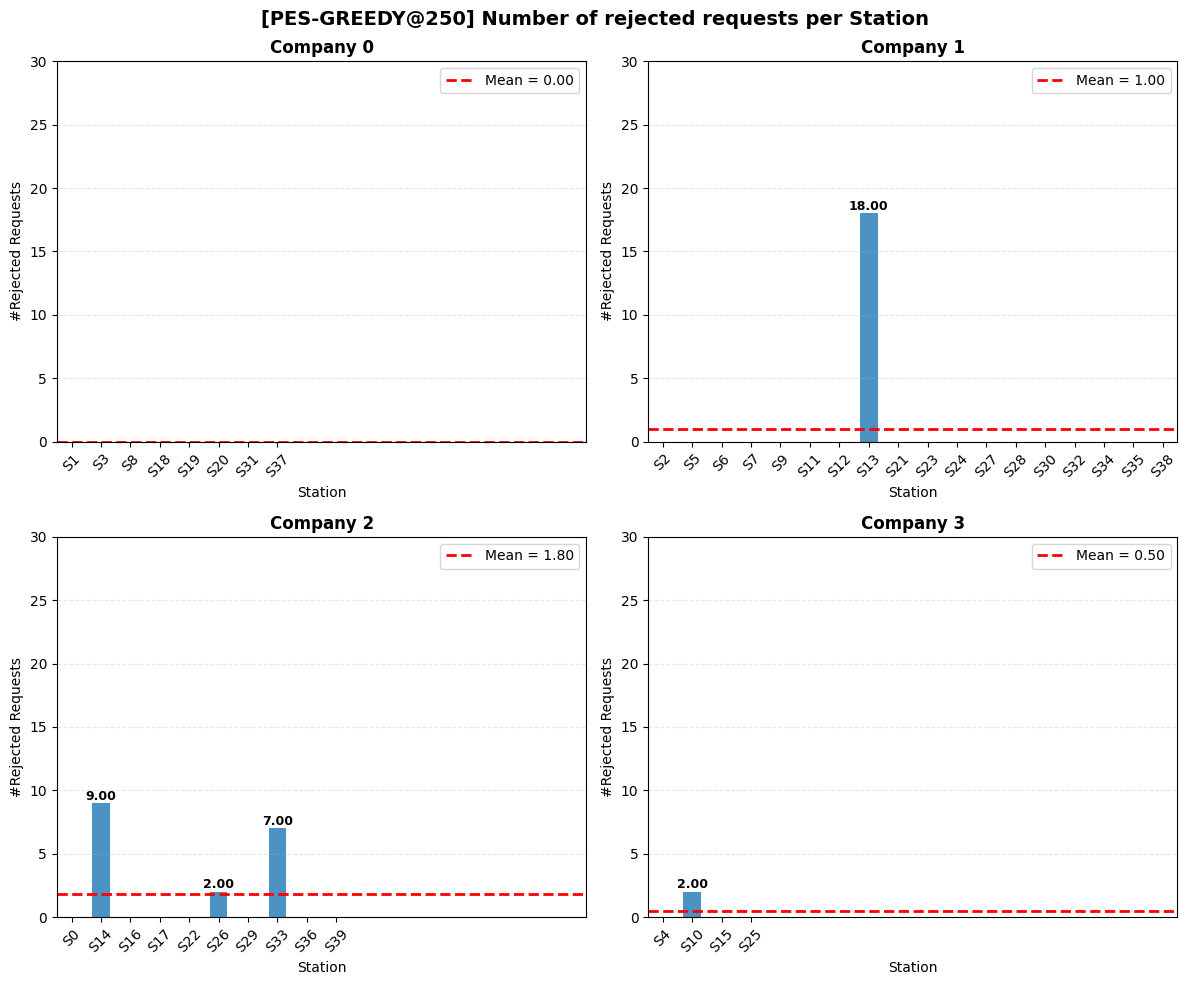

In [182]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [183]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [184]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [185]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-17 21:22:26.434 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-17 21:22:29.129 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-17 21:22:30.985 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-17 21:22:34.575 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-17 21:22:36.589 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-17 21:22:38.992 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-17 21:22:41.751 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-17 21:22:44.092 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-17 21:22:45.604 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-17 21:22:48.131 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-17 21:22:50.907 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [186]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 18.25 kWh
  Station 1: 27.07 kWh
  Station 2: 60.90 kWh
  Station 3: 100.37 kWh
  Station 4: 26.27 kWh
  Station 5: 79.25 kWh
  Station 6: 206.76 kWh
  Station 7: 24.78 kWh
  Station 8: 78.74 kWh
  Station 9: 2.65 kWh
  Station 10: 22.72 kWh
  Station 11: 52.20 kWh
  Station 12: 71.90 kWh
  Station 13: 12.97 kWh
  Station 14: 19.45 kWh
  Station 15: 174.28 kWh
  Station 16: 101.23 kWh
  Station 17: 28.29 kWh
  Station 18: 18.65 kWh
  Station 19: 15.88 kWh
  Station 20: 8.25 kWh
  Station 21: 9.33 kWh
  Station 22: 93.08 kWh
  Station 23: 194.47 kWh
  Station 24: 12.93 kWh
  Station 25: 30.29 kWh
  Station 26: 106.68 kWh
  Station 27: 43.96 kWh
  Station 28: 237.21 kWh
  Station 29: 41.79 kWh
  Station 30: 27.44 kWh
  Station 31: 87.05 kWh
  Station 32: 137.09 kWh
  Station 33: 35.22 kWh
  Station 34: 92.17 kWh
  Station 35: 98.61 kWh
  Station 36: 13.12 kWh
  Station 37: 71.10 kWh
  Station 38: 178.82 kWh
  Sta

In [187]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

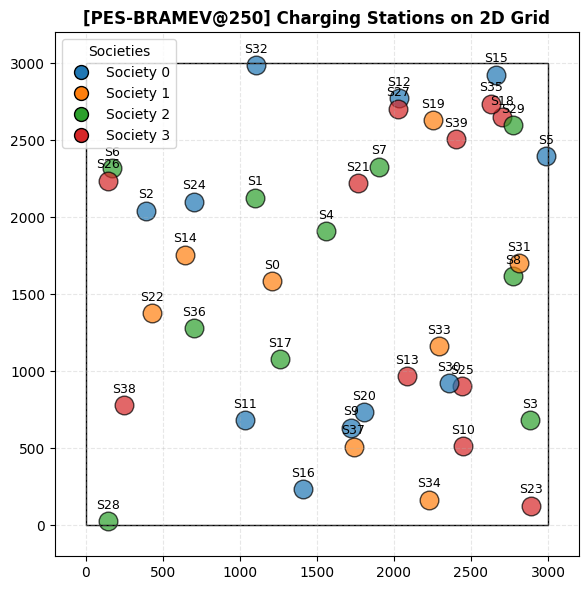

In [188]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

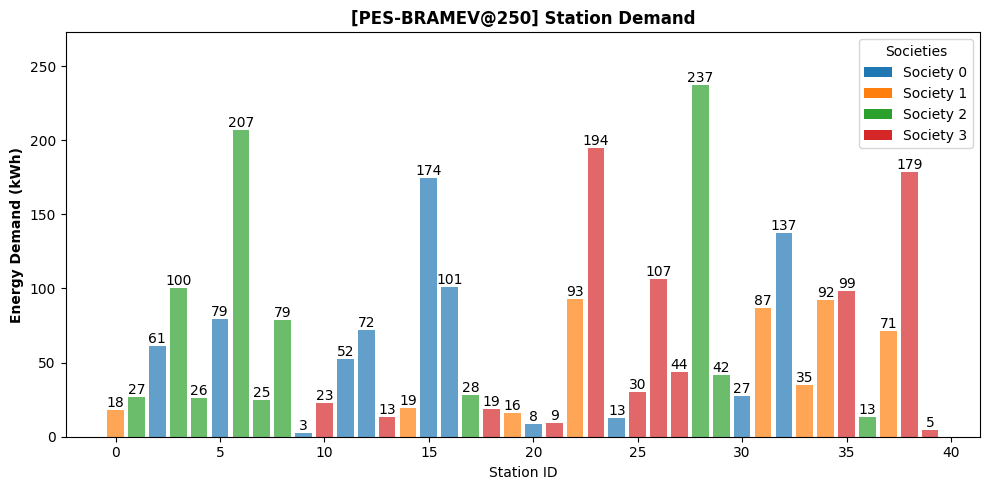

In [189]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

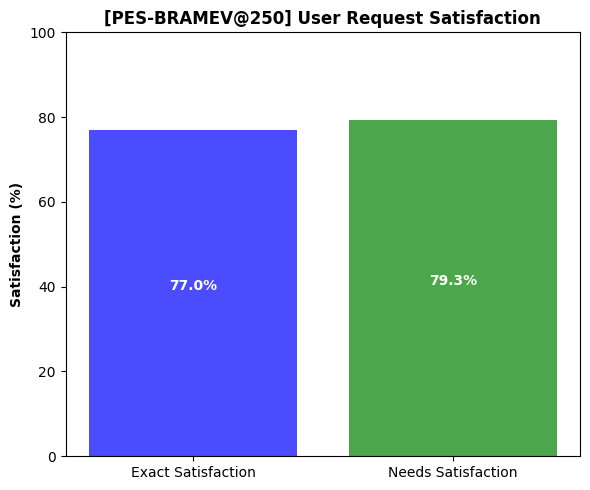

In [190]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

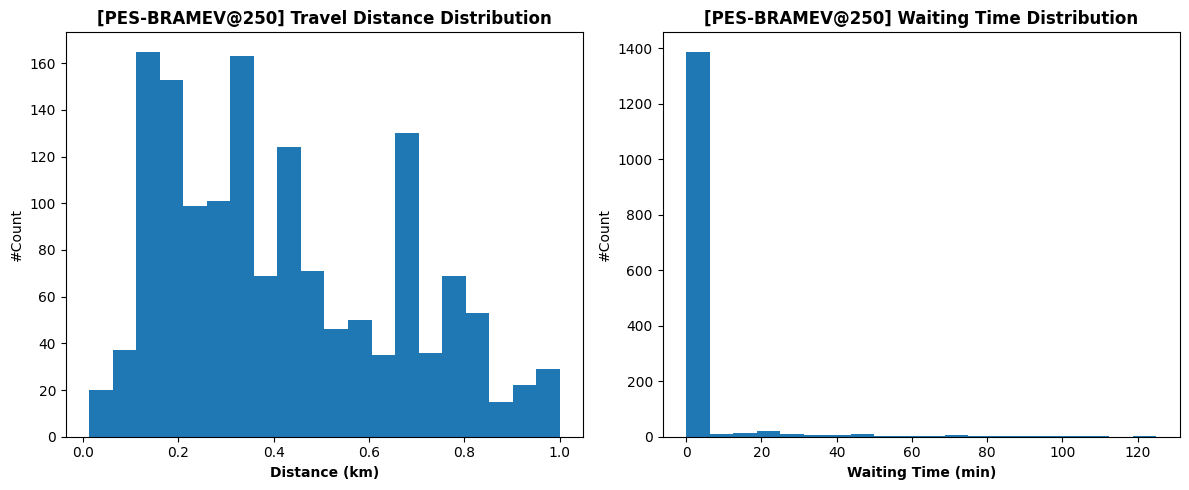

In [191]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

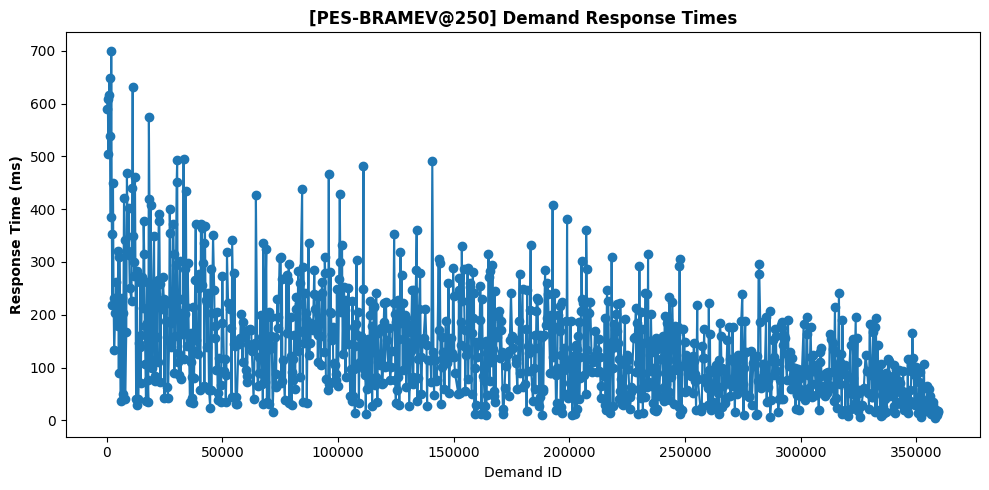

In [192]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

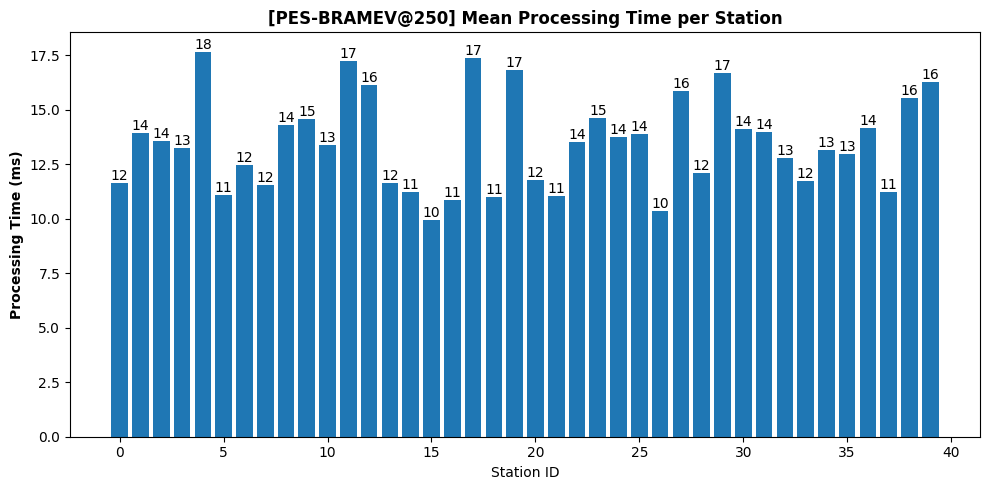

In [193]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

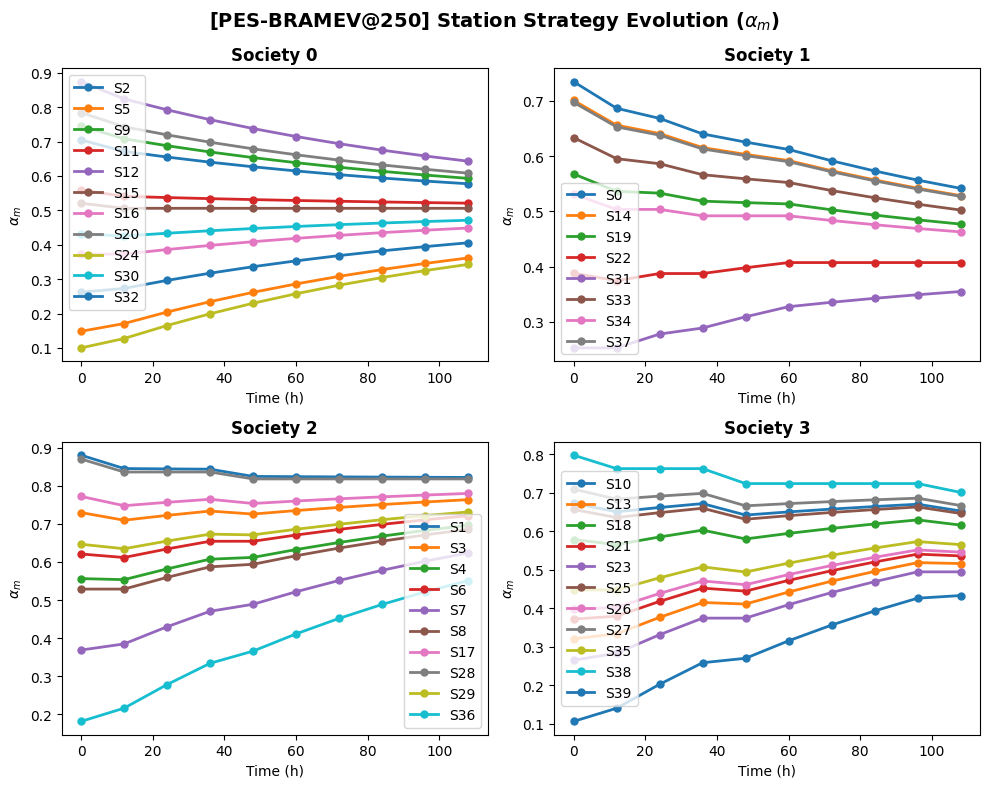

In [194]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [195]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           2  0.414583  0.316667  0.079861  0.042361  0.065278   
1            0           5  0.574306  0.271528  0.173611  0.105556       NaN   
2            0           9  0.039583  0.000000  0.000000  0.000000  0.000000   
3            0          11  0.381944  0.258333  0.078472  0.002778  0.000000   
4            0          12  0.485417  0.286111  0.081250  0.027778  0.000000   
5            0          15  0.672222  0.675000  0.620833  0.642361       NaN   
6            0          16  0.584722  0.421528  0.178472  0.245139       NaN   
7            0          20  0.107639  0.000000  0.000000  0.000000       NaN   
8            0          24  0.100000  0.016667  0.000000  0.021528  0.019444   
9            0          30  0.244444  0.131250  0.027778  0.000000  0.000000   
10           0          32  0.550000  0.418056  0.290972  0.316667  0.381944   
11           1           0  0.118750  0.

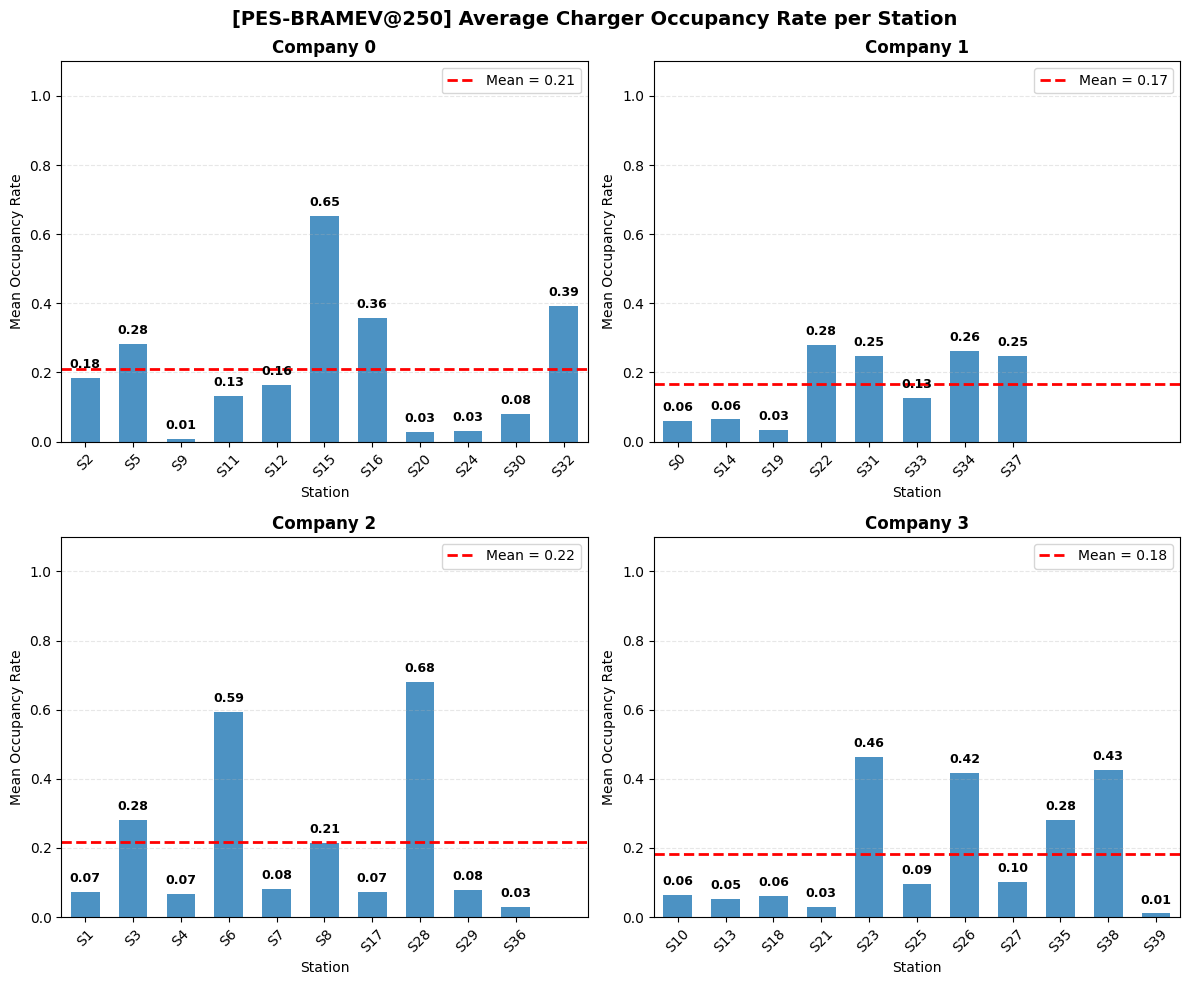

In [196]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

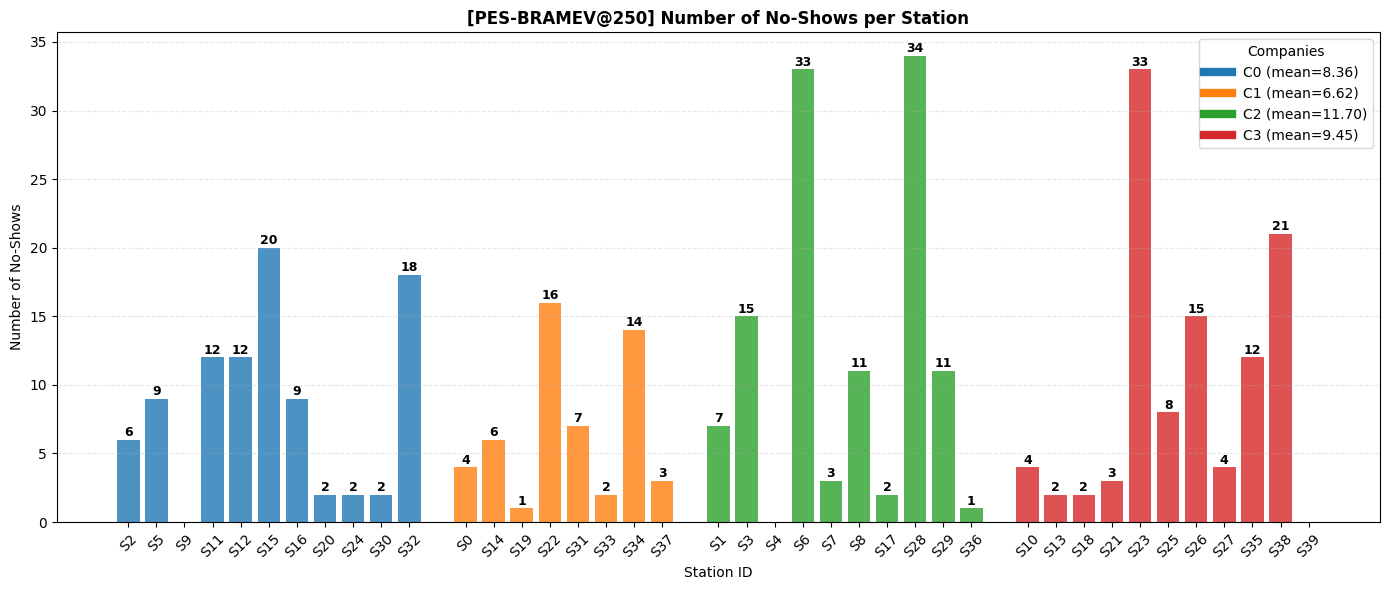

In [197]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [198]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,2,38,32,6,0,0,0.842105,0.157895,0.000000,0.0
1,0,5,53,44,9,0,0,0.830189,0.169811,0.000000,0.0
2,0,9,2,2,0,0,0,1.000000,0.000000,0.000000,0.0
3,0,11,44,31,12,0,0,0.704545,0.272727,0.000000,0.0
4,0,12,52,39,12,0,0,0.750000,0.230769,0.000000,0.0
5,0,15,119,96,20,0,0,0.806723,0.168067,0.000000,0.0
6,0,16,67,57,9,0,0,0.850746,0.134328,0.000000,0.0
7,0,20,7,5,2,0,0,0.714286,0.285714,0.000000,0.0
8,0,24,9,7,2,0,0,0.777778,0.222222,0.000000,0.0
9,0,30,18,16,2,0,0,0.888889,0.111111,0.000000,0.0


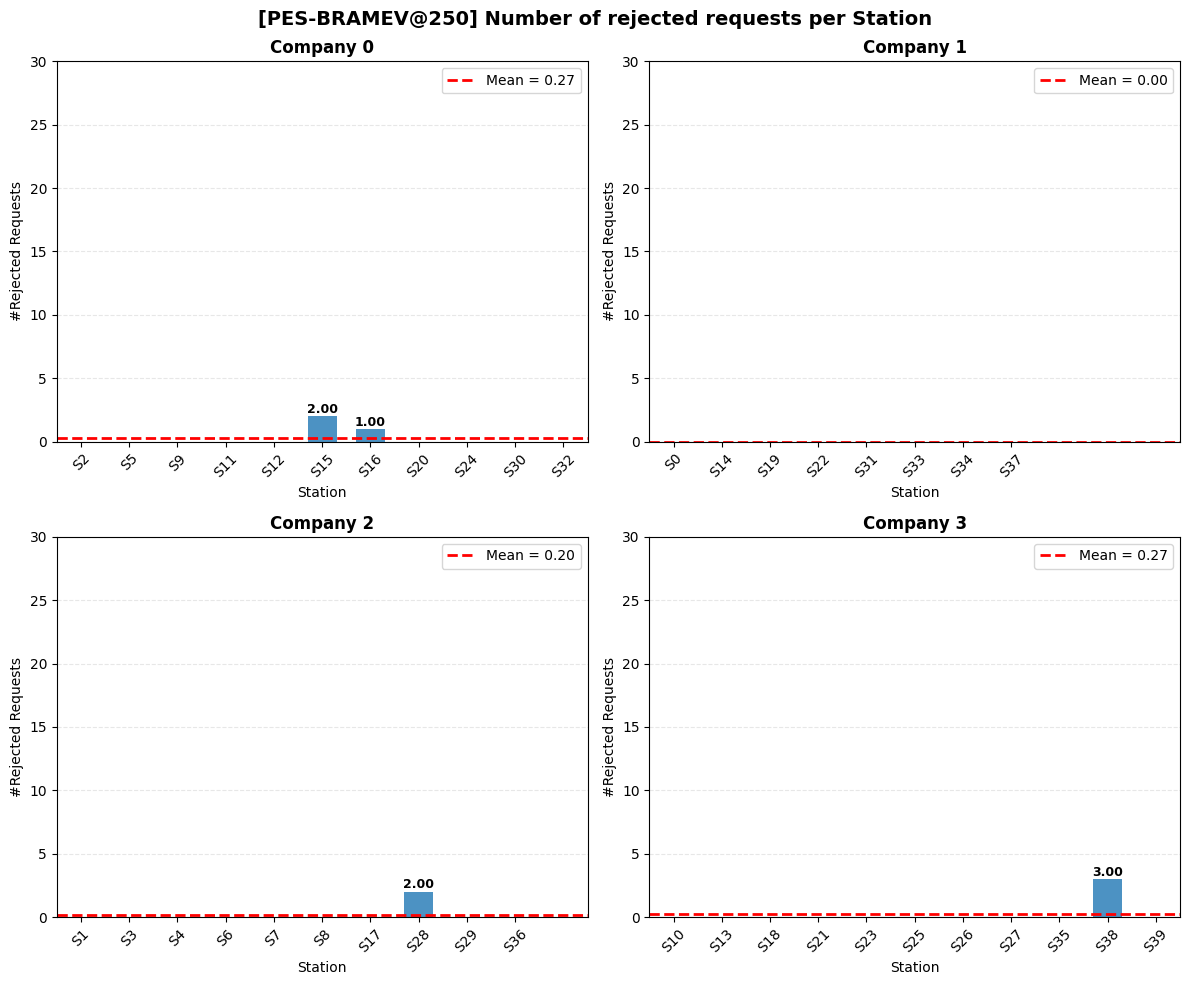

In [199]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [200]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

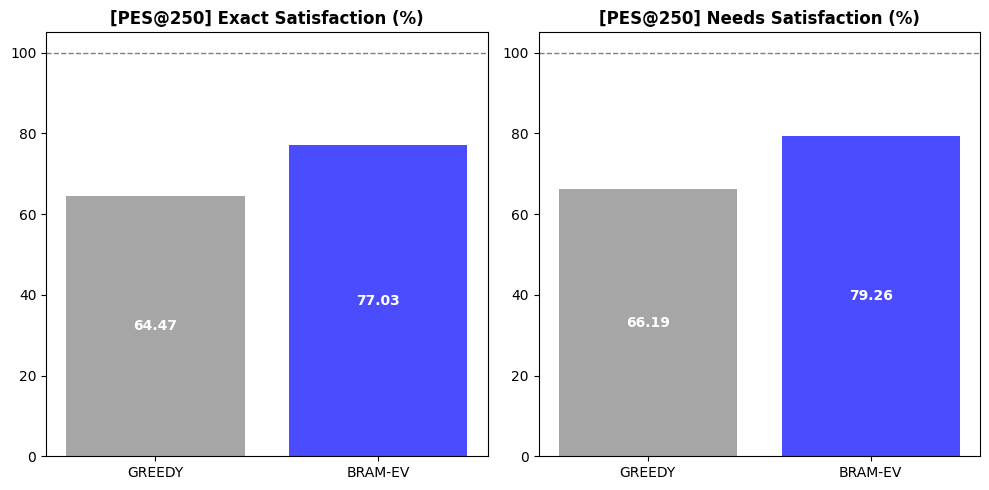

In [201]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

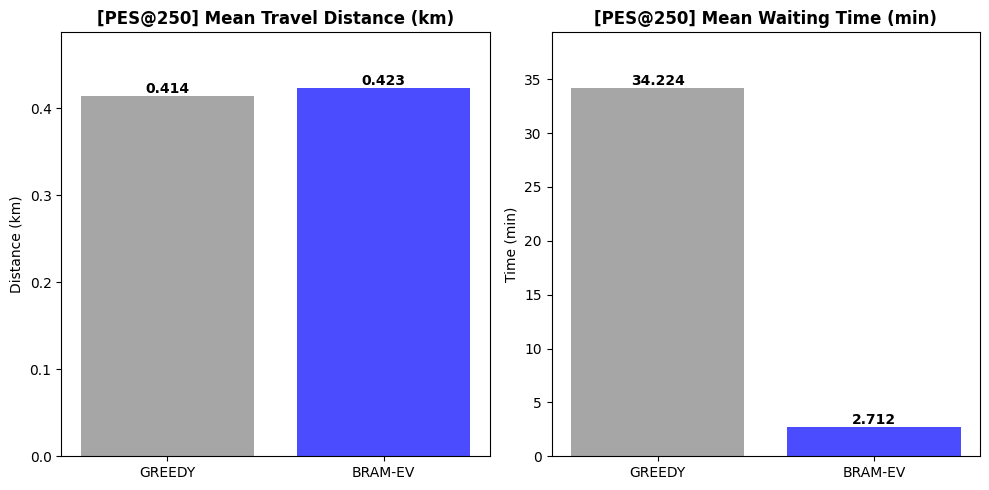

In [202]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

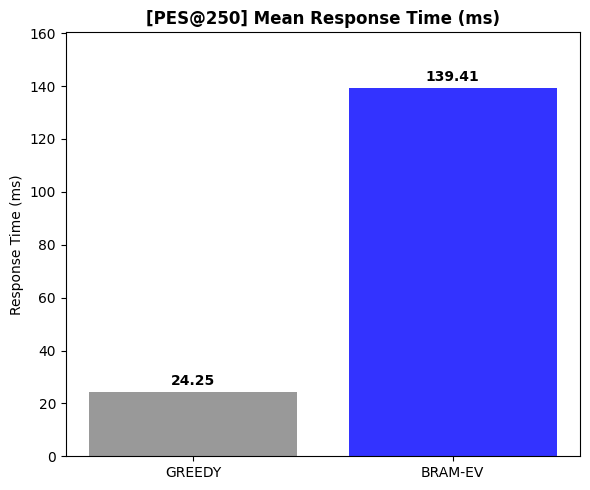

In [203]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

## **COMPARISON**

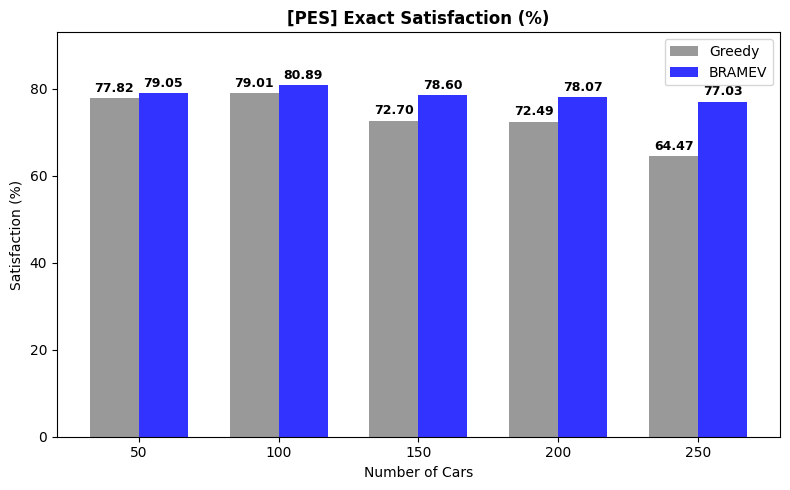

In [204]:
plot_exact_satisfaction(
    exact_satif_greedy_list,
    exact_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

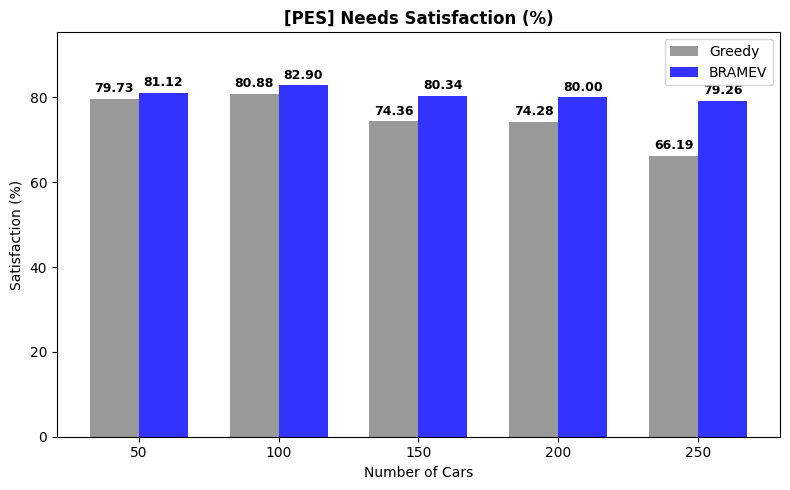

In [205]:
plot_needs_satisfaction(
    needs_satif_greedy_list,
    needs_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

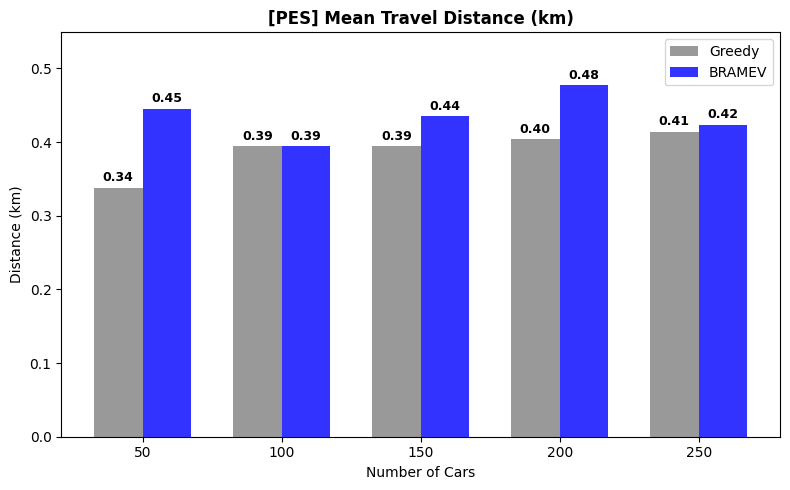

In [206]:
plot_mean_travel_distance(
    mean_travel_greedy_list,
    mean_travel_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


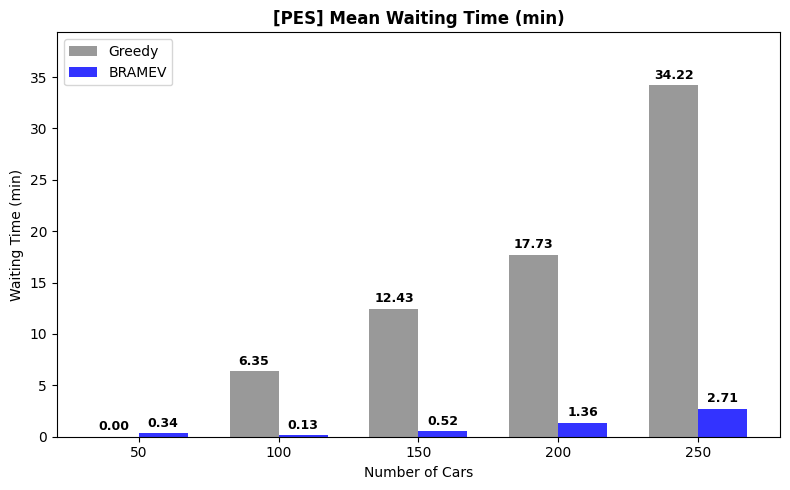

In [207]:
plot_mean_waiting_time(
    mean_waiting_greedy_list,
    mean_waiting_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


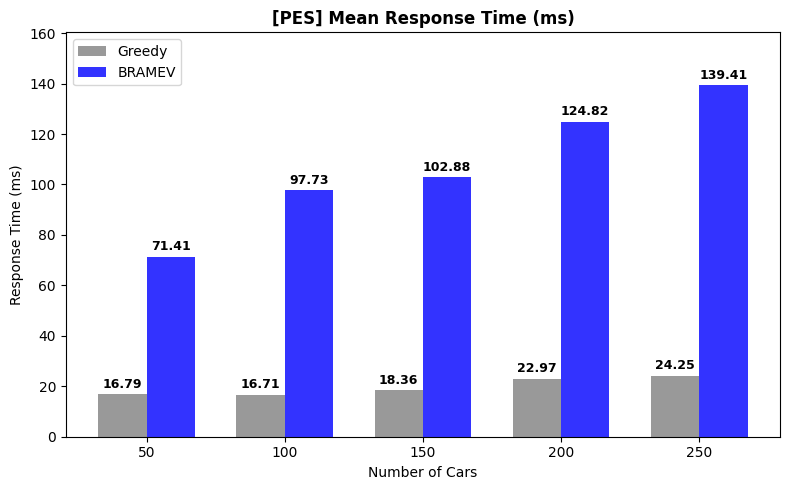

In [208]:
plot_mean_response_time(
    mean_response_greedy_list,
    mean_response_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)
